In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle
import glob

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num = 21 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c21_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c21_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

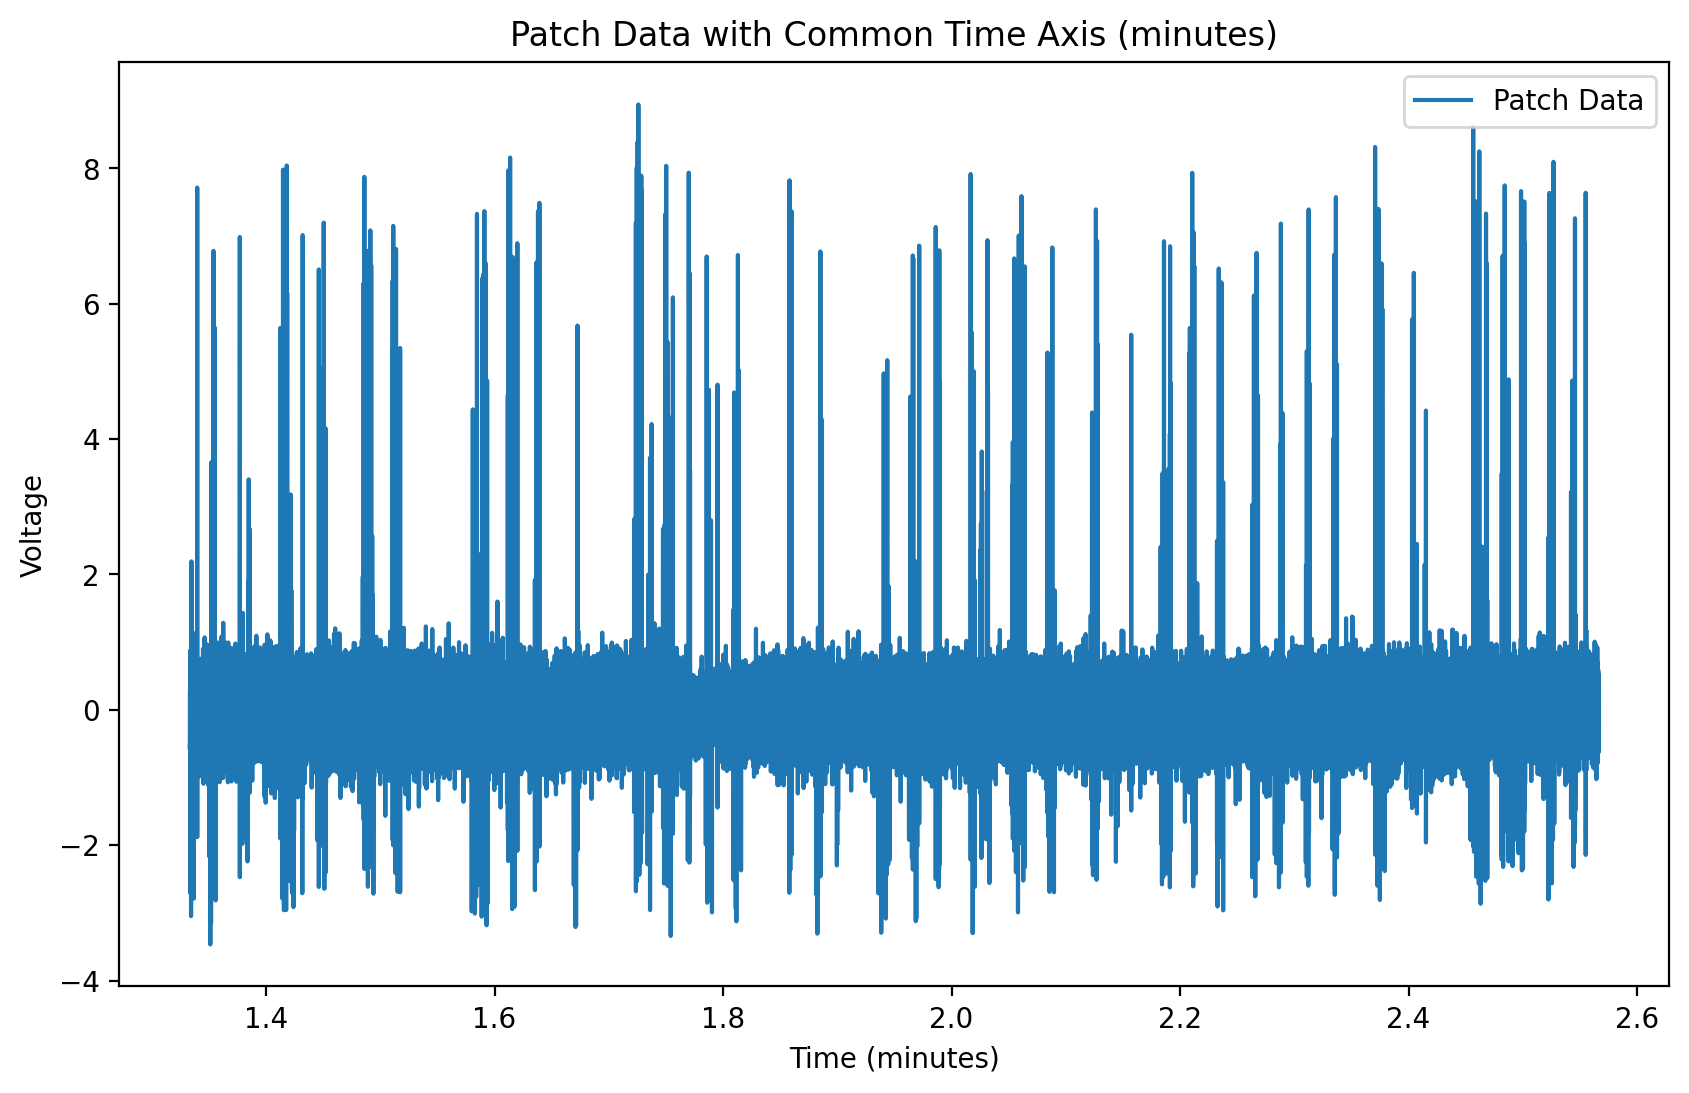

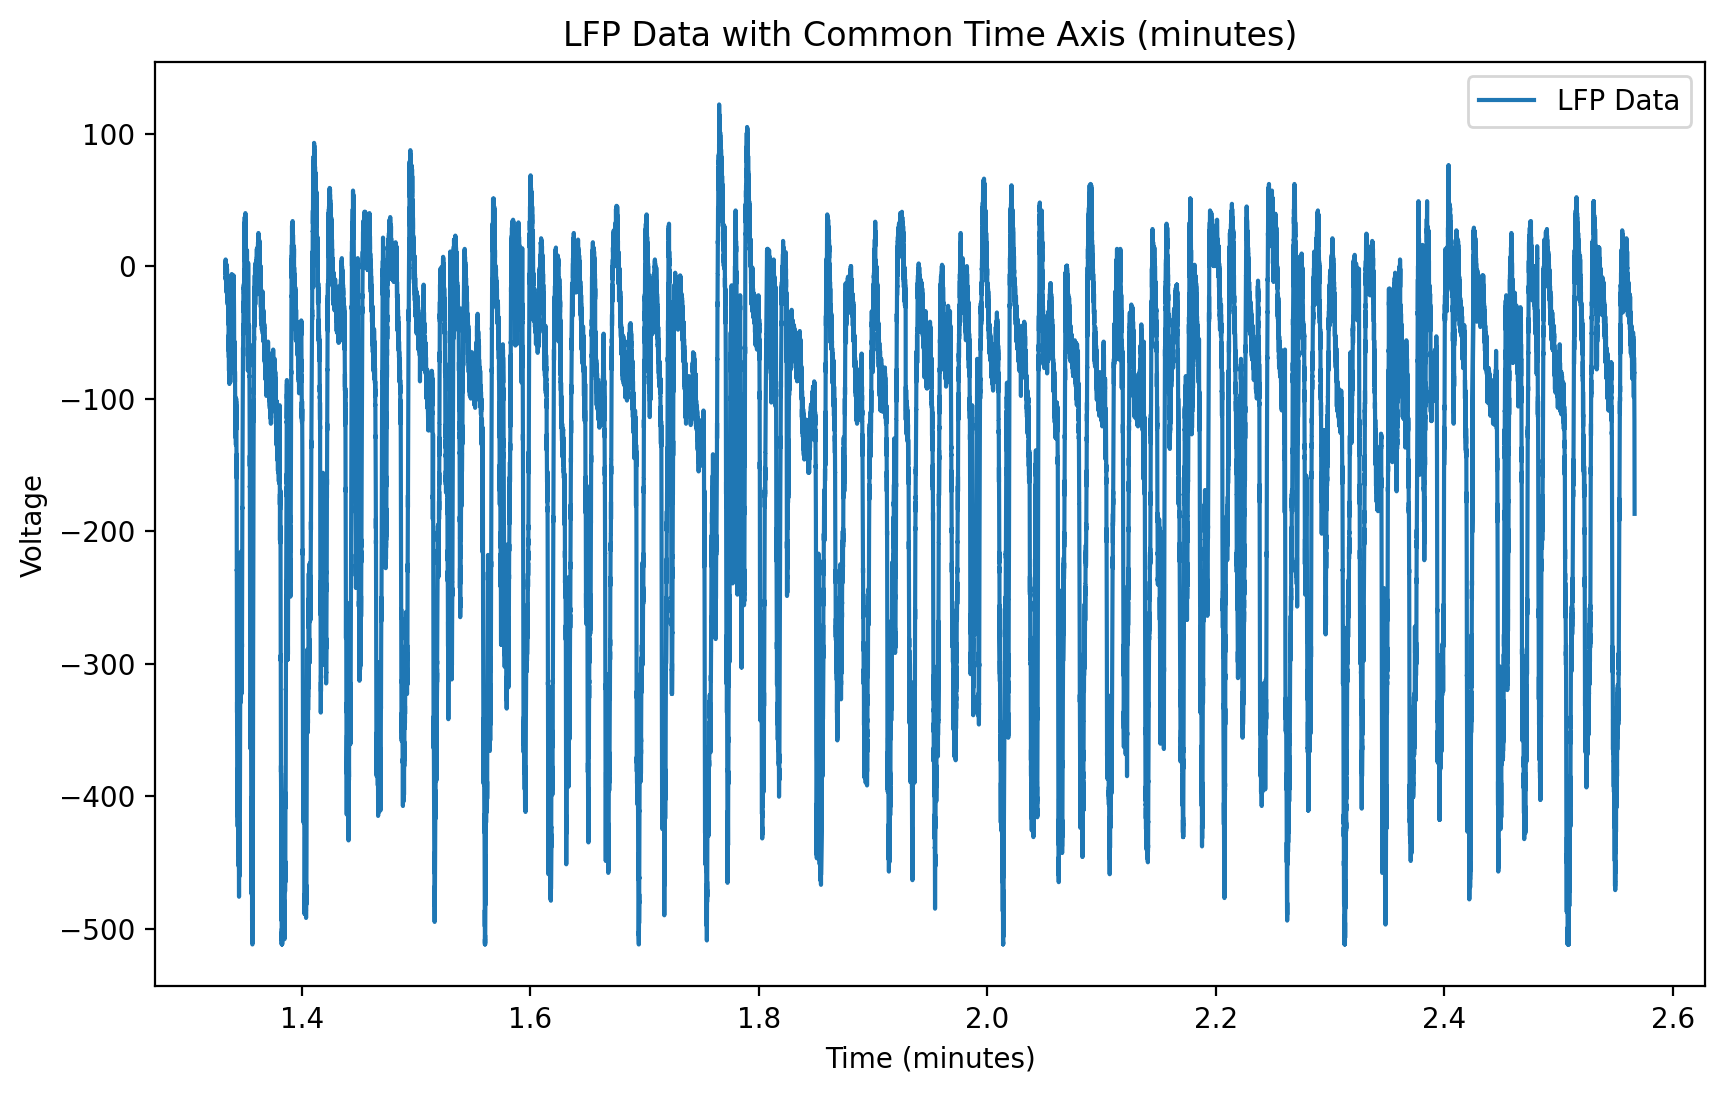

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

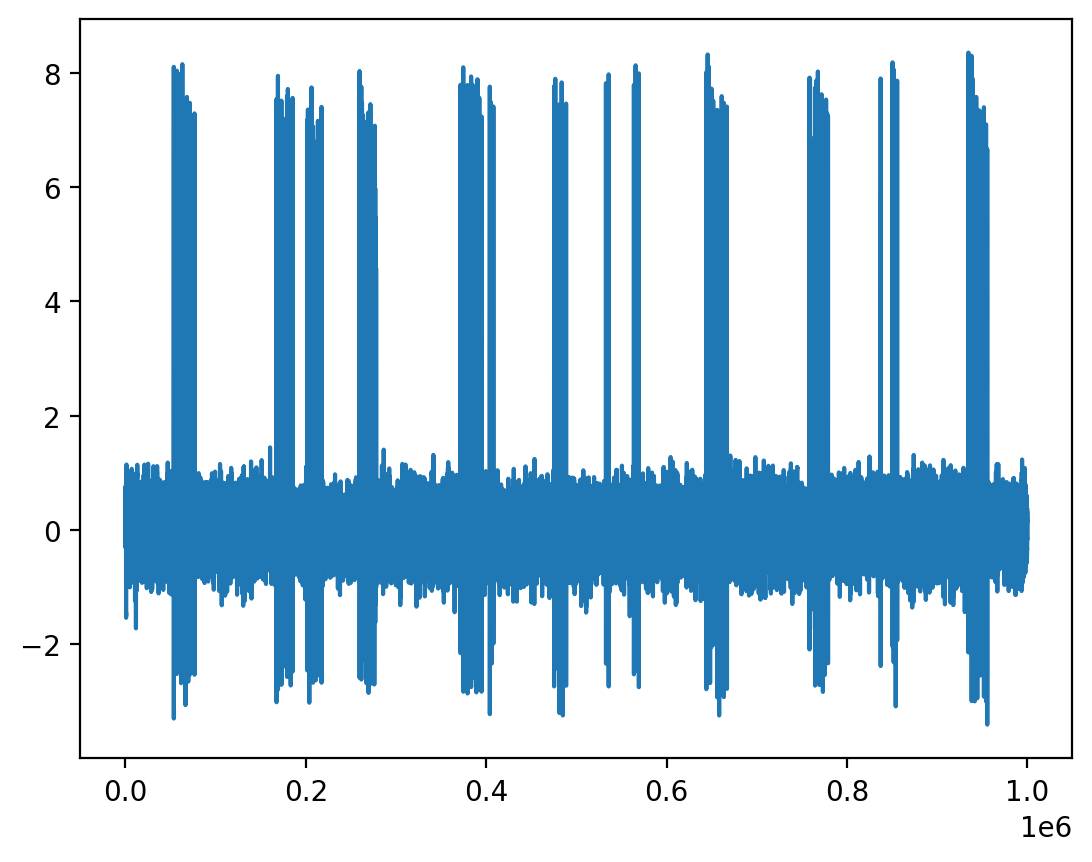

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [9]:
#CHANGE FOR EACH CELL
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/9773 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


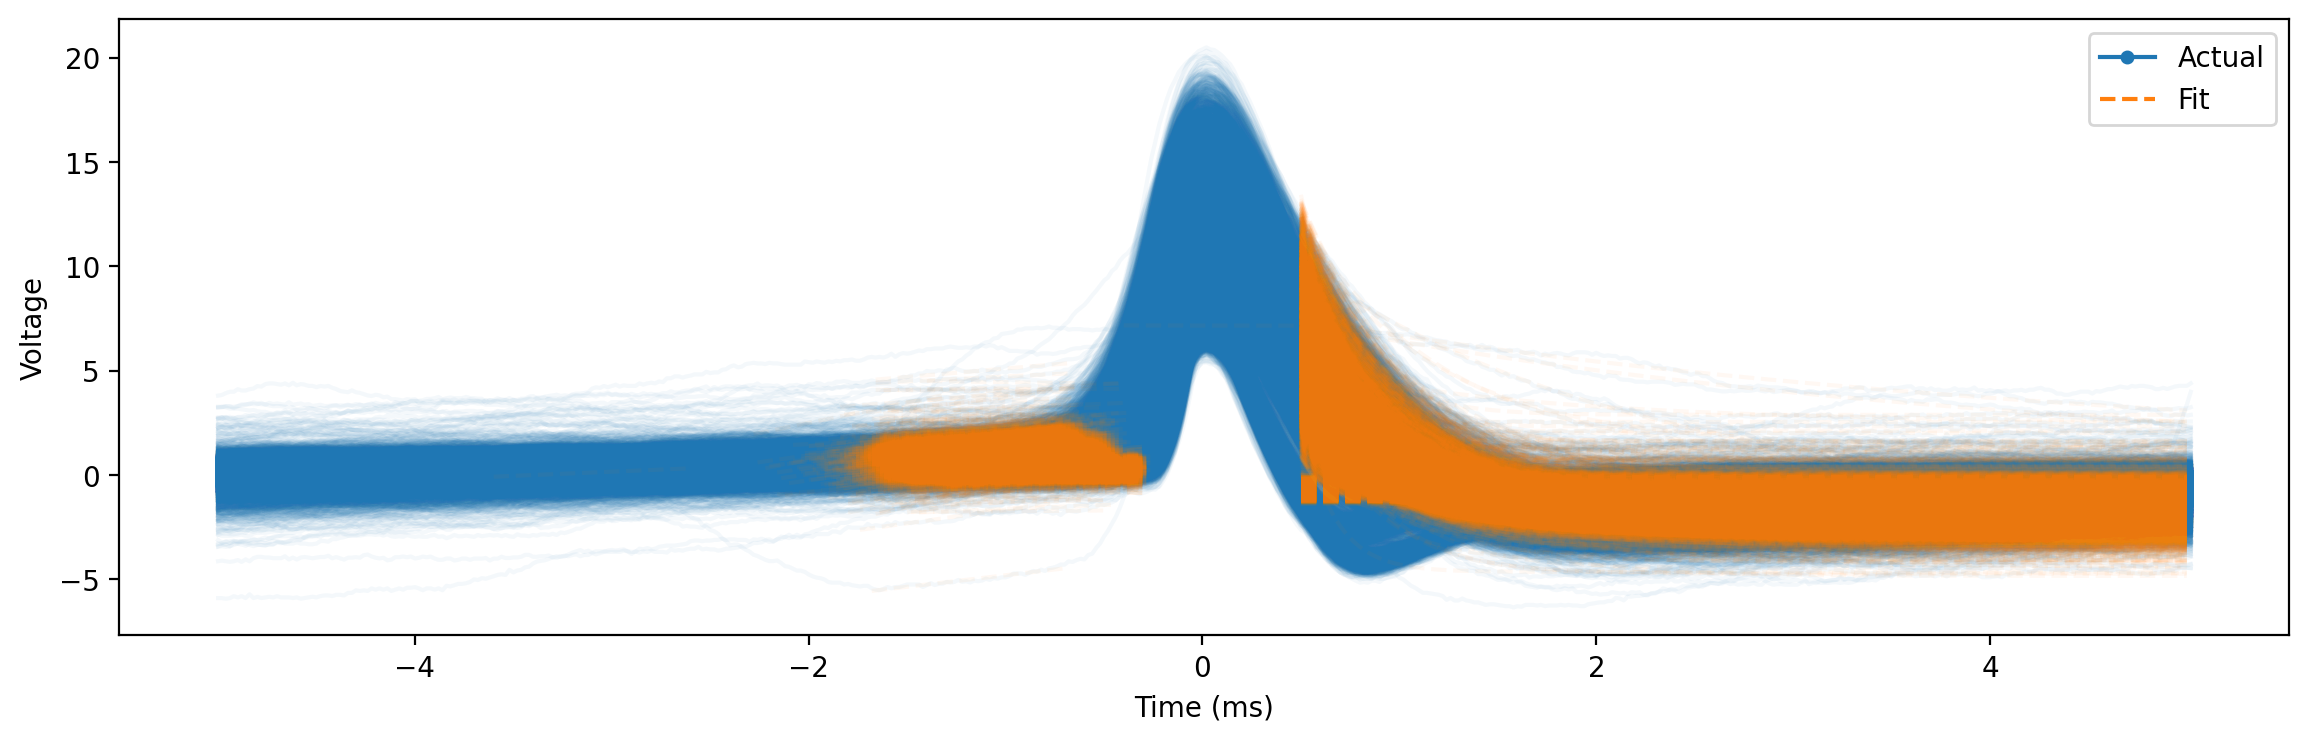

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
1,0.185567,0.26,0.442928,7.949770,0.30,2.641294,0.000002,-0.294561,1.631439,56987,1.139196e+03,0
5,-0.076079,0.30,0.203484,7.313011,0.30,2.073876,0.000028,-0.932597,1.501126,66587,1.331104e+03,1
6,-0.272411,0.28,0.286409,7.457714,0.32,2.334554,0.000016,-0.393766,1.473717,68173,1.362809e+03,2
7,0.698416,0.30,0.492143,7.205282,0.32,2.074960,0.000016,-0.899556,1.530248,69662,1.392574e+03,3
10,-0.295337,0.28,0.188678,7.513341,0.28,2.471867,0.000006,-0.793677,1.498379,167561,3.349619e+03,4
...,...,...,...,...,...,...,...,...,...,...,...,...
9766,0.192055,0.36,0.050344,6.366077,0.42,0.959600,0.000014,-1.133960,1.671890,53930015,1.078085e+06,7910
9768,0.075823,0.38,0.147030,6.220482,0.40,1.113120,0.000015,-1.071736,1.615953,53934028,1.078165e+06,7911
9769,-0.070153,0.36,0.126203,6.108001,0.42,0.976829,0.000012,-0.968436,1.674837,53936094,1.078207e+06,7912
9770,0.116481,0.36,0.503001,6.513055,0.40,0.944731,0.000010,-0.534537,1.667992,53938460,1.078254e+06,7913


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [15]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi',
       'spk_times_idx', 'spk_times_ms', 'spk_id'],
      dtype='object')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


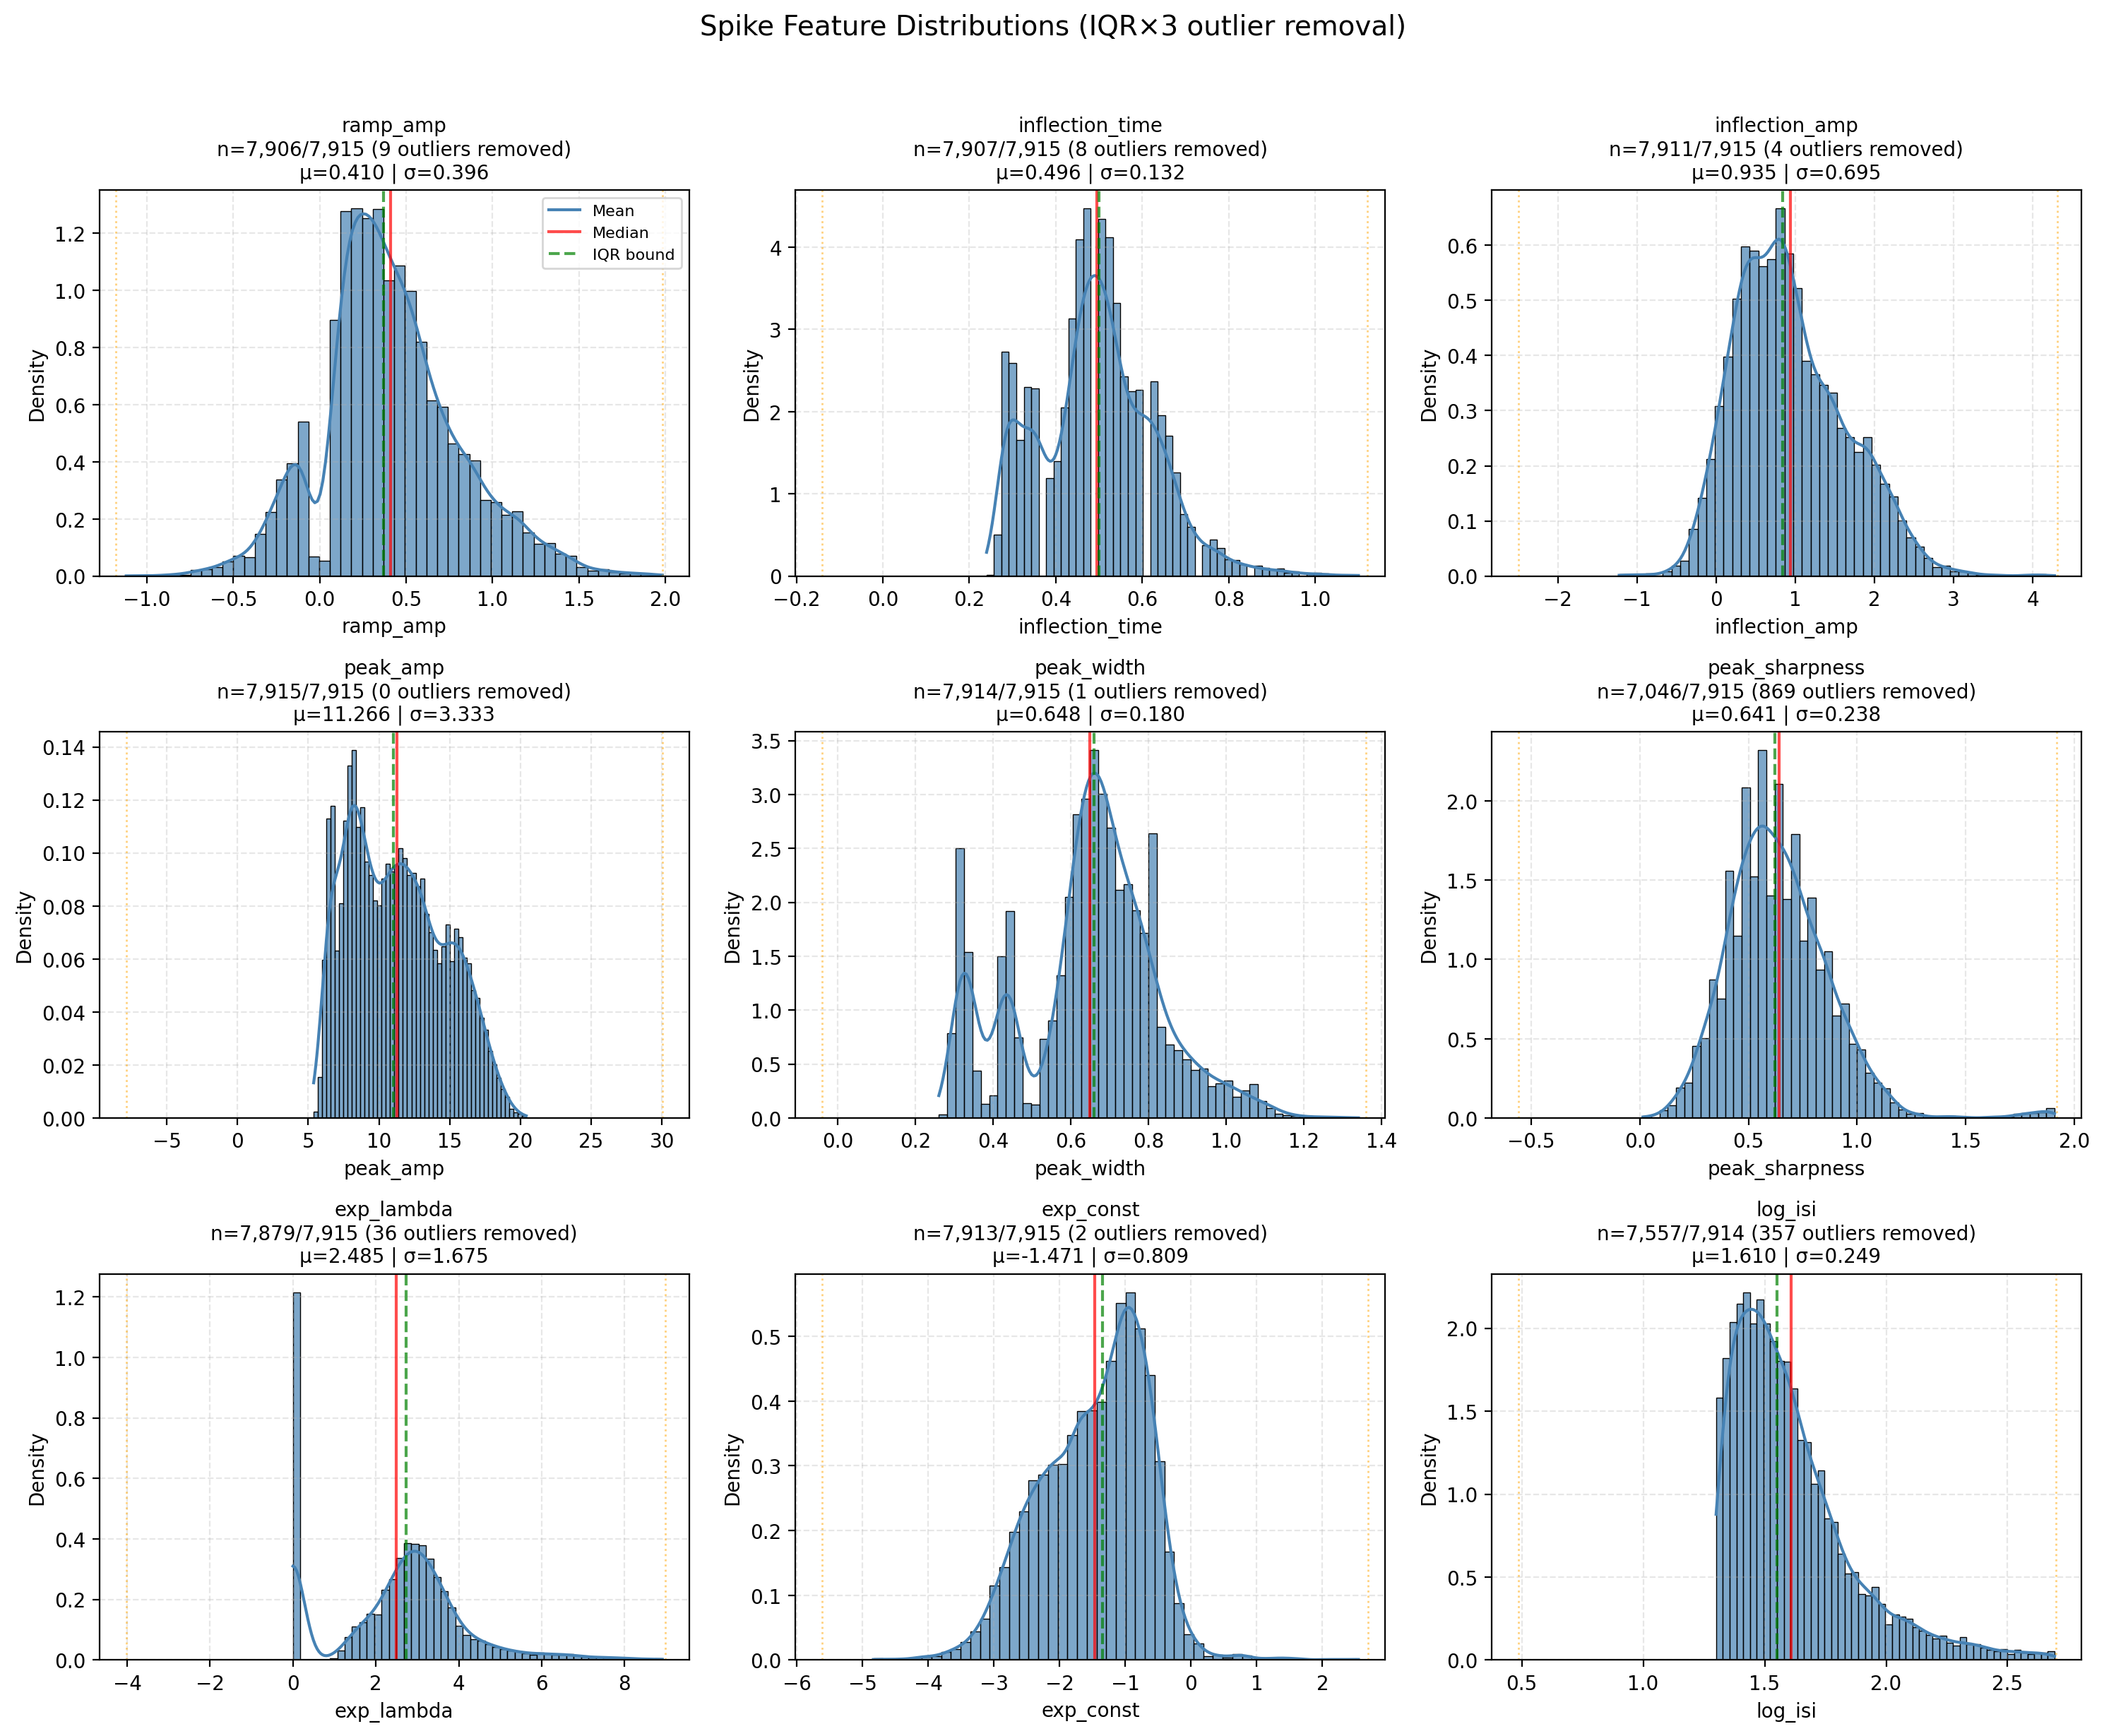


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             7915       7906       9          0.1        0.410      0.396     
inflection_time      7915       7907       8          0.1        0.496      0.132     
inflection_amp       7915       7911       4          0.1        0.935      0.695     
peak_amp             7915       7915       0          0.0        11.266     3.333     
peak_width           7915       7914       1          0.0        0.648      0.180     
peak_sharpness       7915       7046       869        11.0       0.641      0.238     
exp_lambda           7915       7879       36         0.5        2.485      1.675     
exp_const            7915       7913       2          0.0        -1.471     0.809     
log_isi              7914       7557       357        4.5        1.610      0.249     


In [16]:
plot_spike_feature_distributions(df_features)

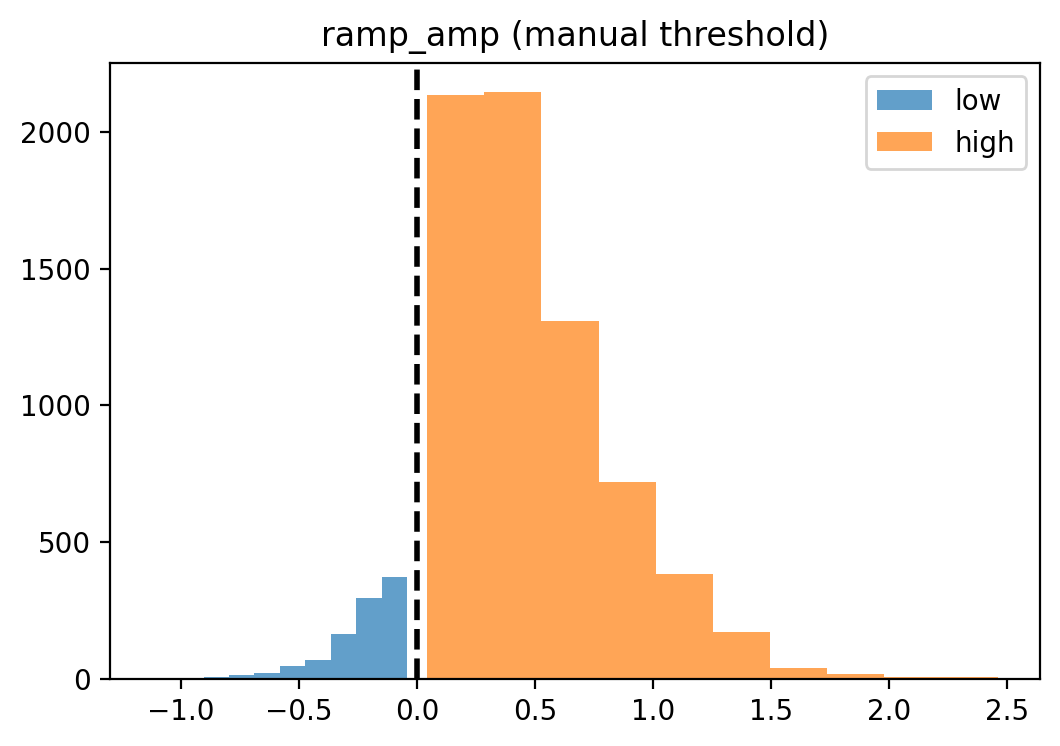

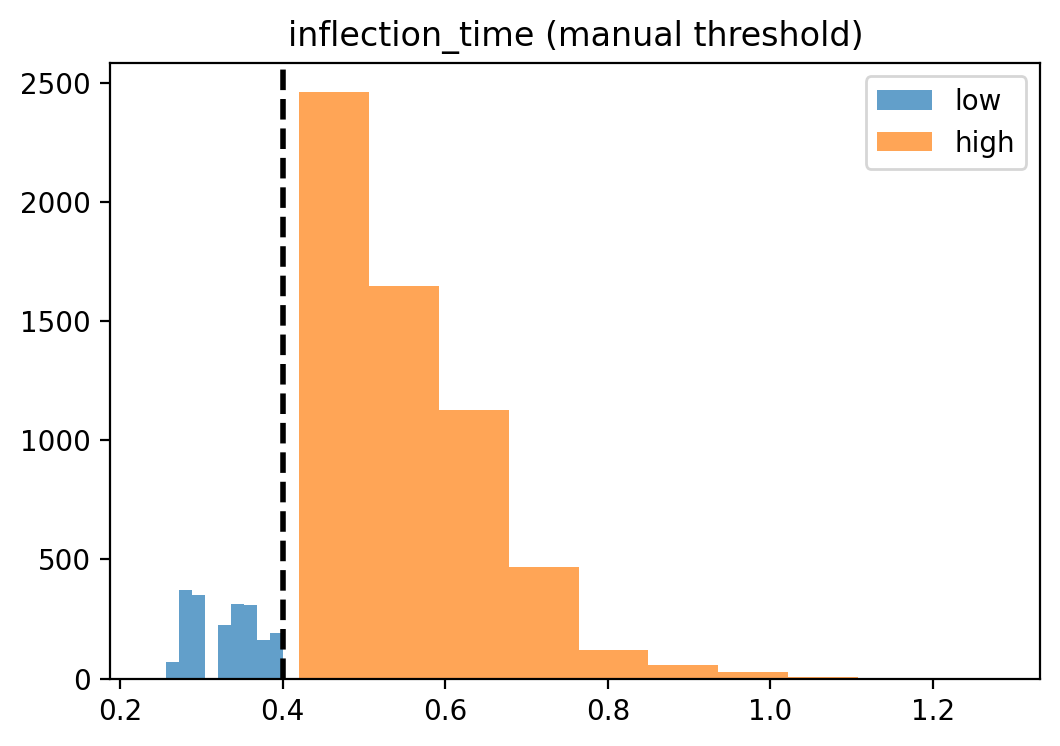

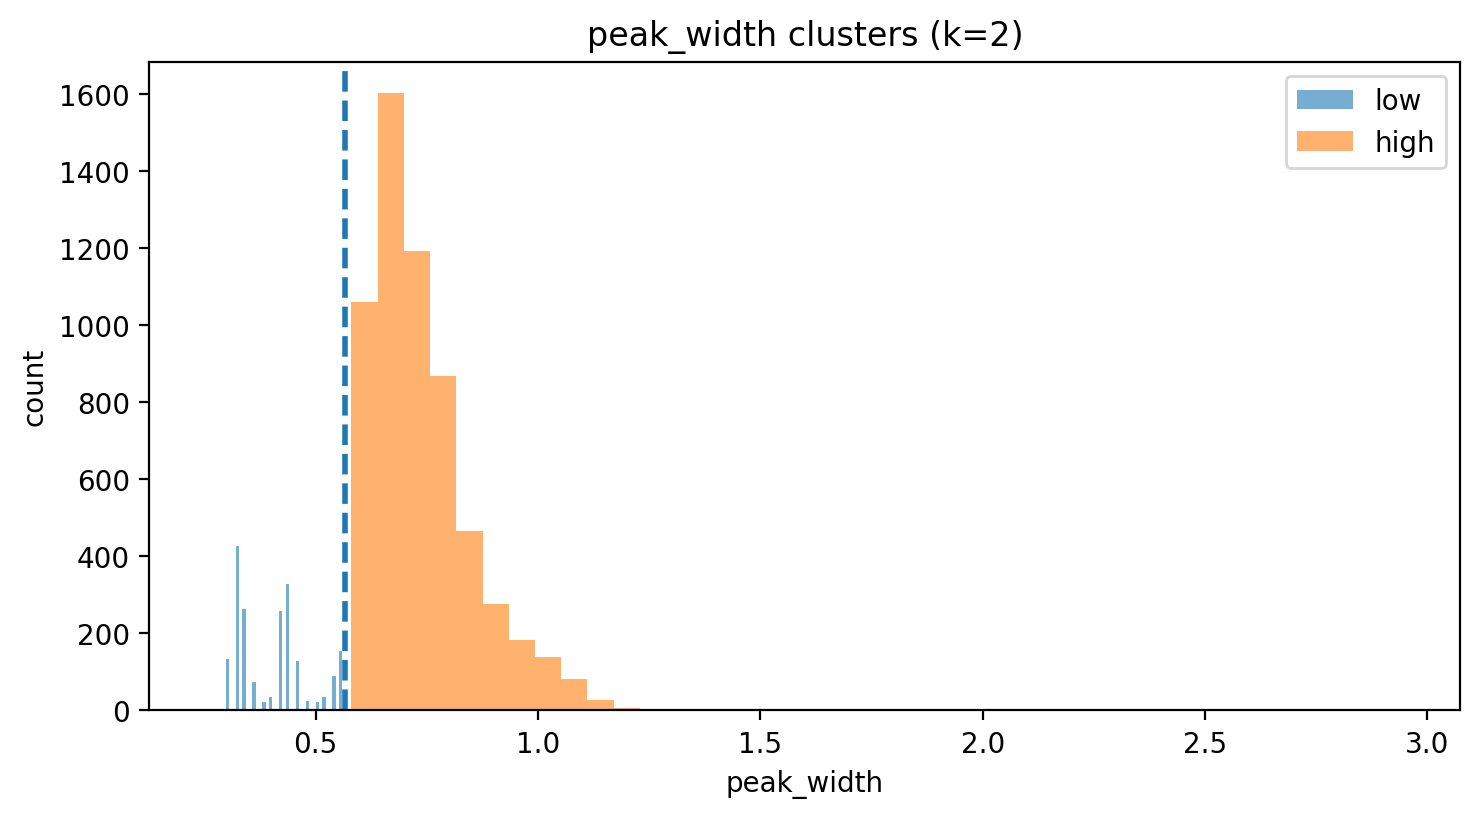

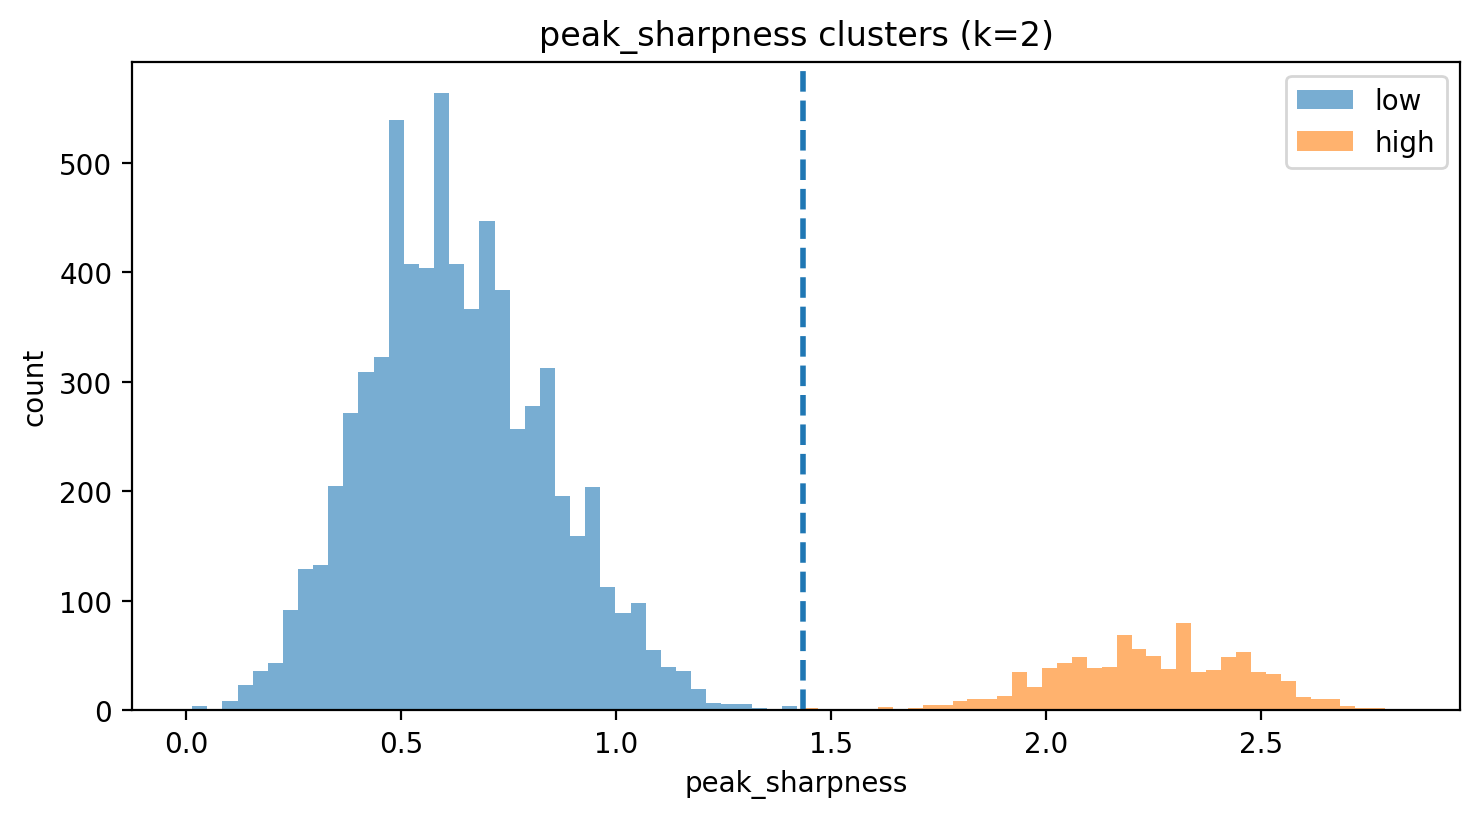

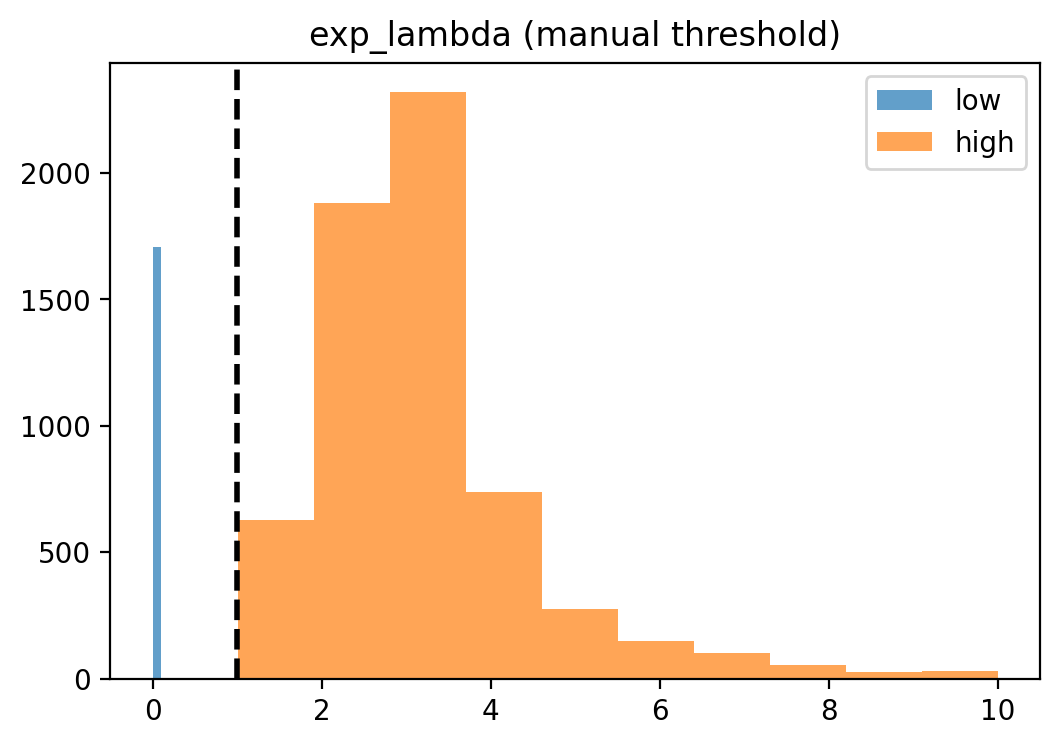

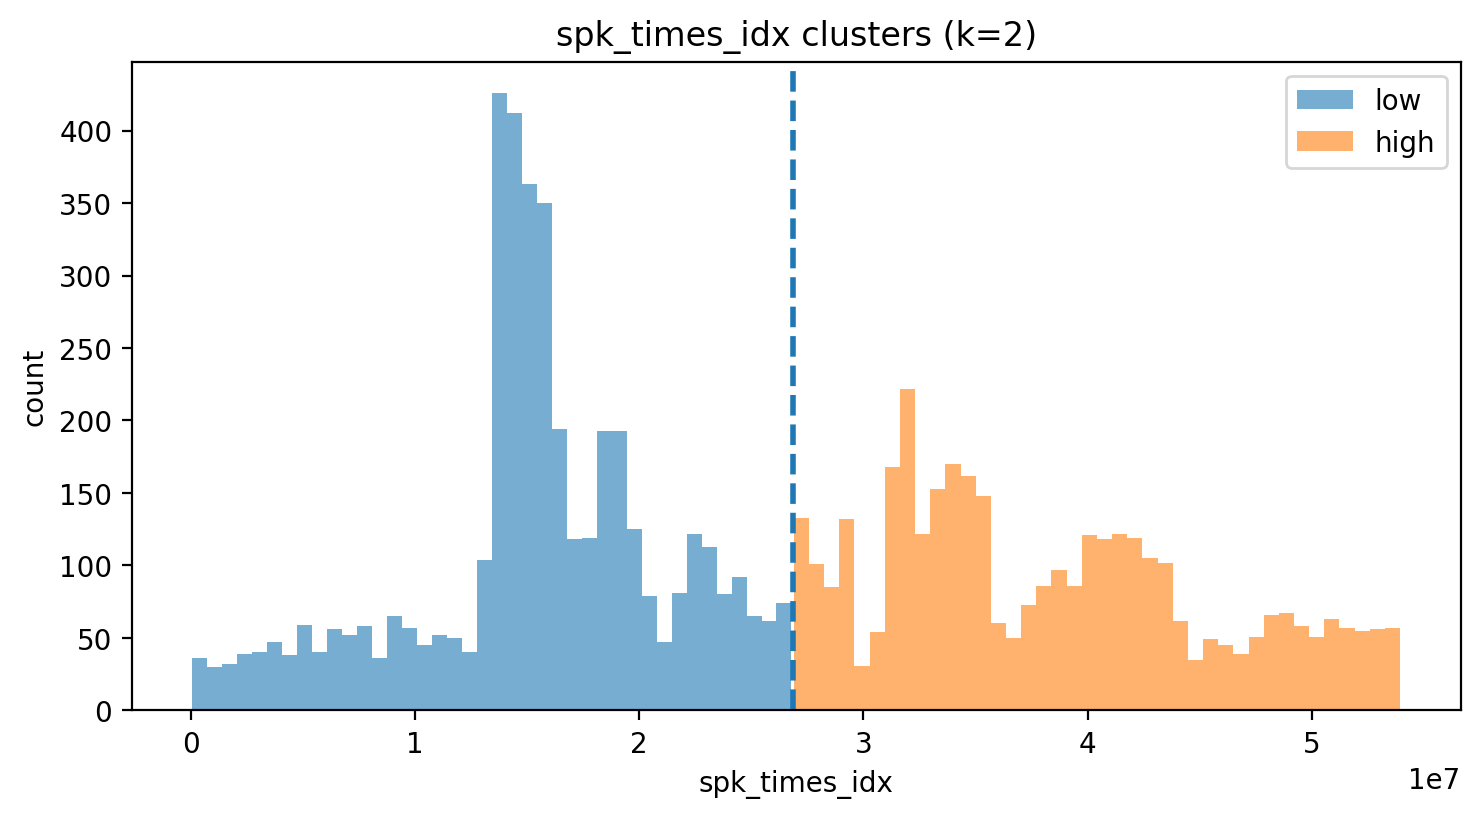

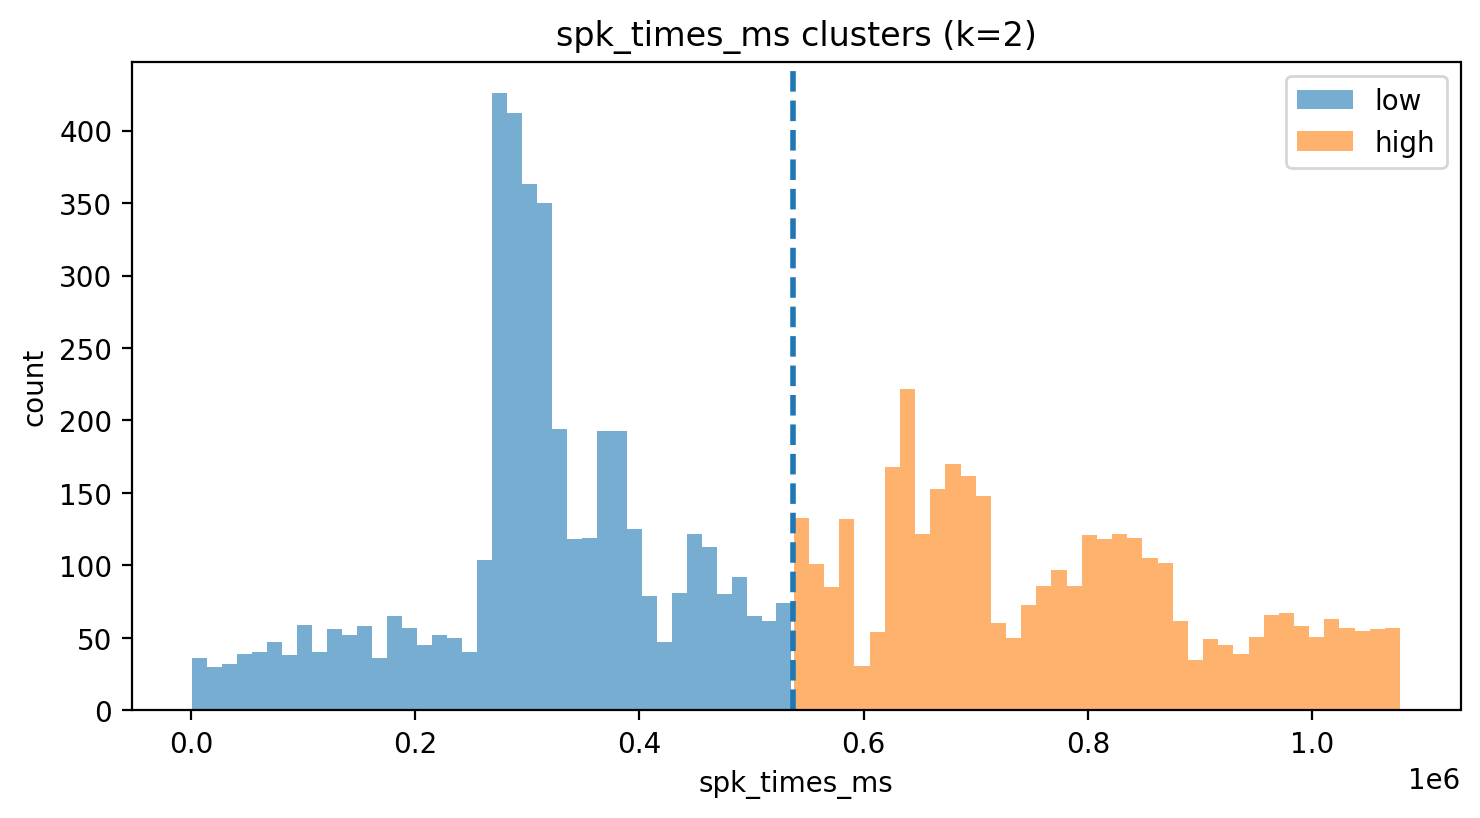

In [17]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=2,
    suffix="_cluster",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={"ramp_amp":0, "inflection_time":0.4, "exp_lambda":1
    }
)





===== CLUSTER REPORT: ramp_amp_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


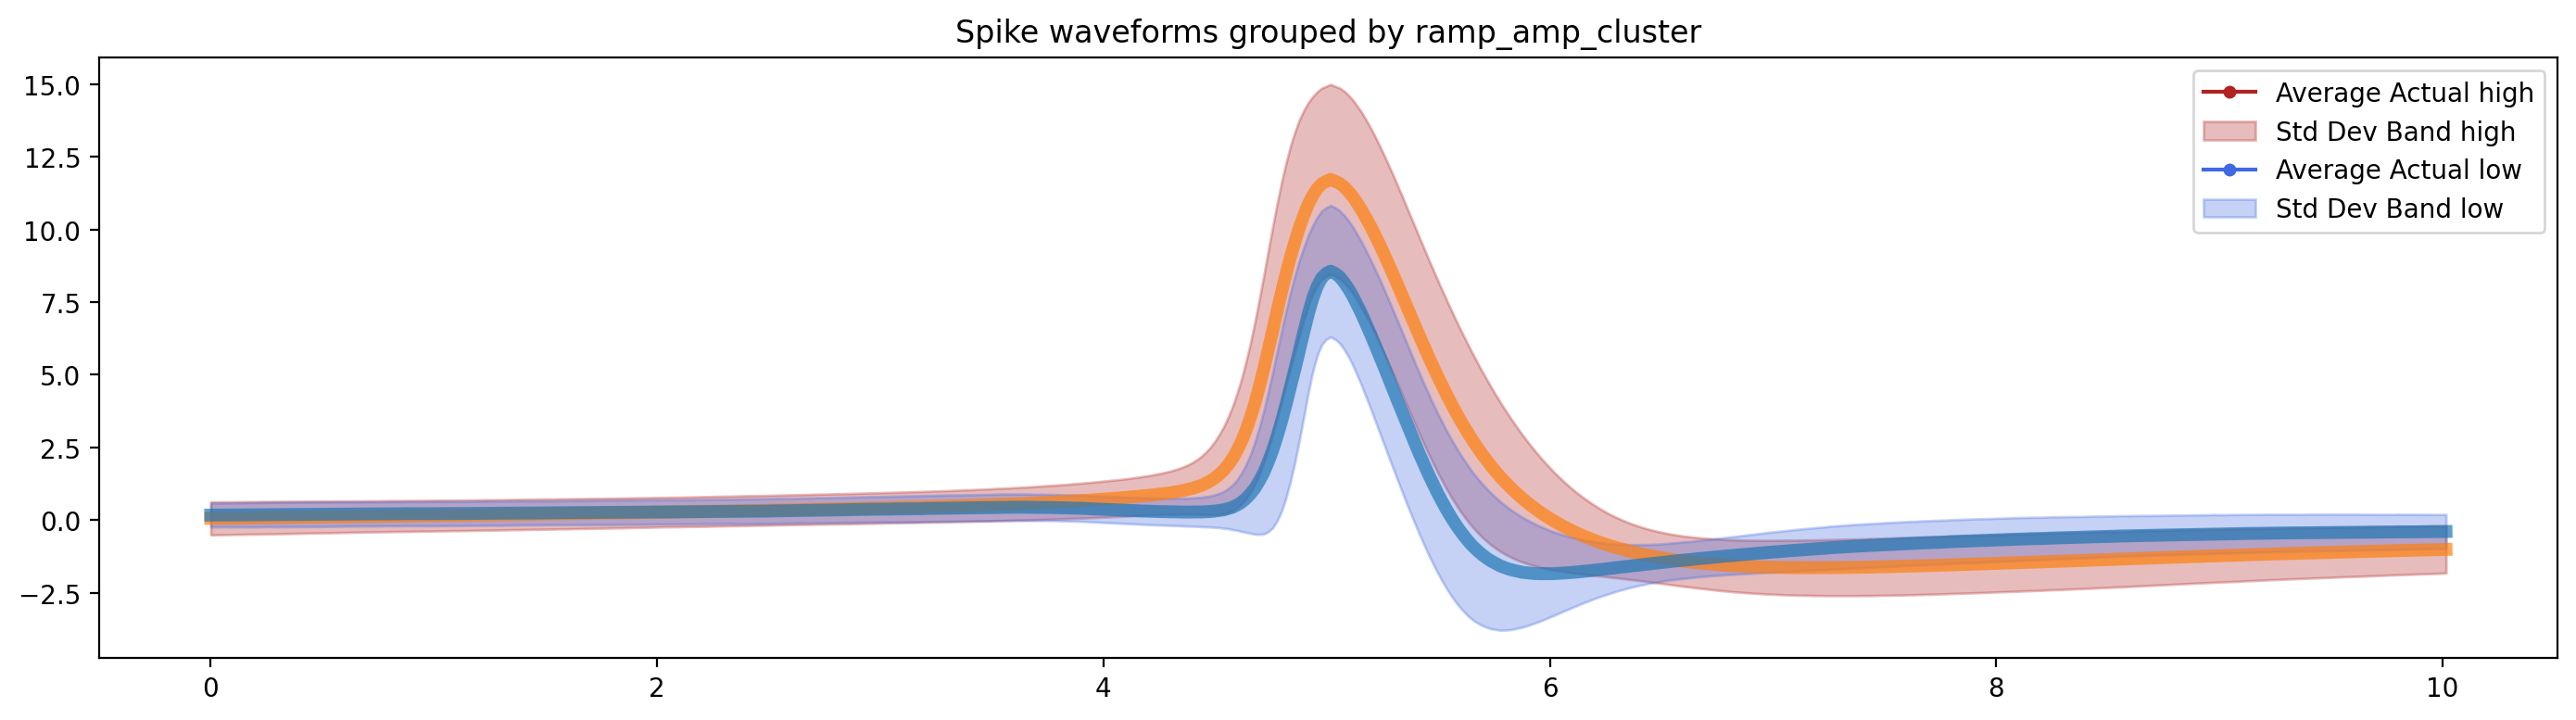

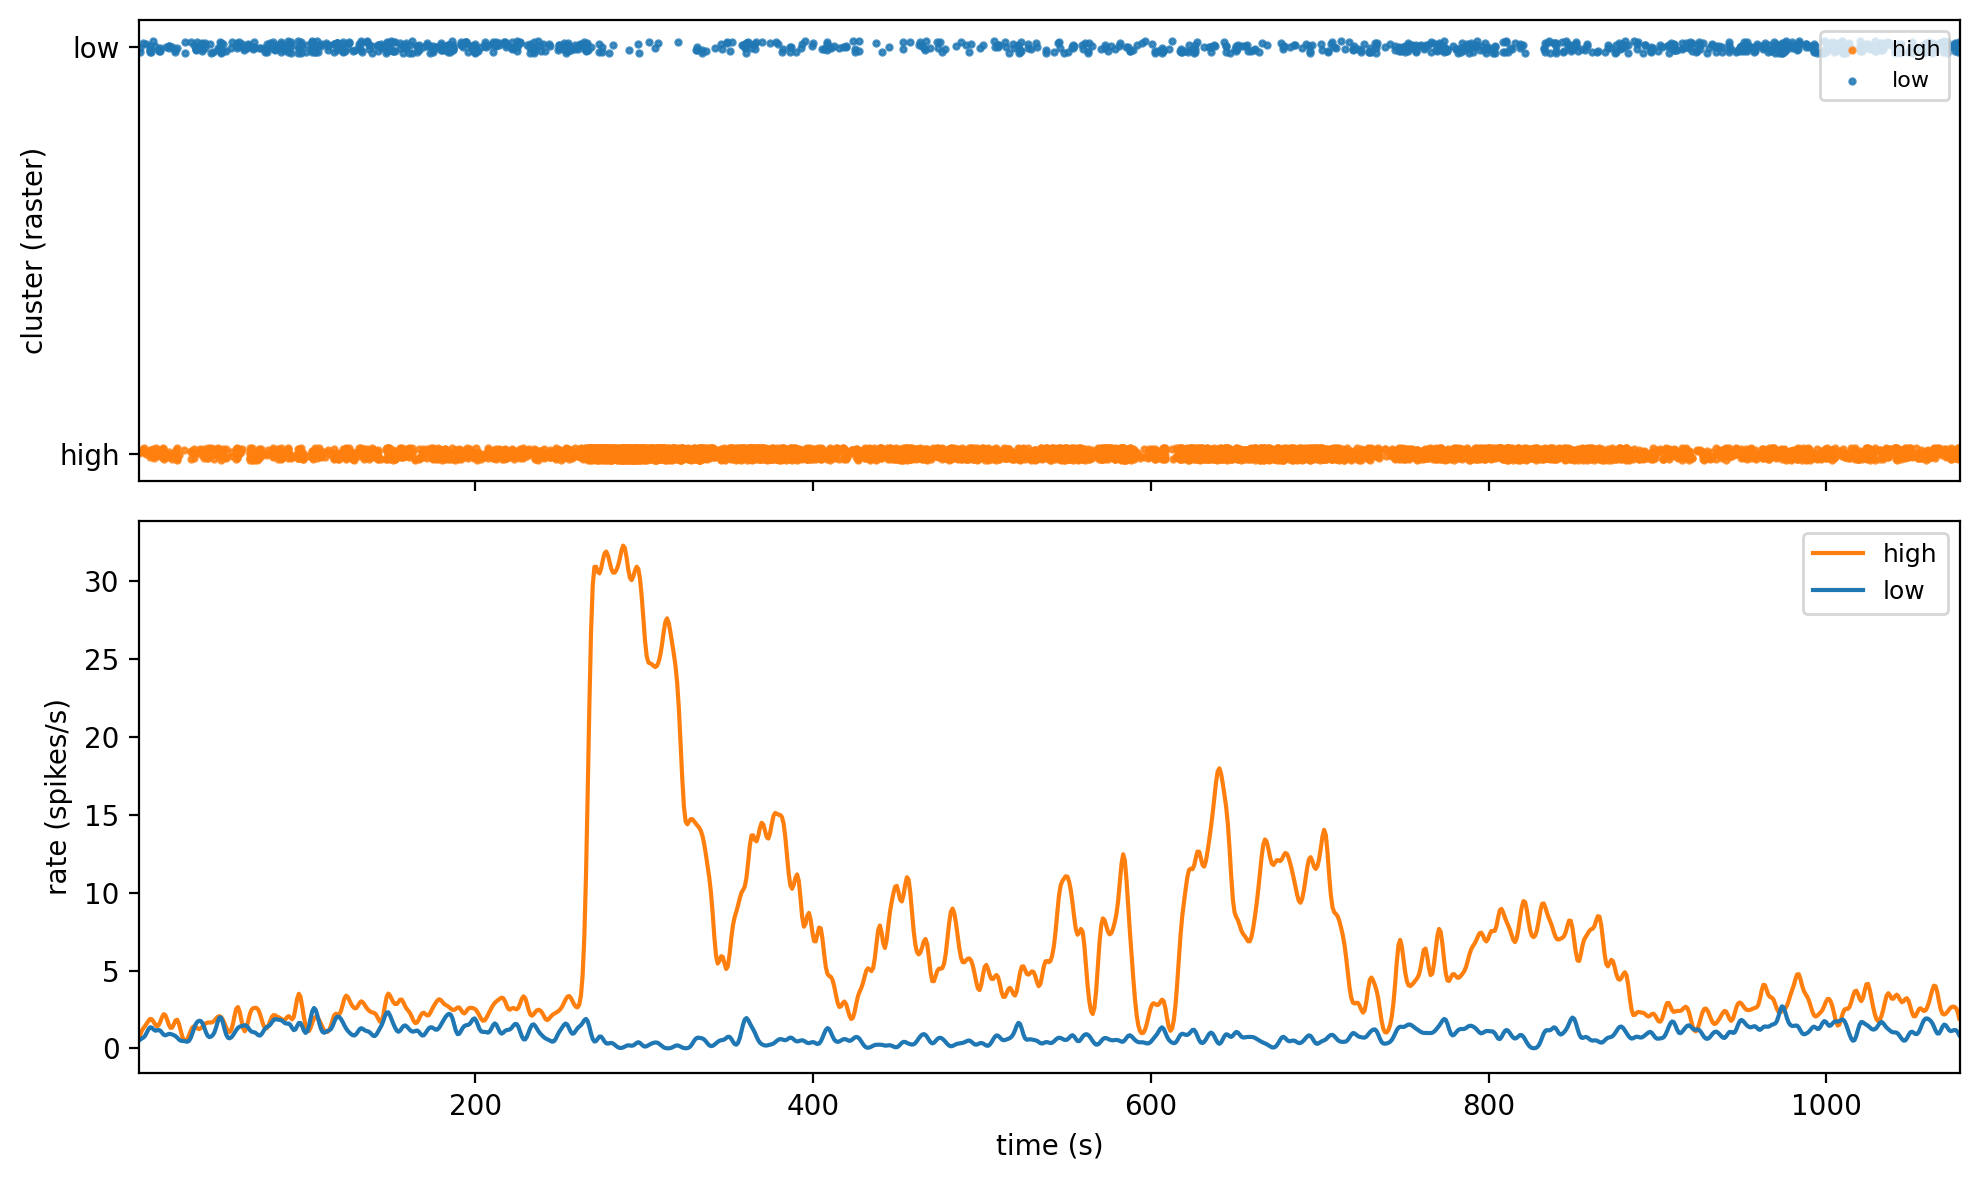

→ Computing cluster transition matrix


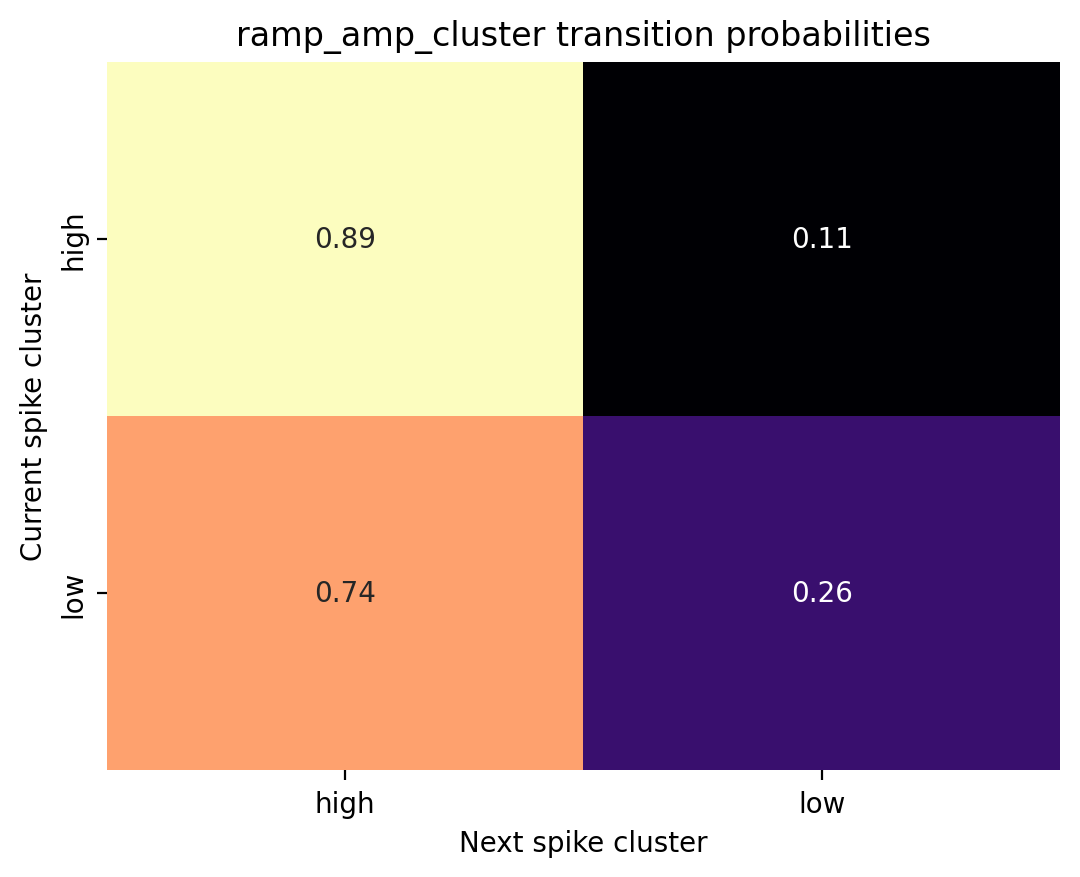

→ Visualizing high vs low feature distributions


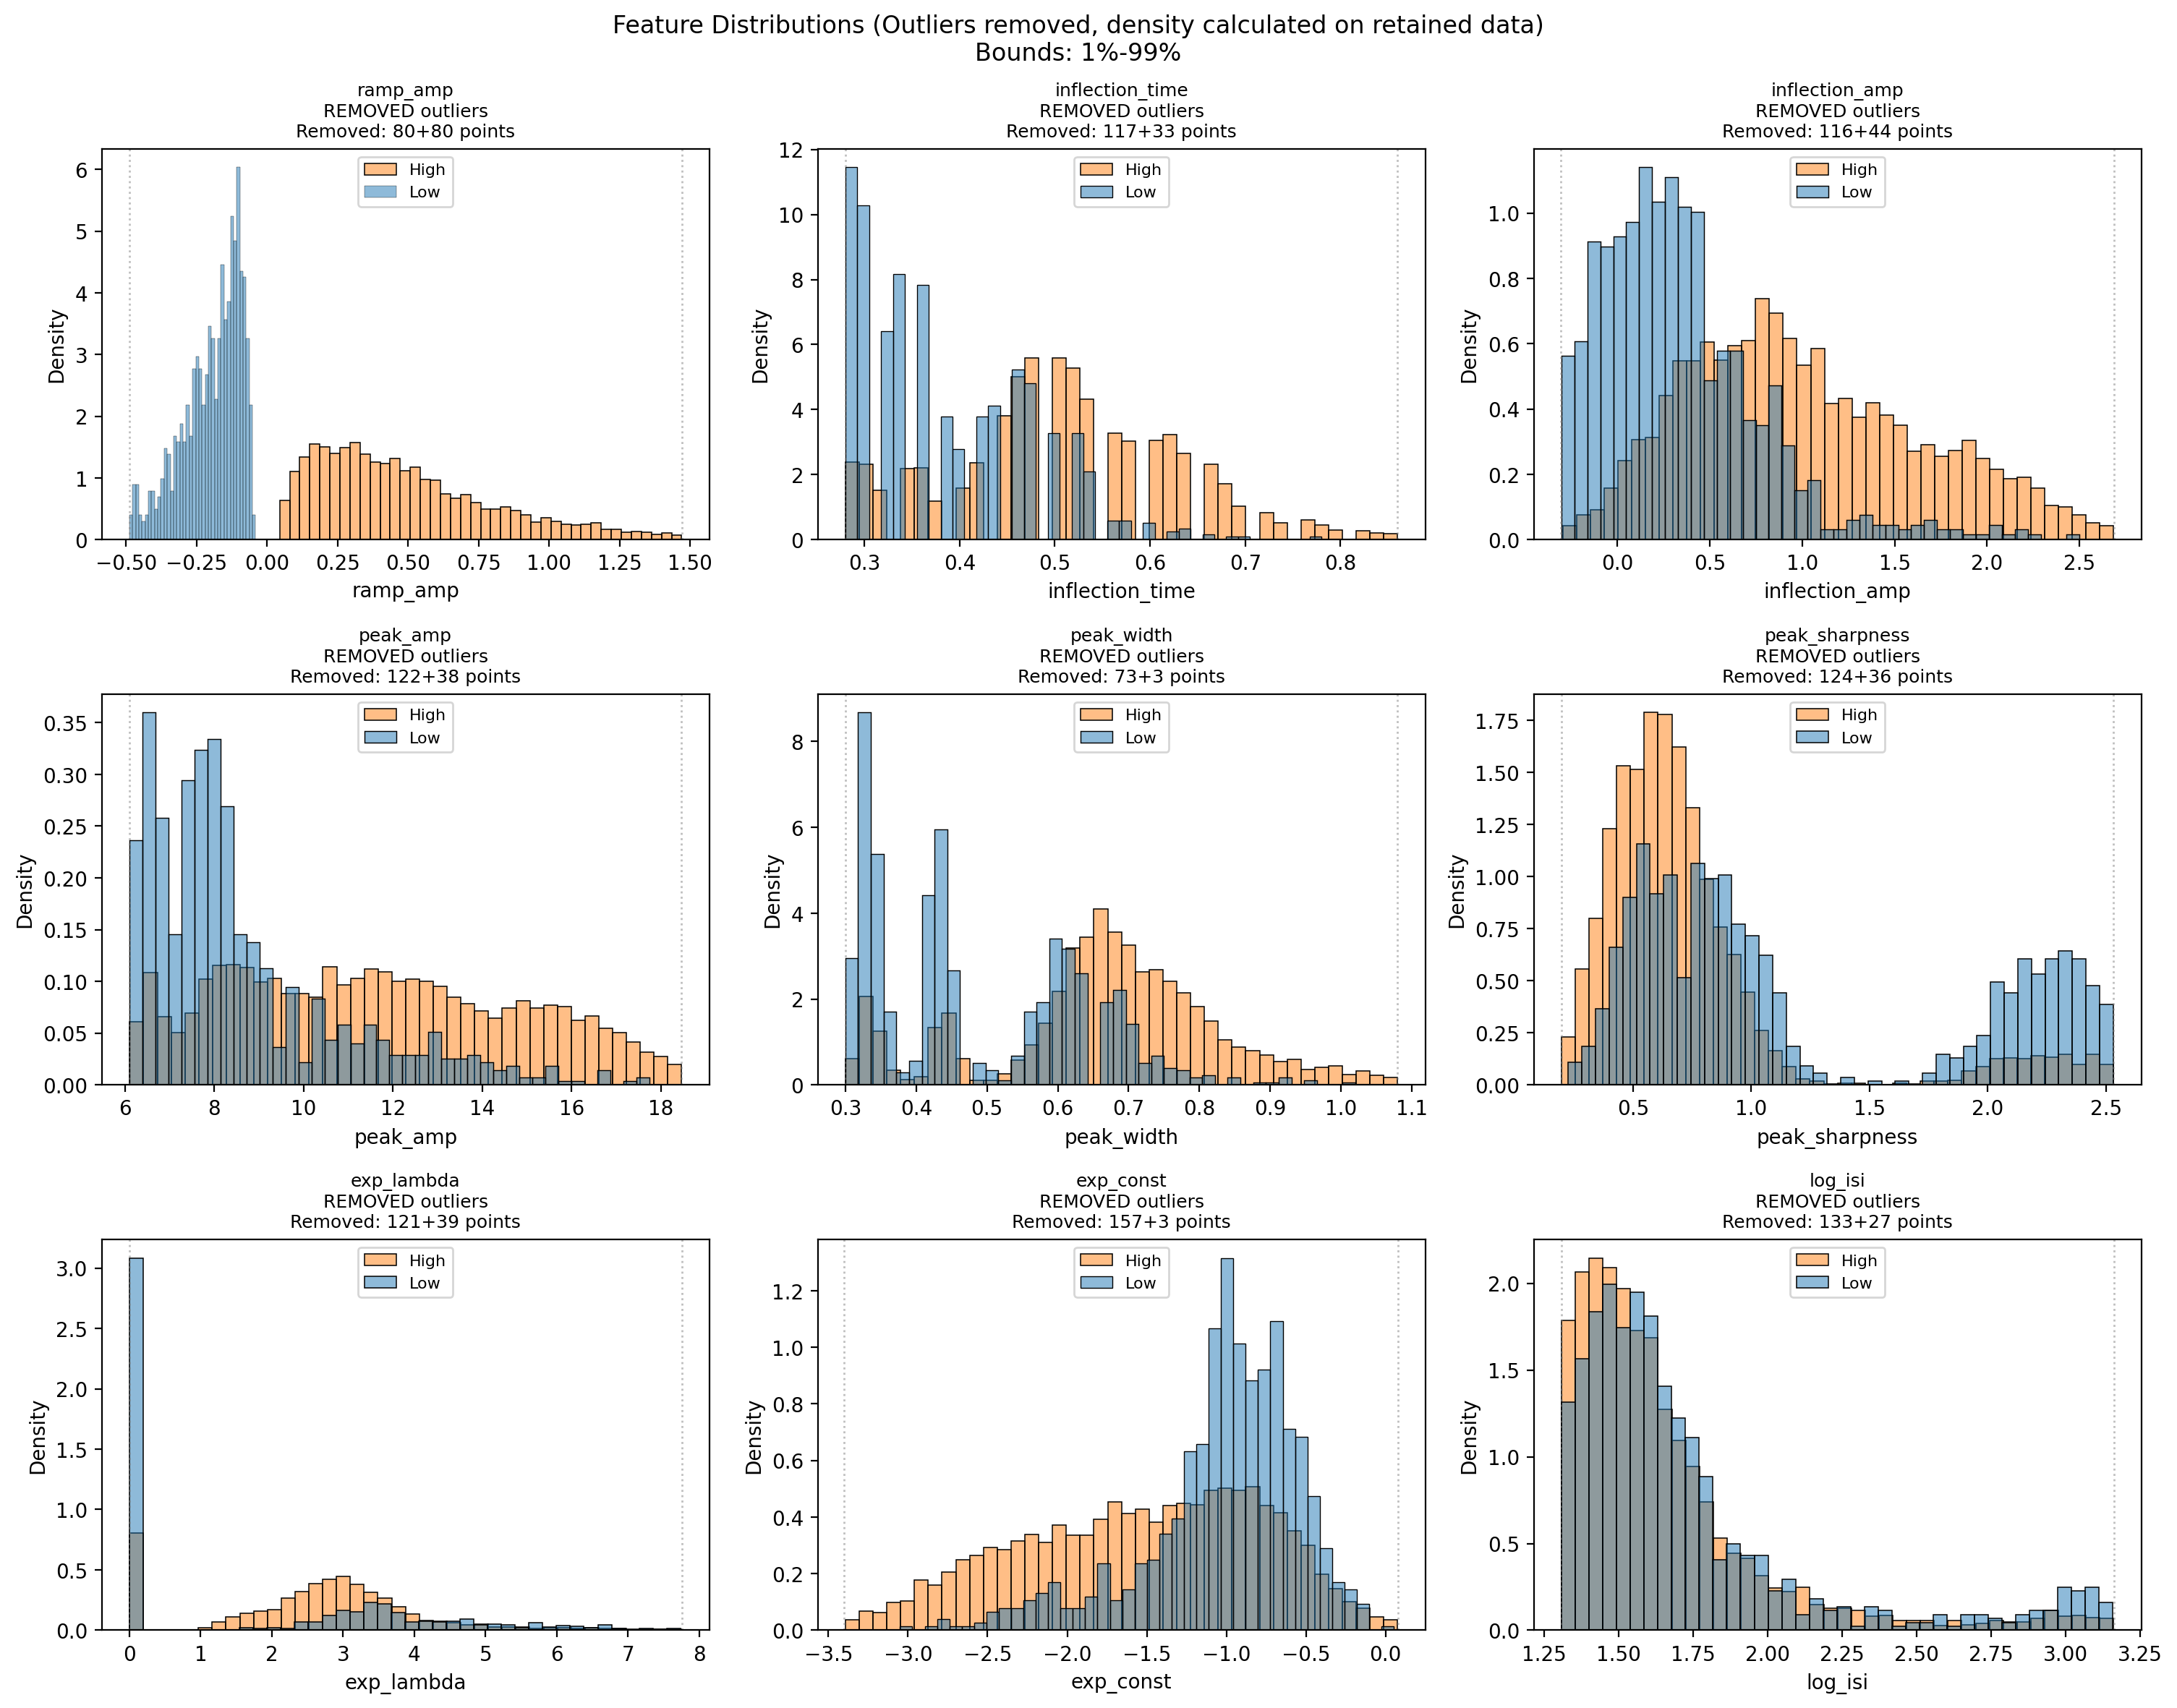

===== DONE =====


===== CLUSTER REPORT: inflection_time_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


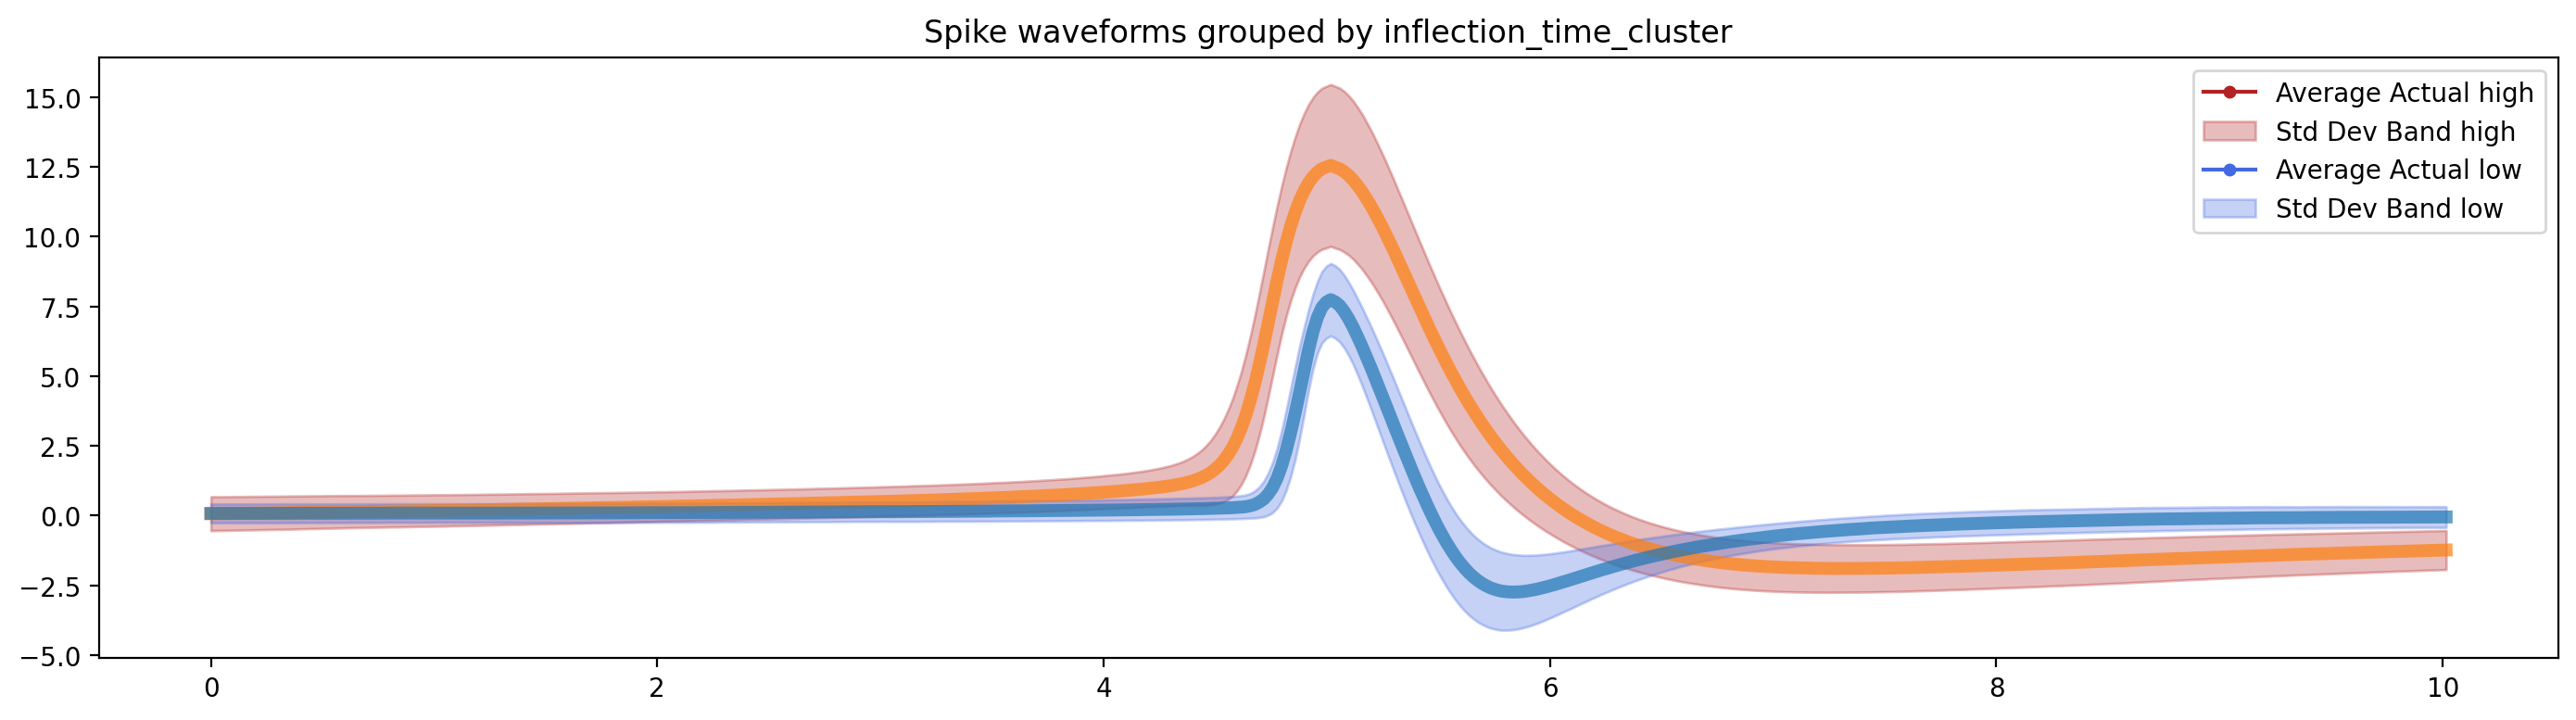

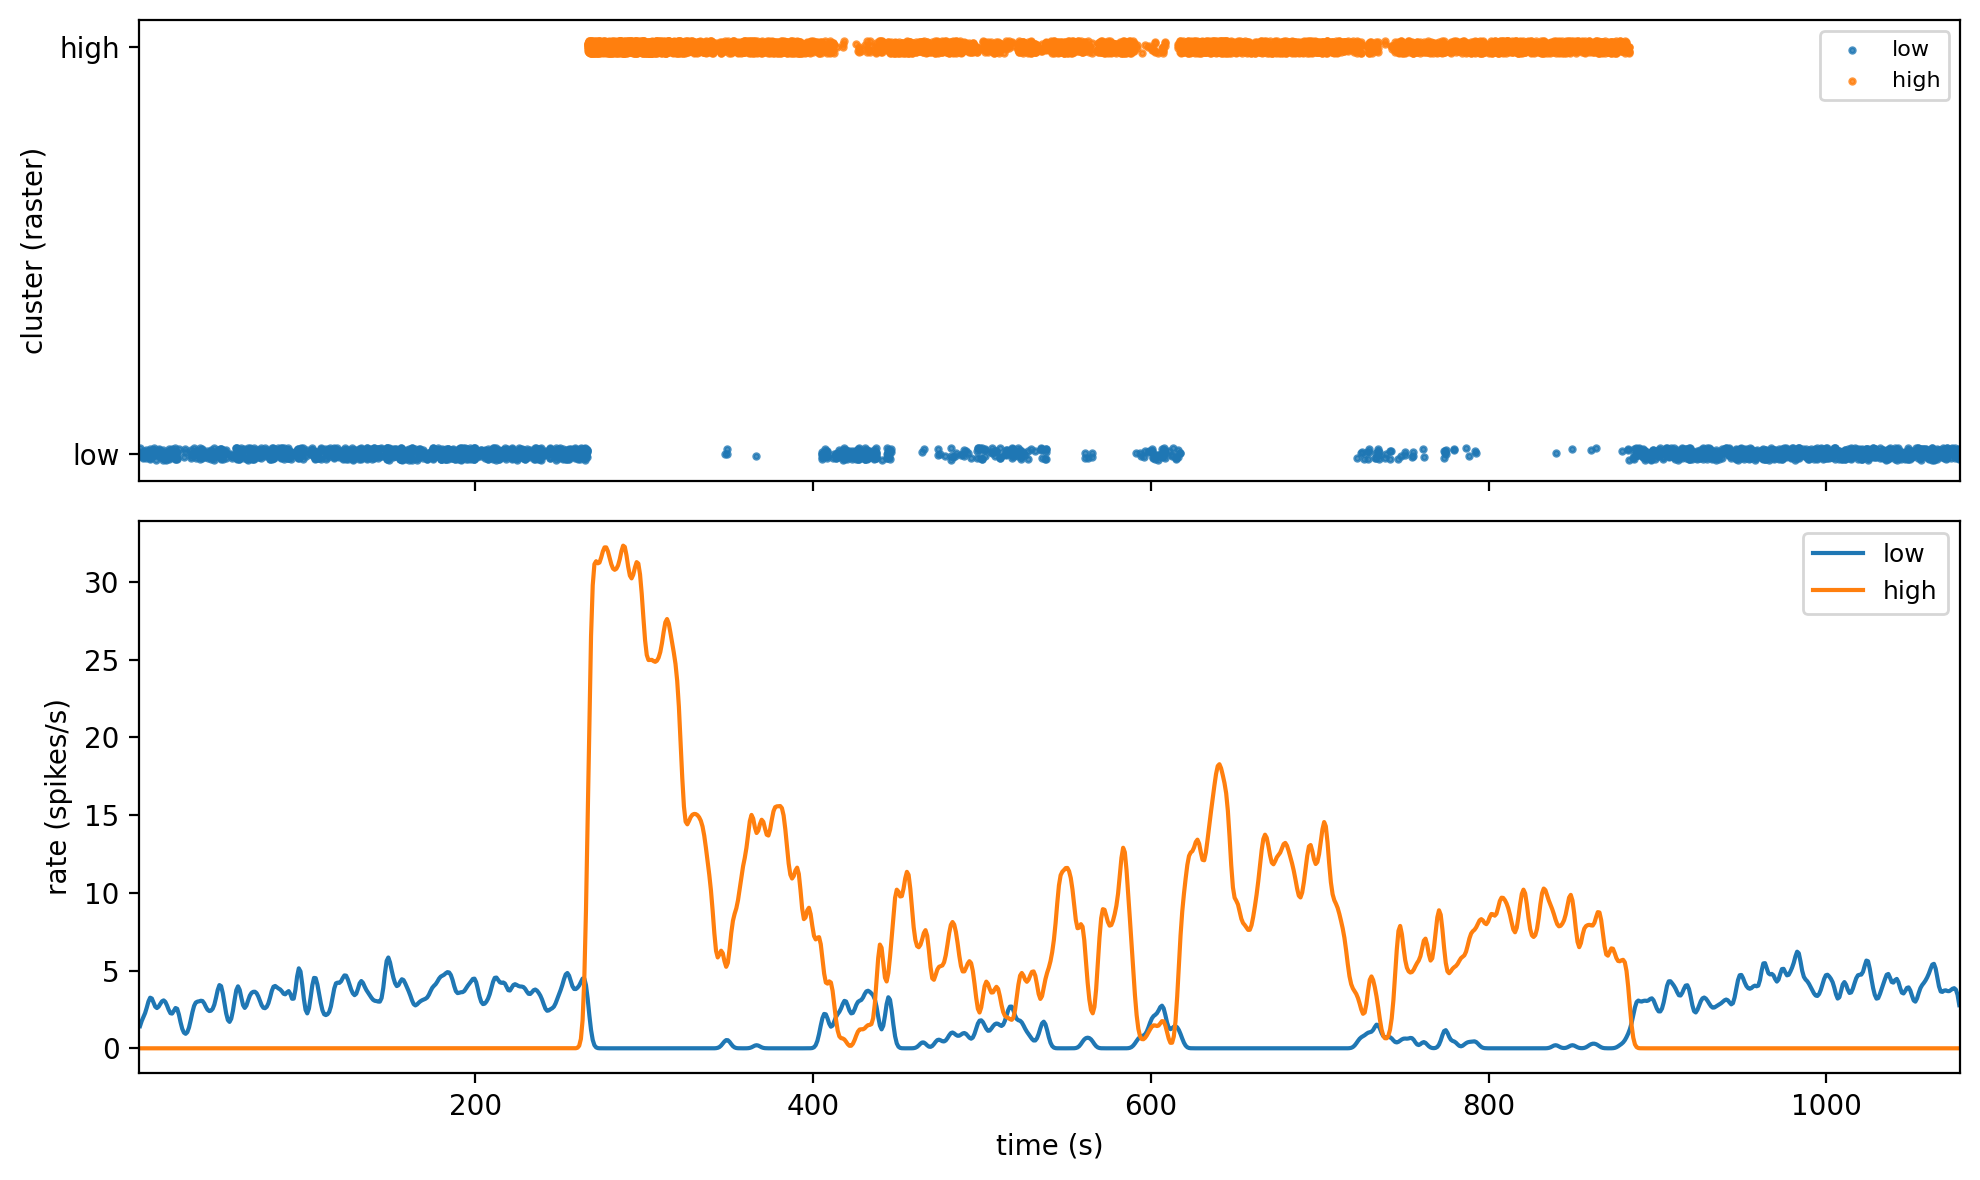

→ Computing cluster transition matrix


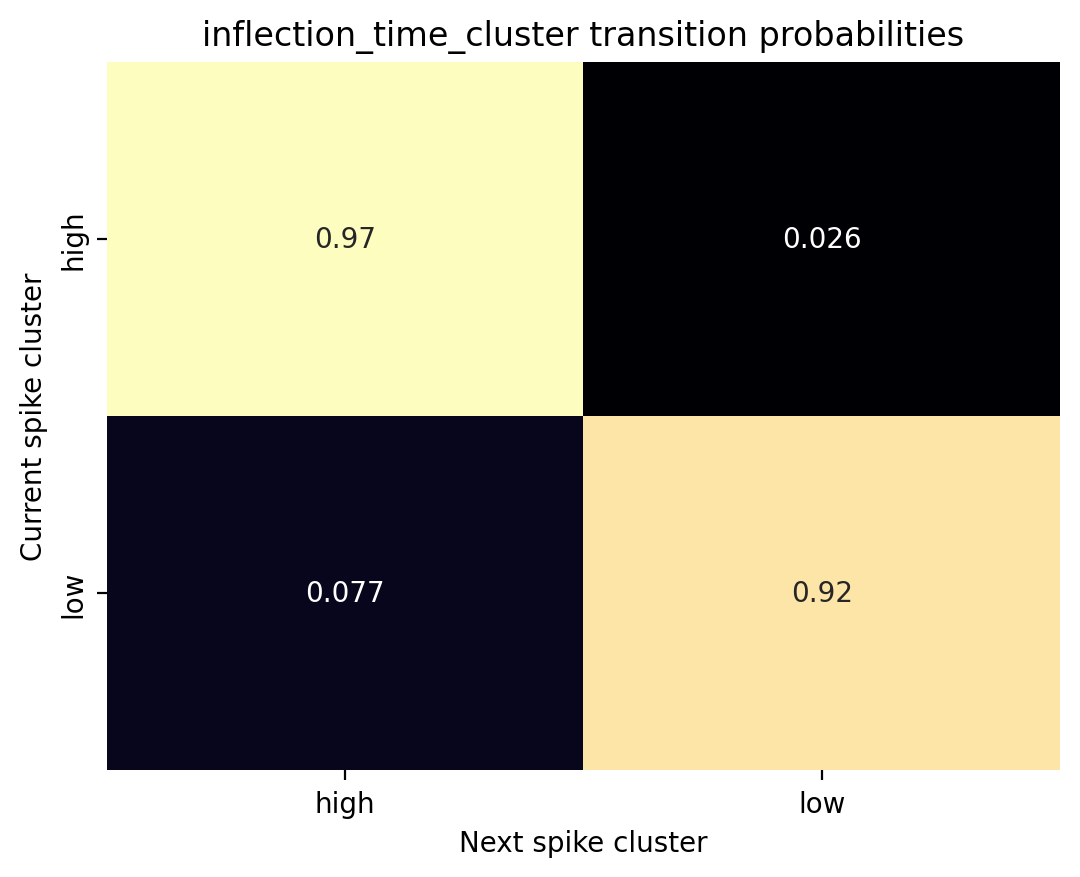

→ Visualizing high vs low feature distributions


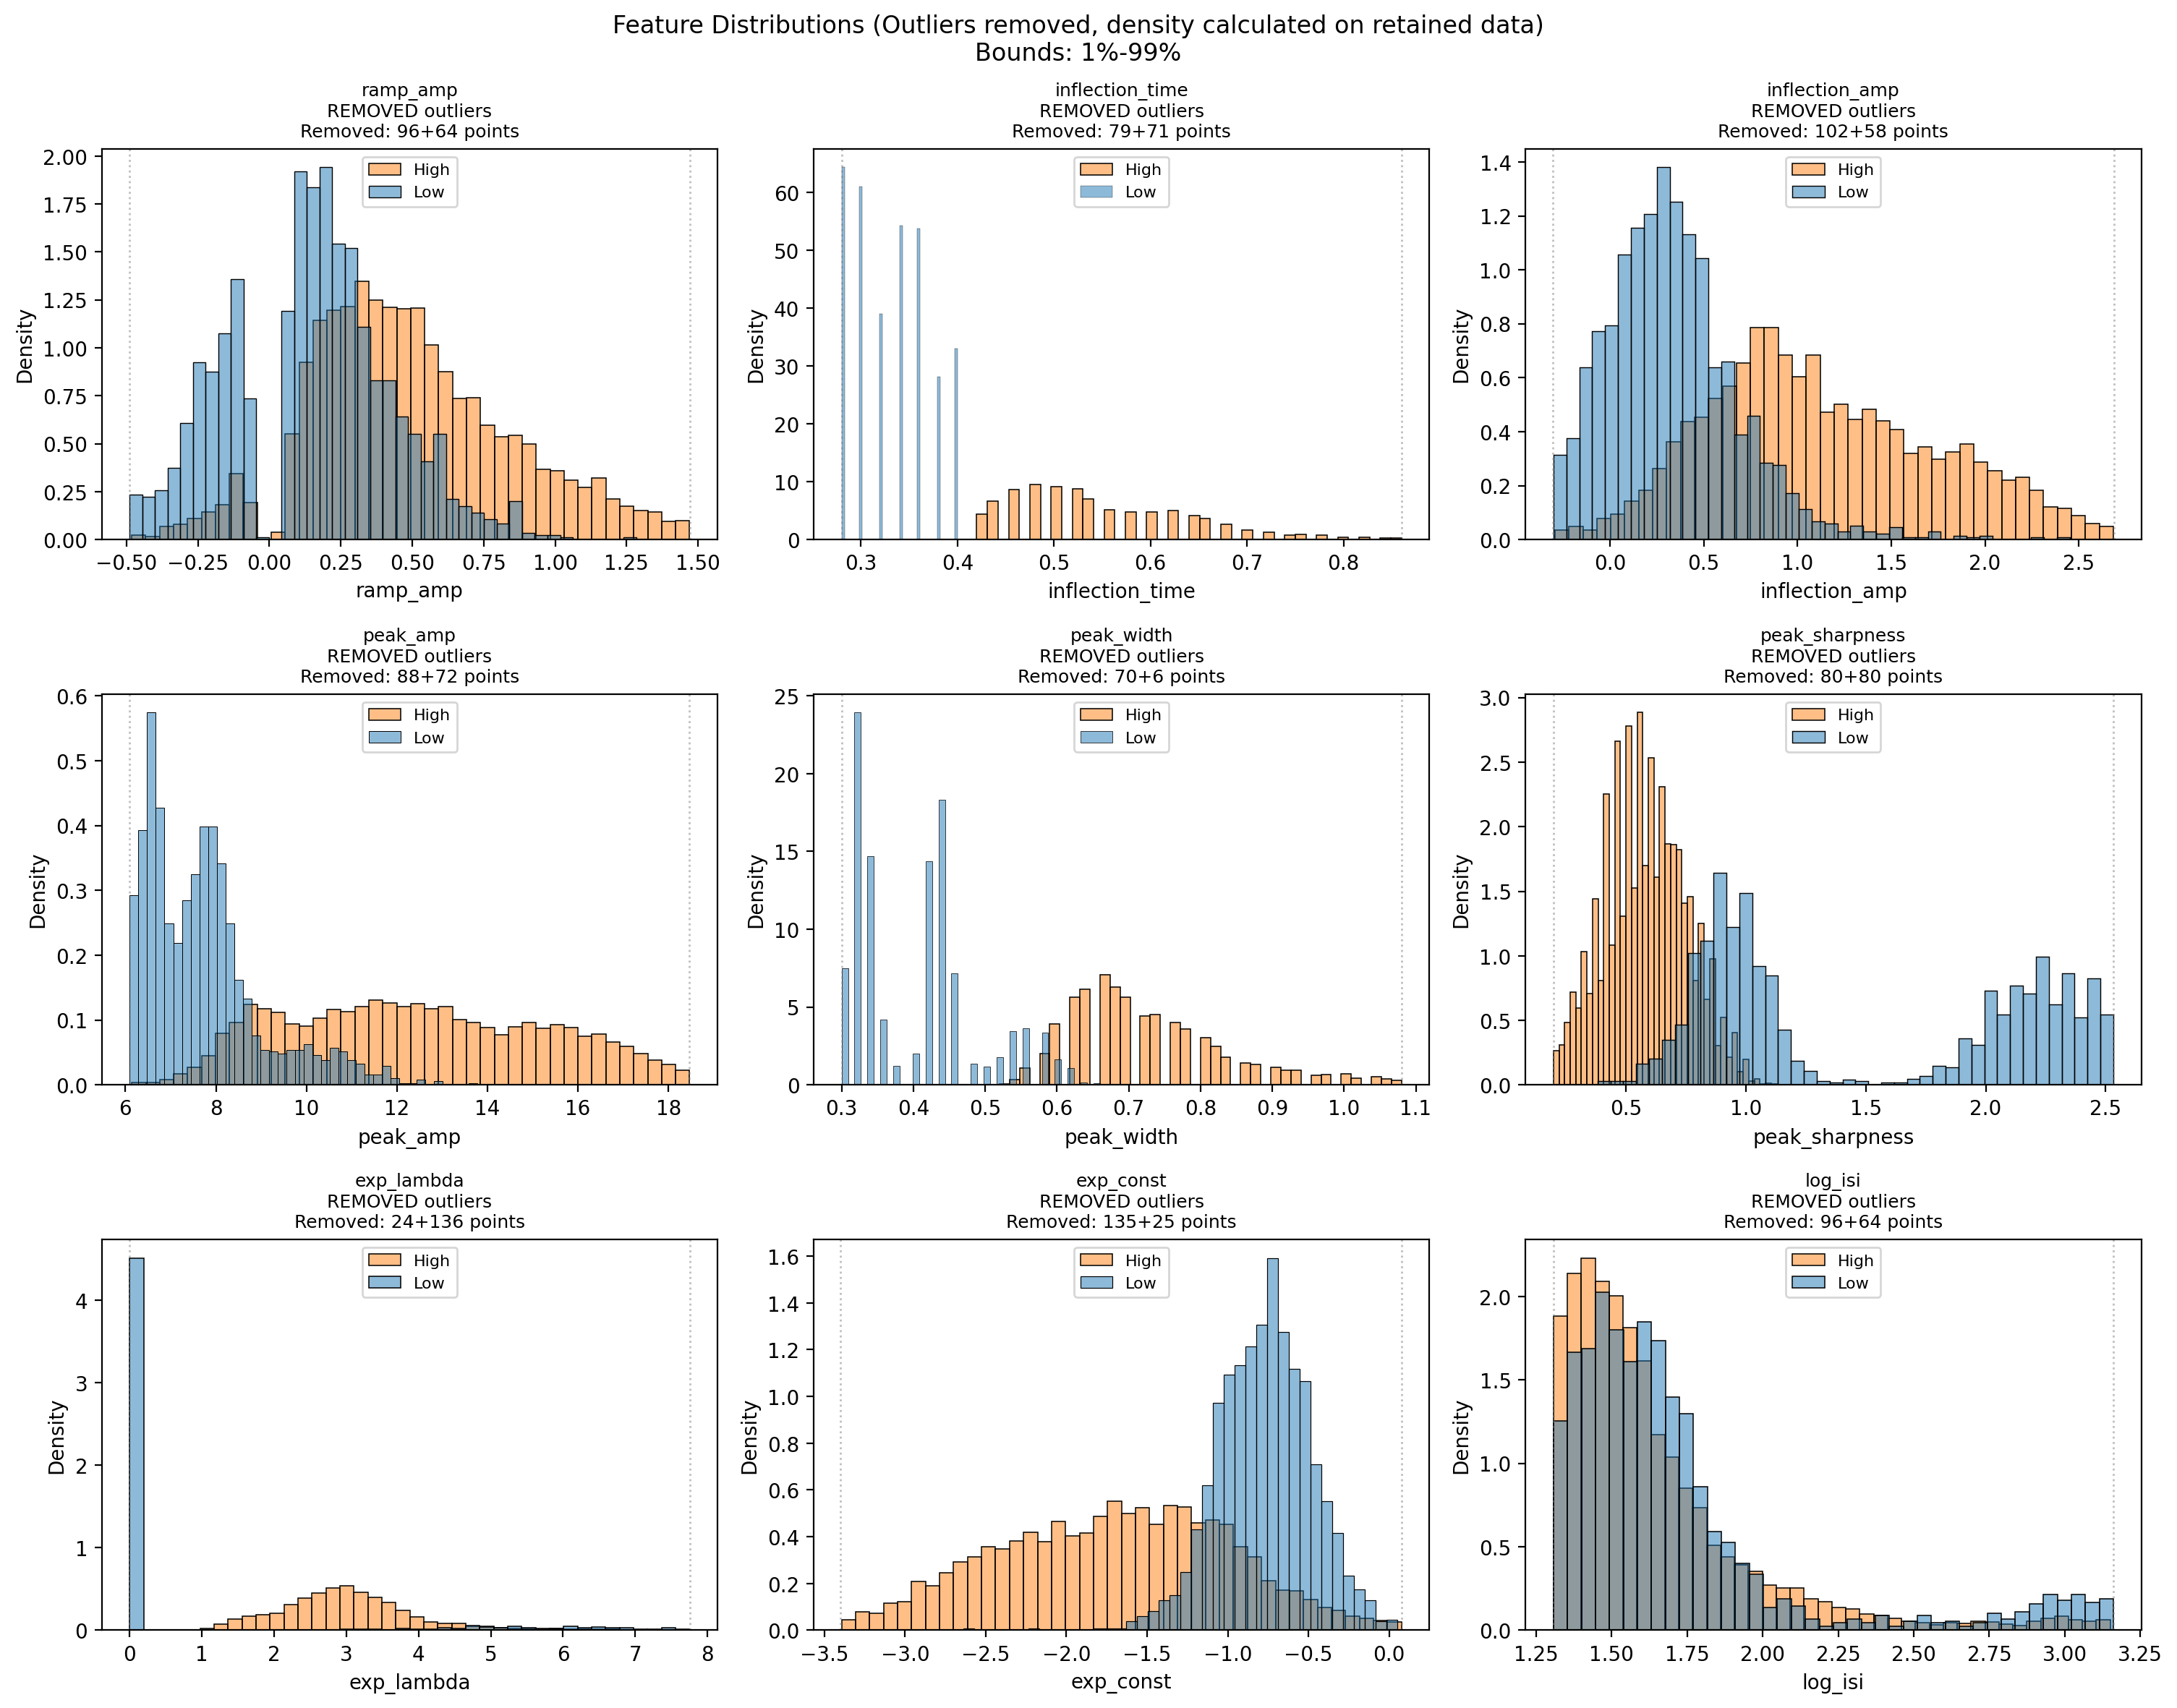

===== DONE =====


===== CLUSTER REPORT: peak_width_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


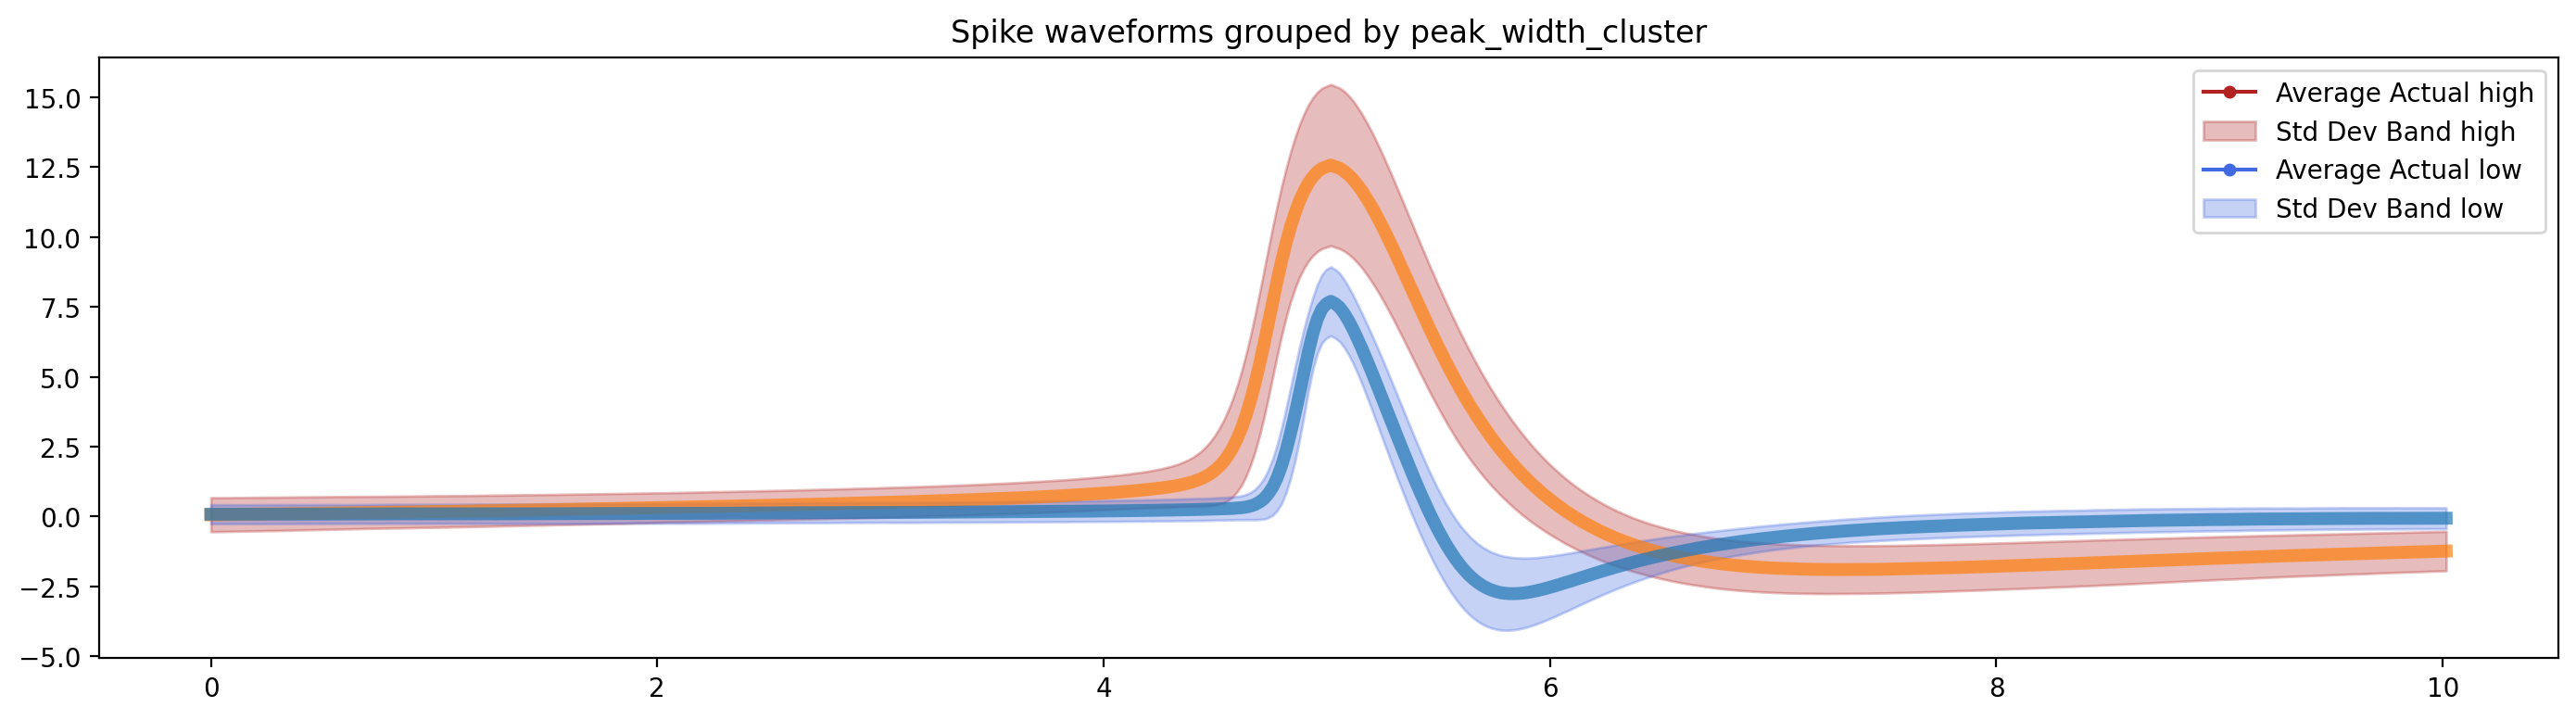

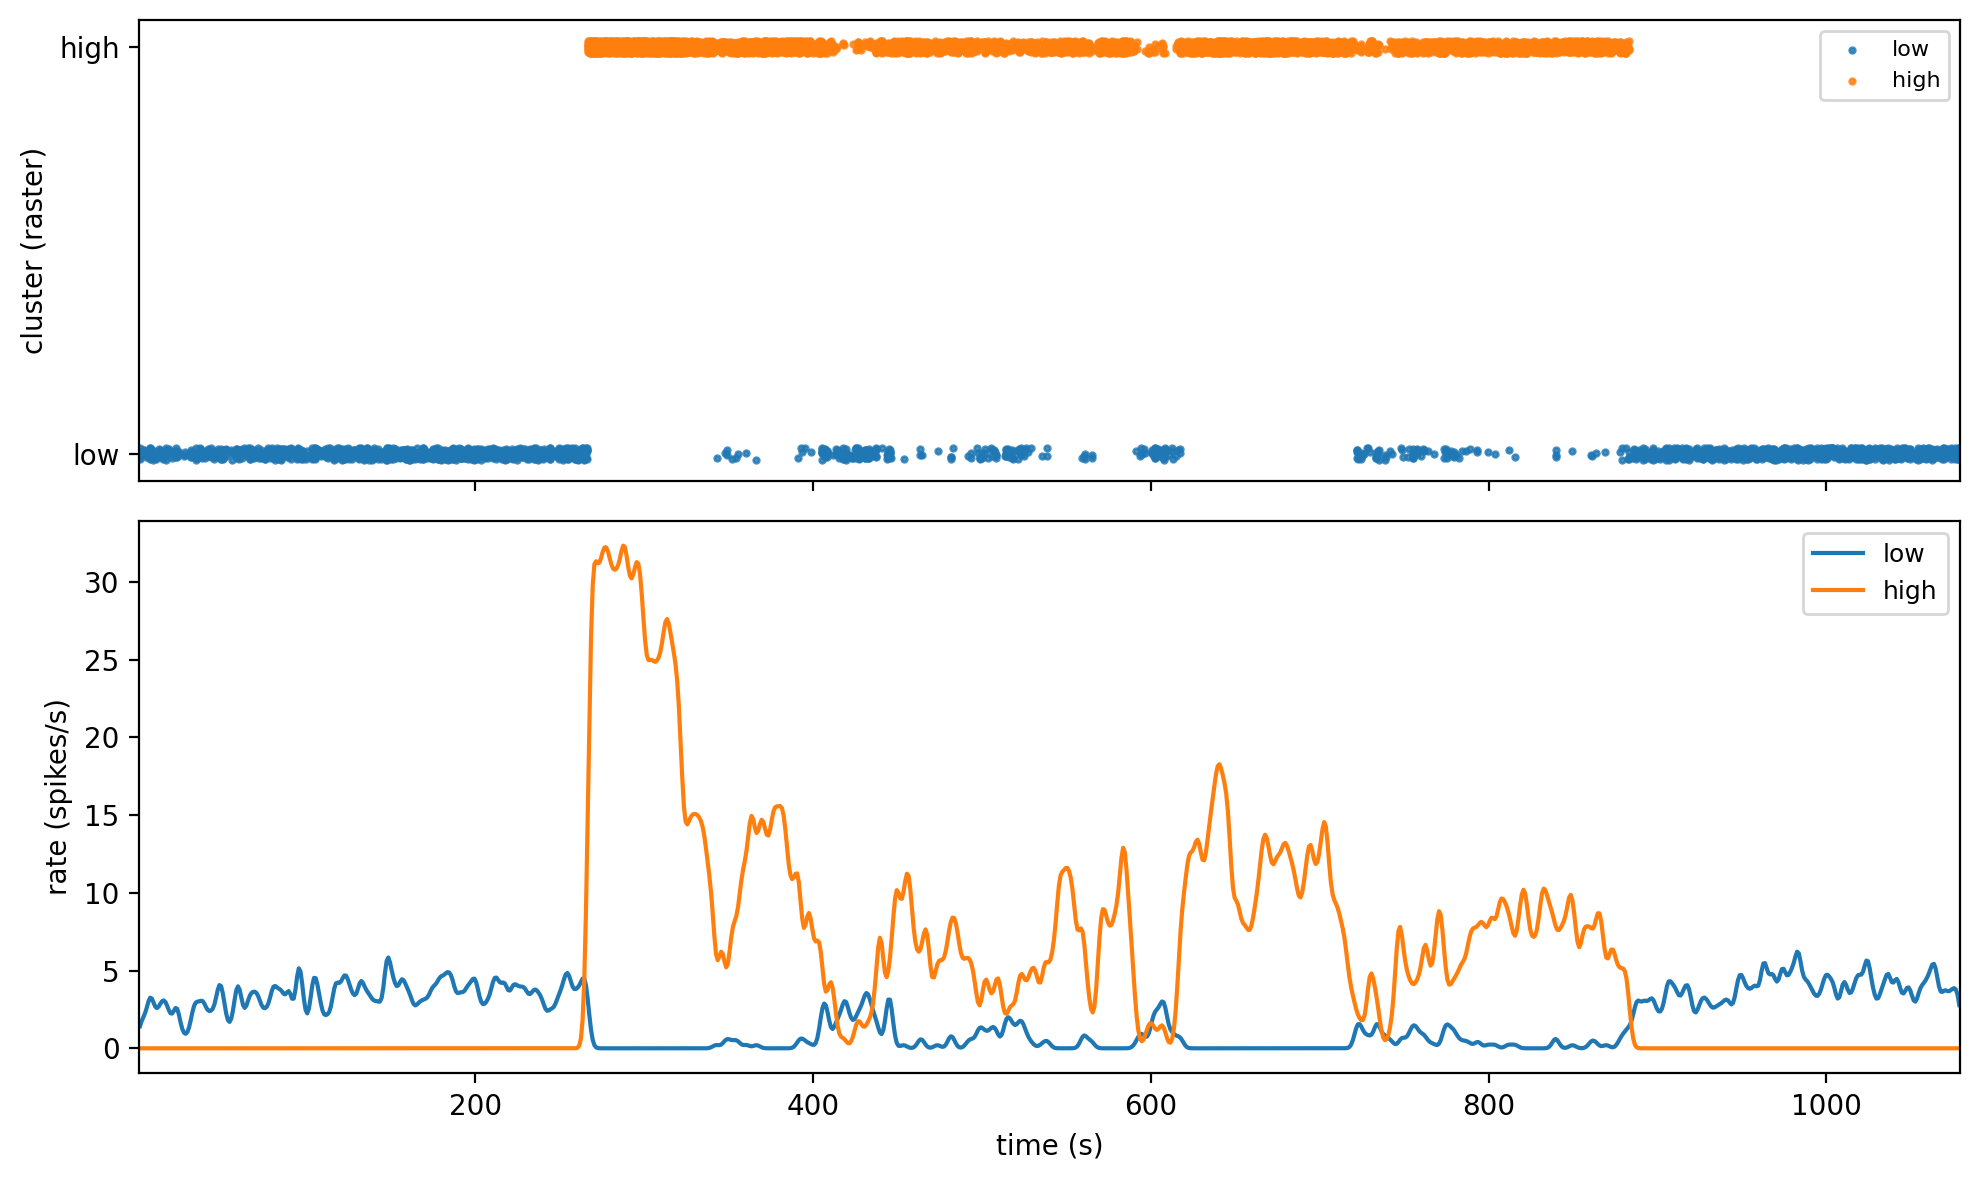

→ Computing cluster transition matrix


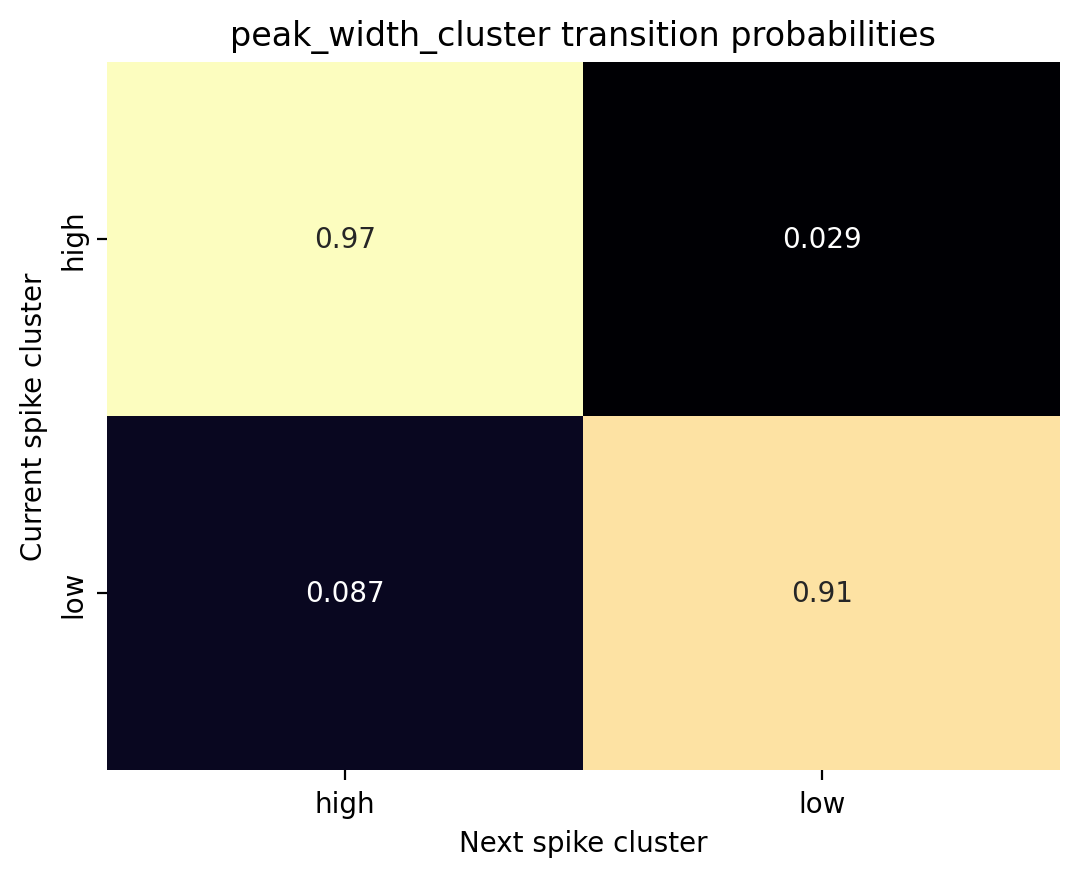

→ Visualizing high vs low feature distributions


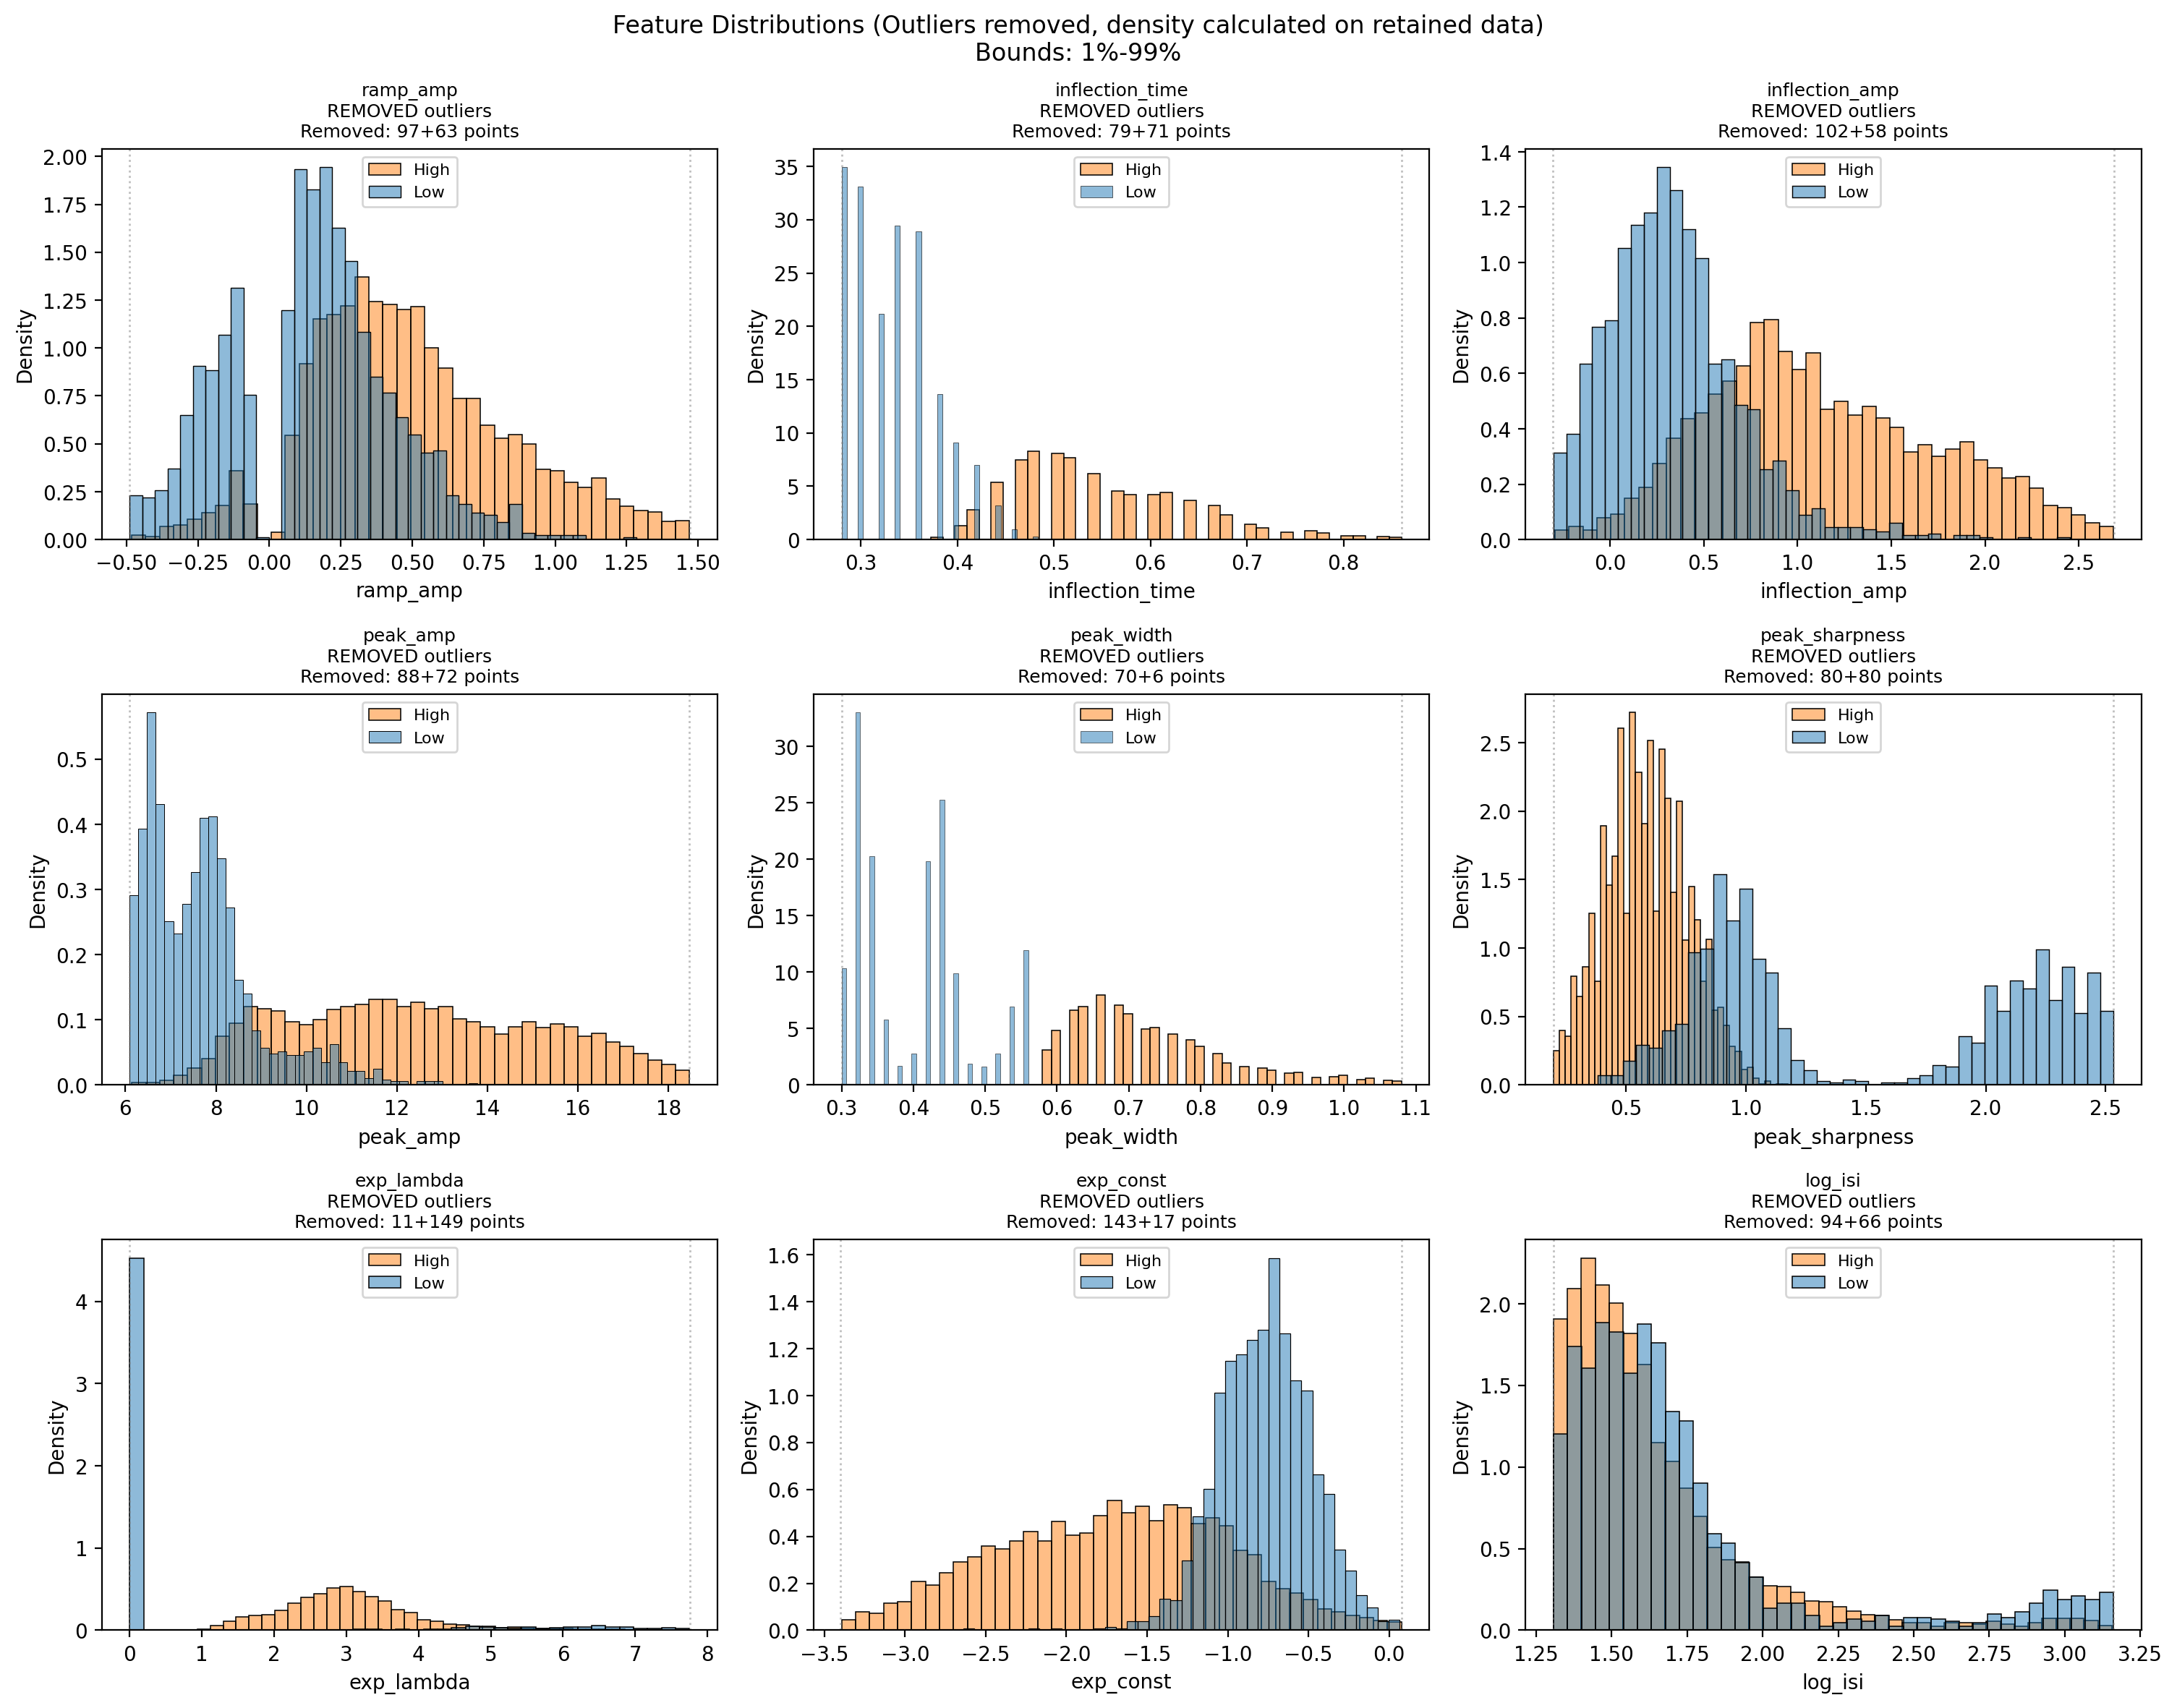

===== DONE =====


===== CLUSTER REPORT: peak_sharpness_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


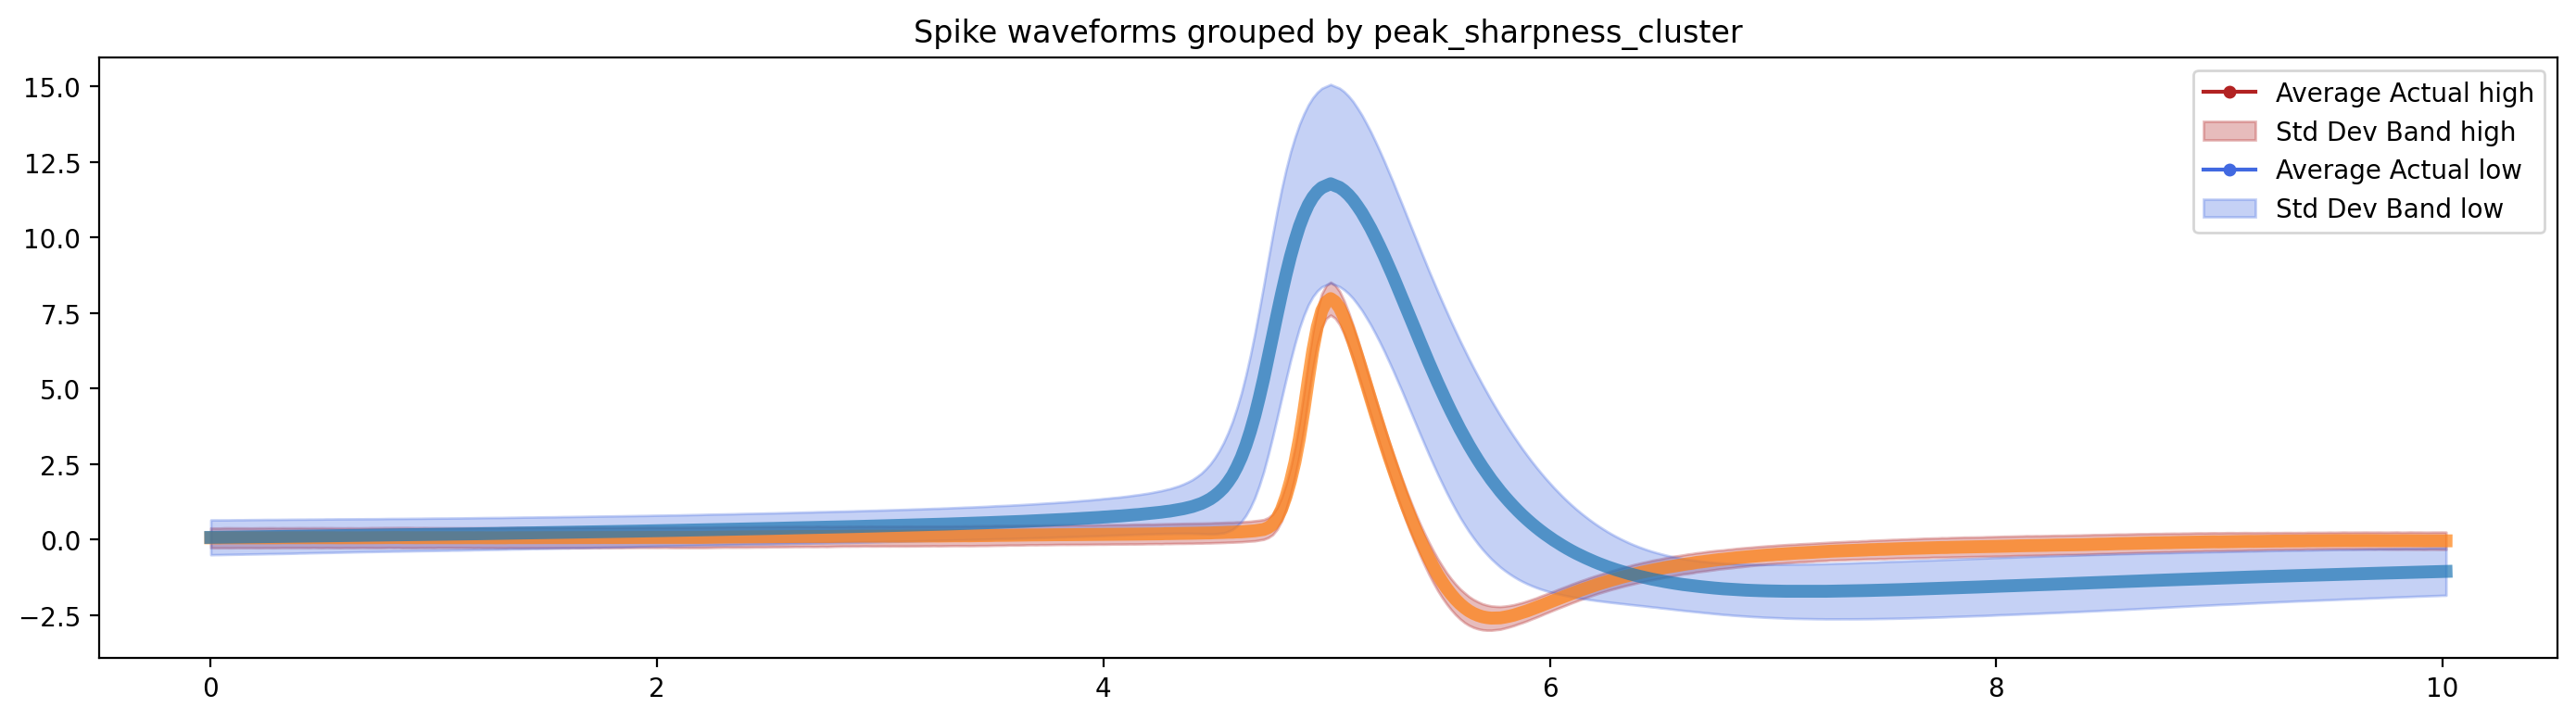

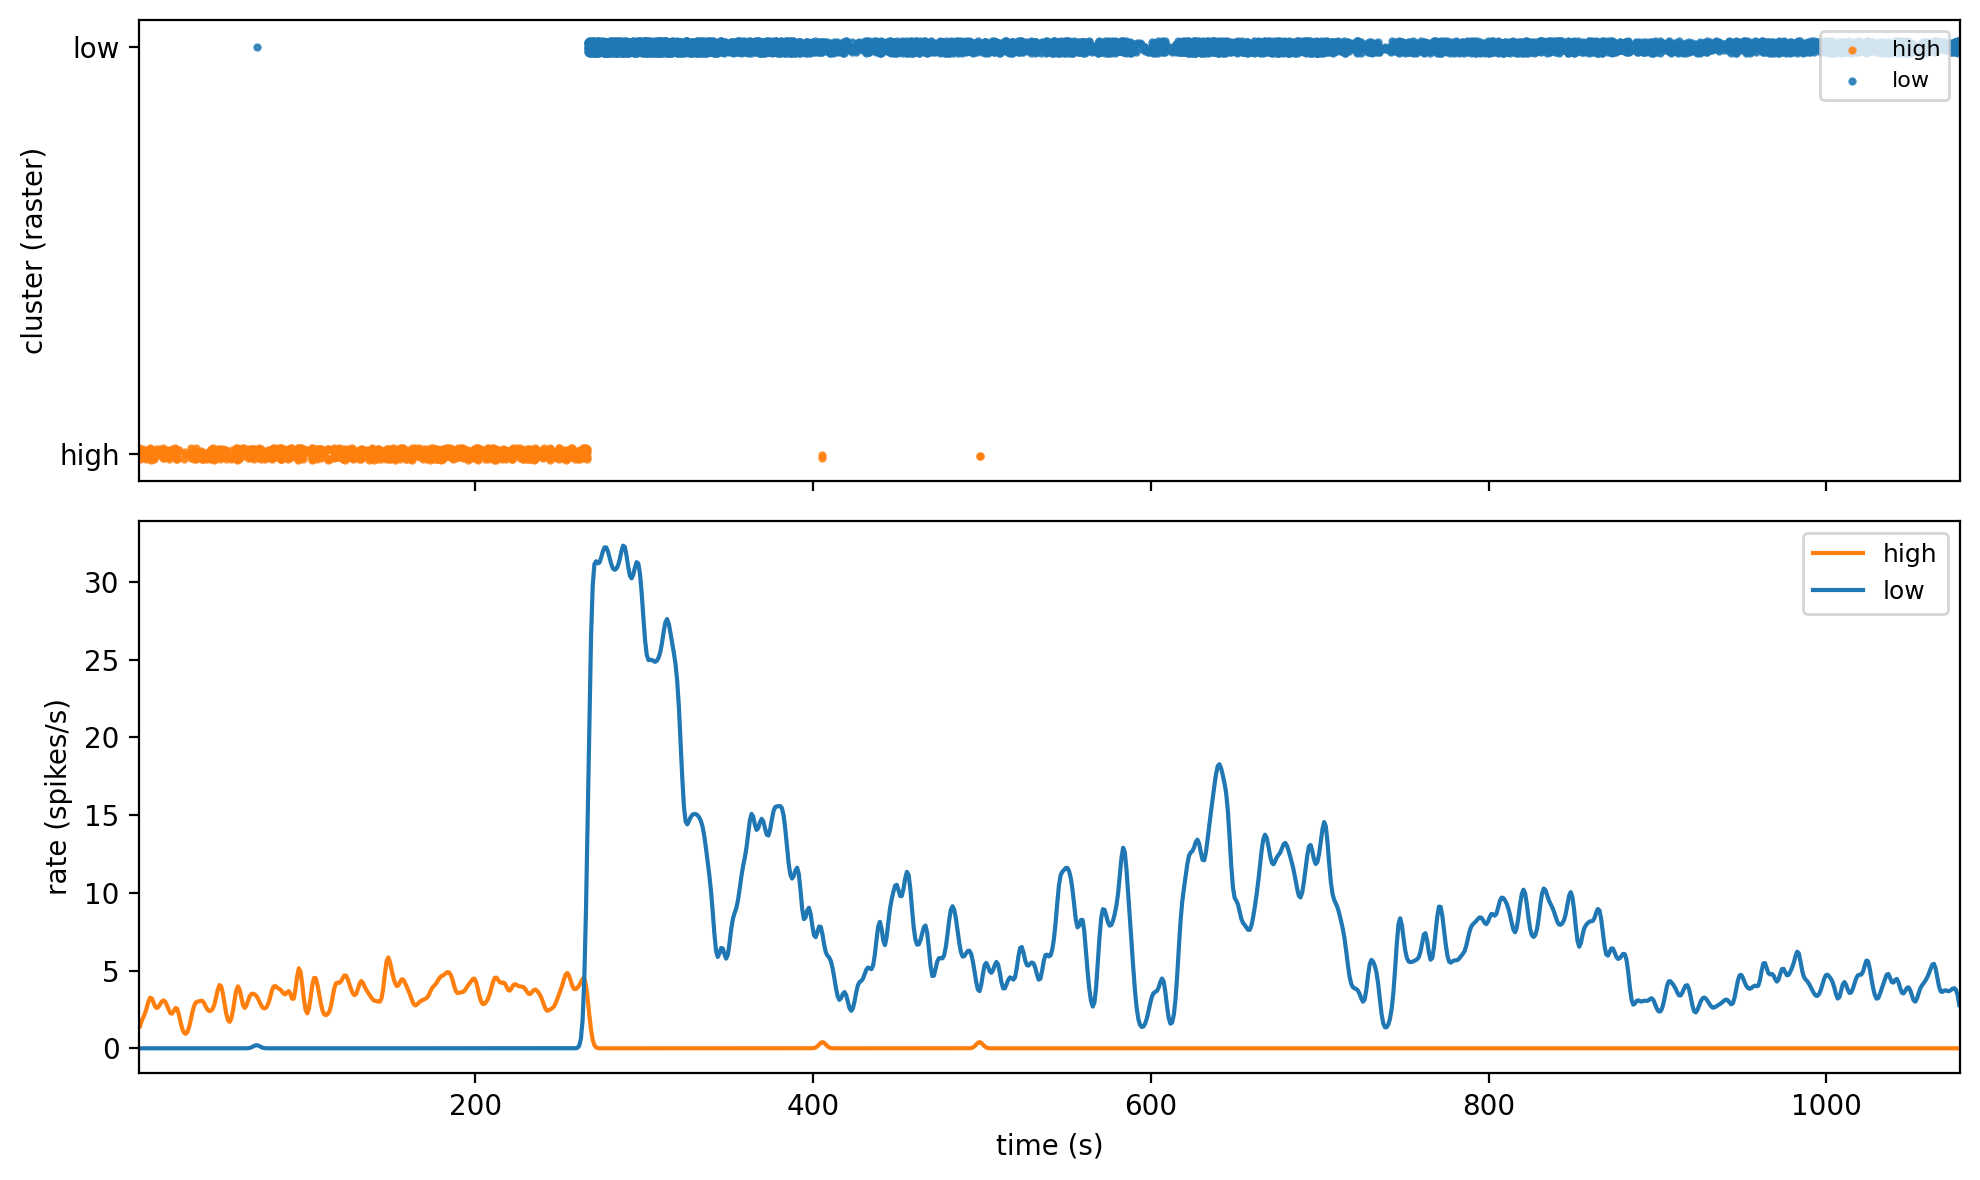

→ Computing cluster transition matrix


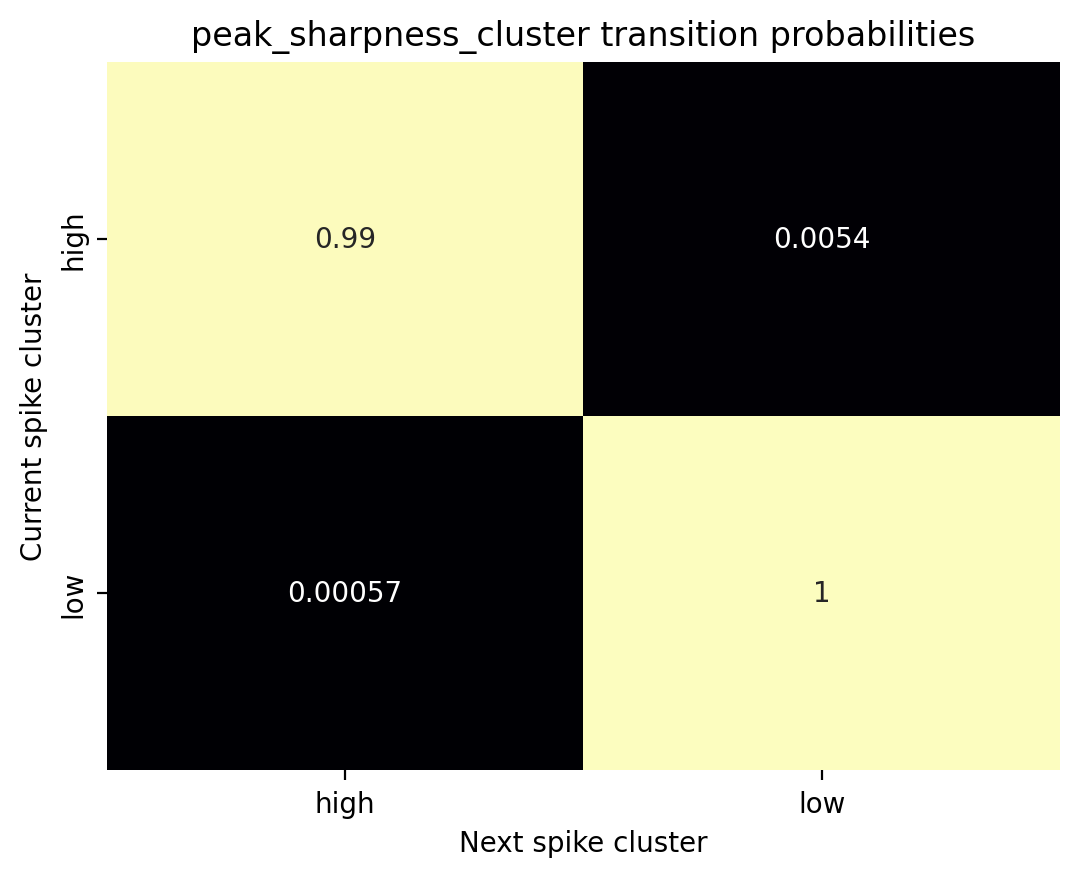

→ Visualizing high vs low feature distributions


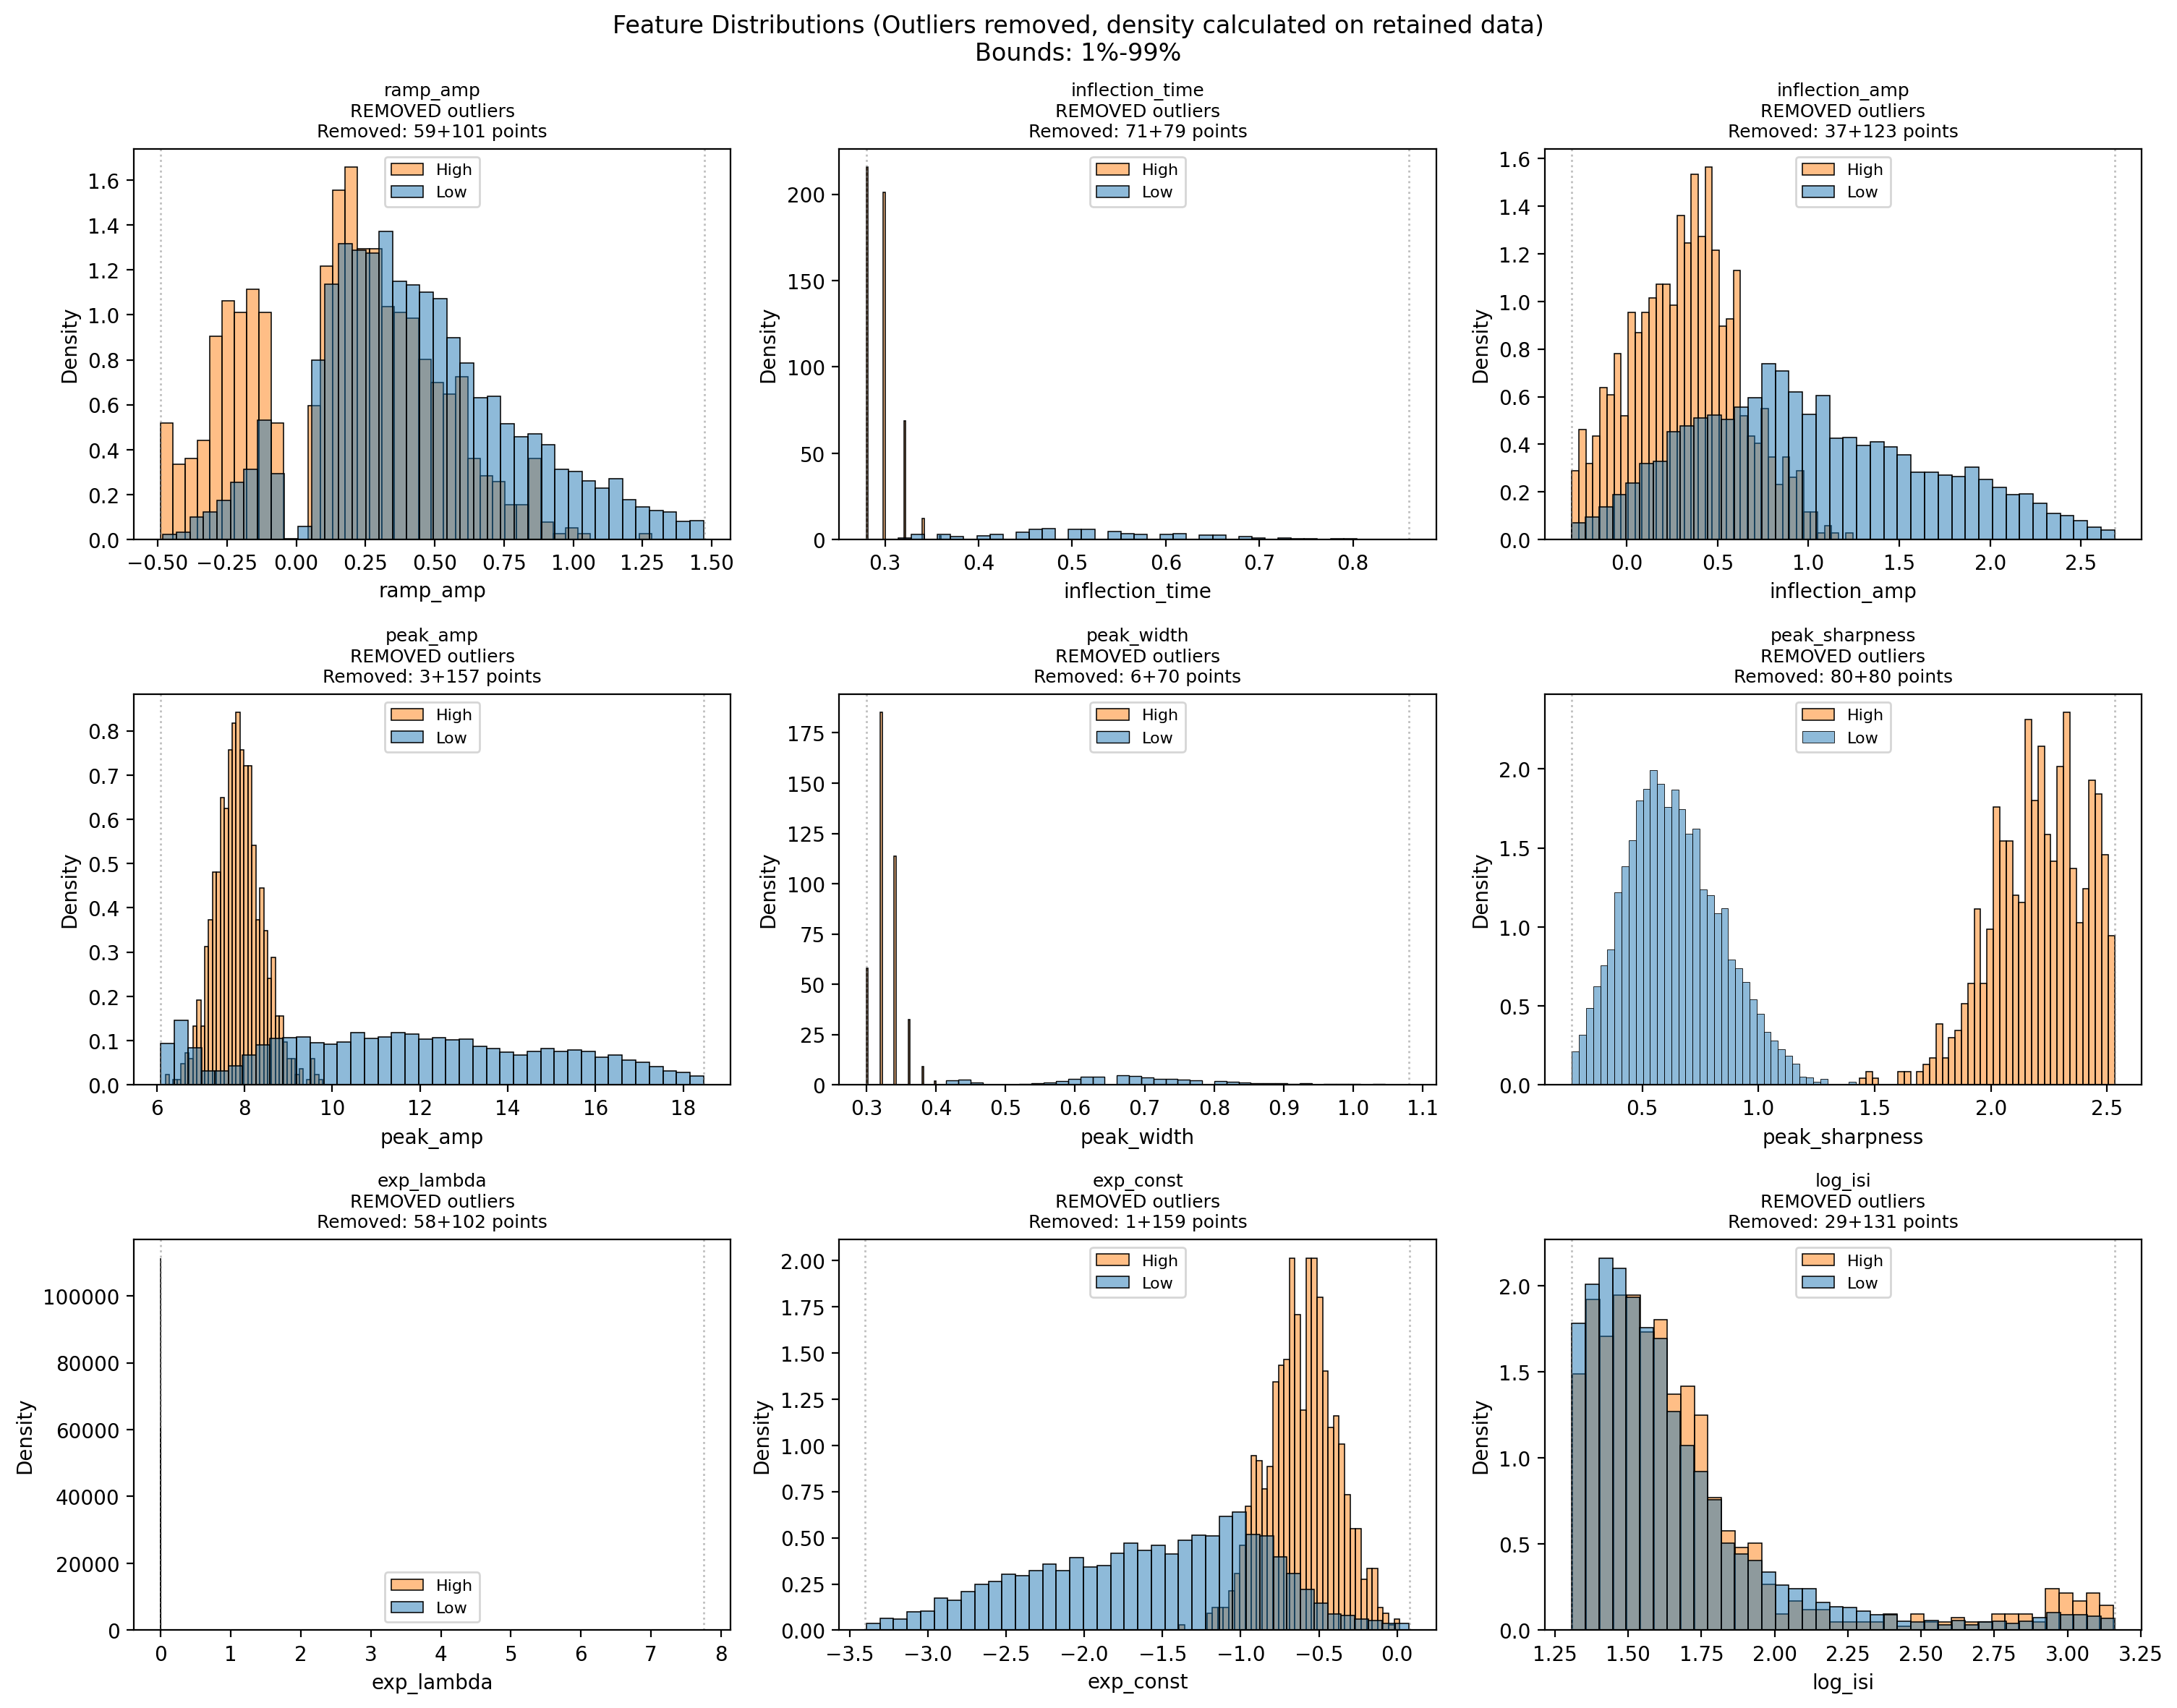

===== DONE =====


===== CLUSTER REPORT: exp_lambda_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


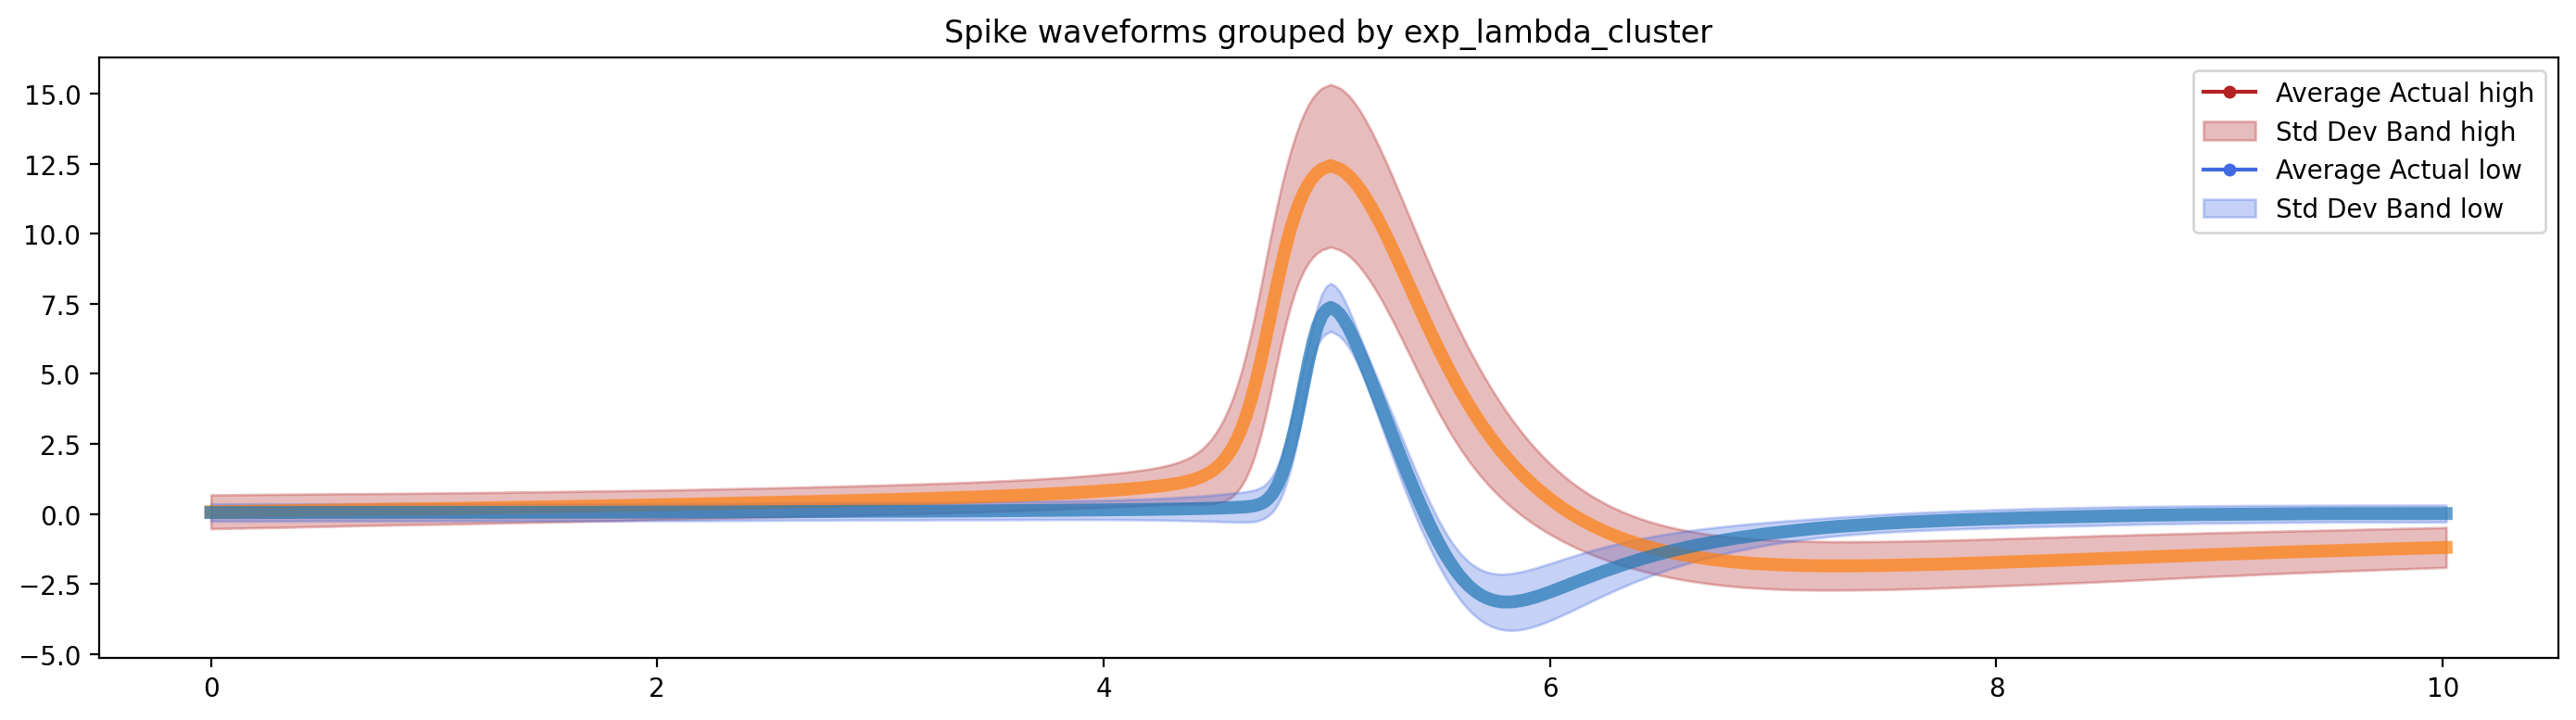

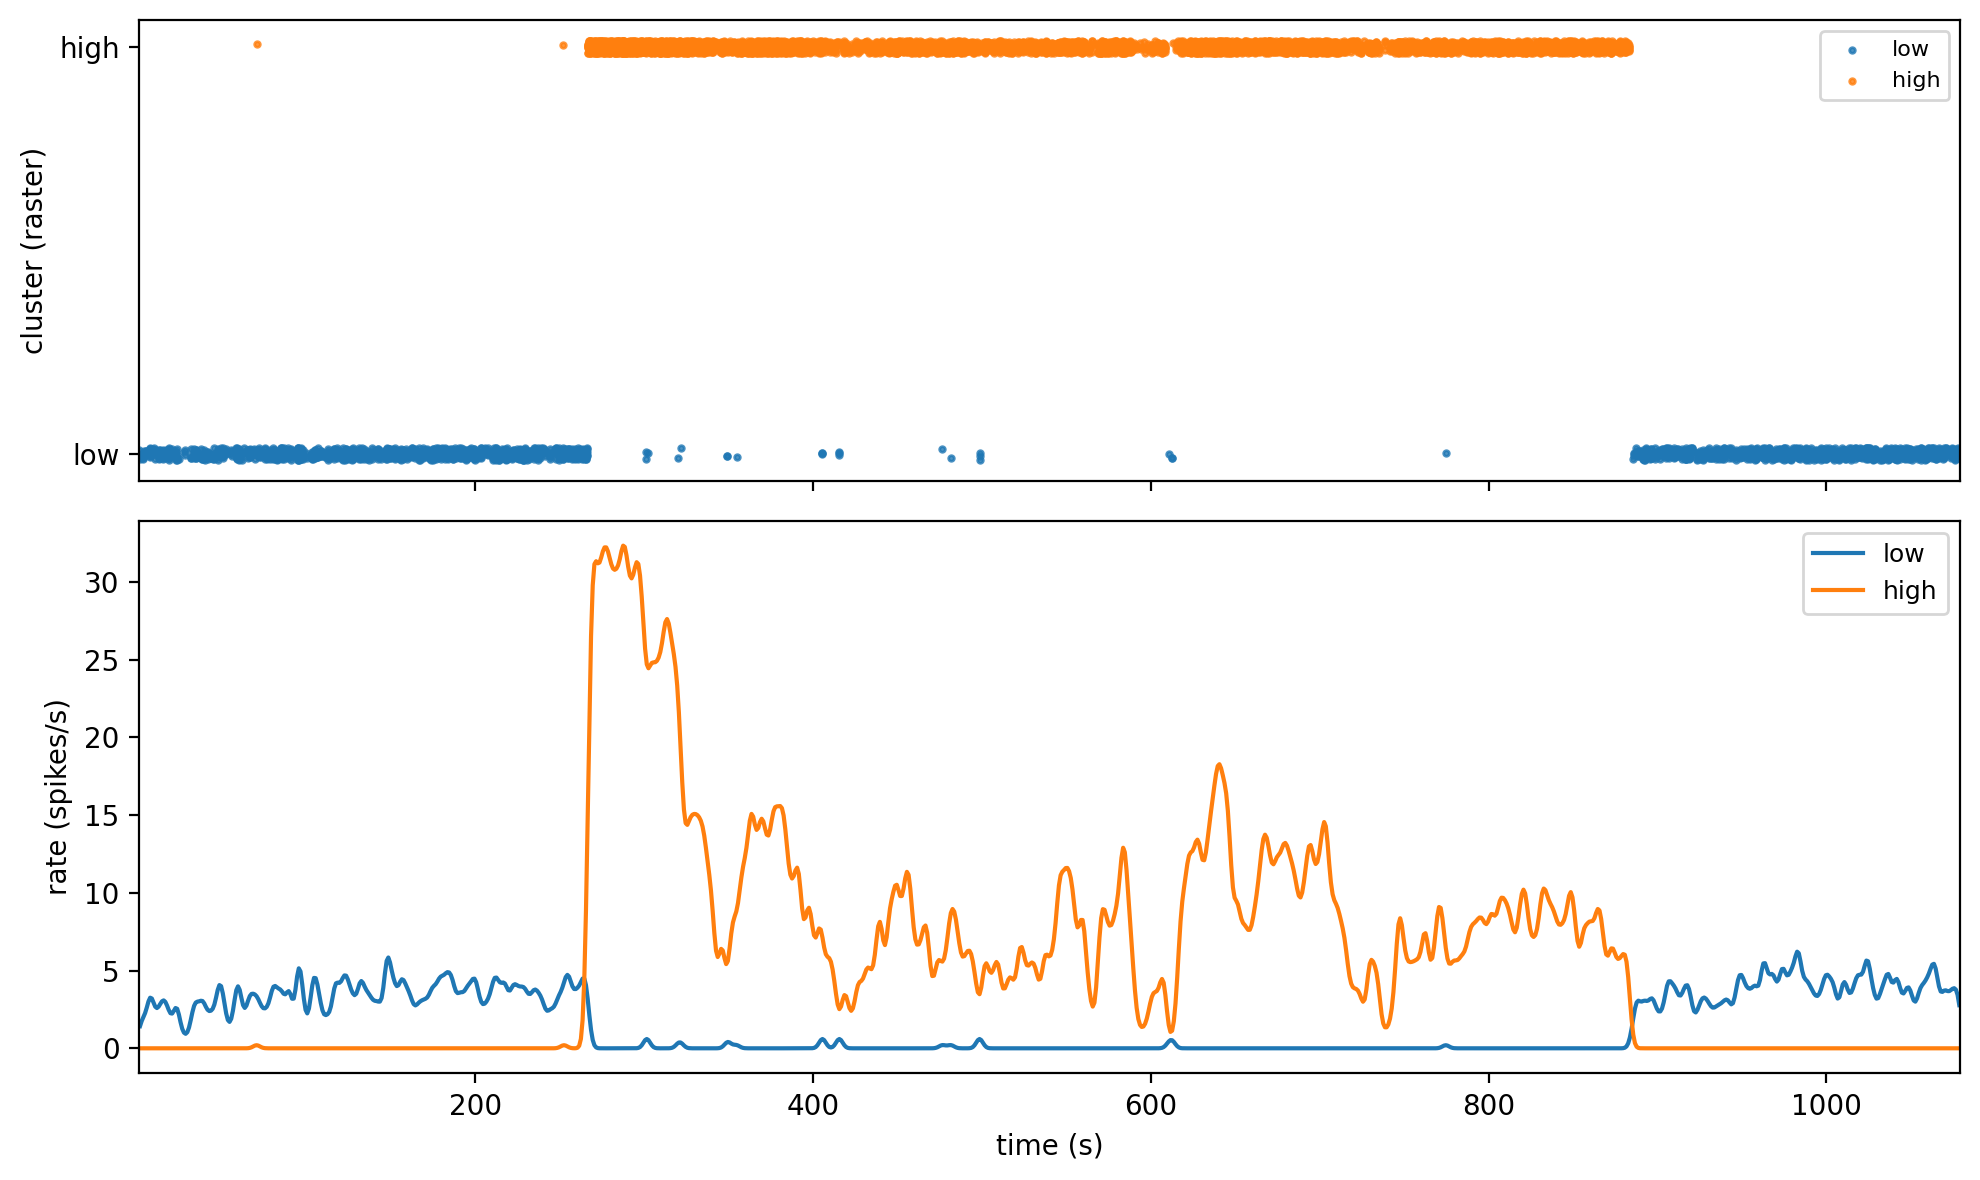

→ Computing cluster transition matrix


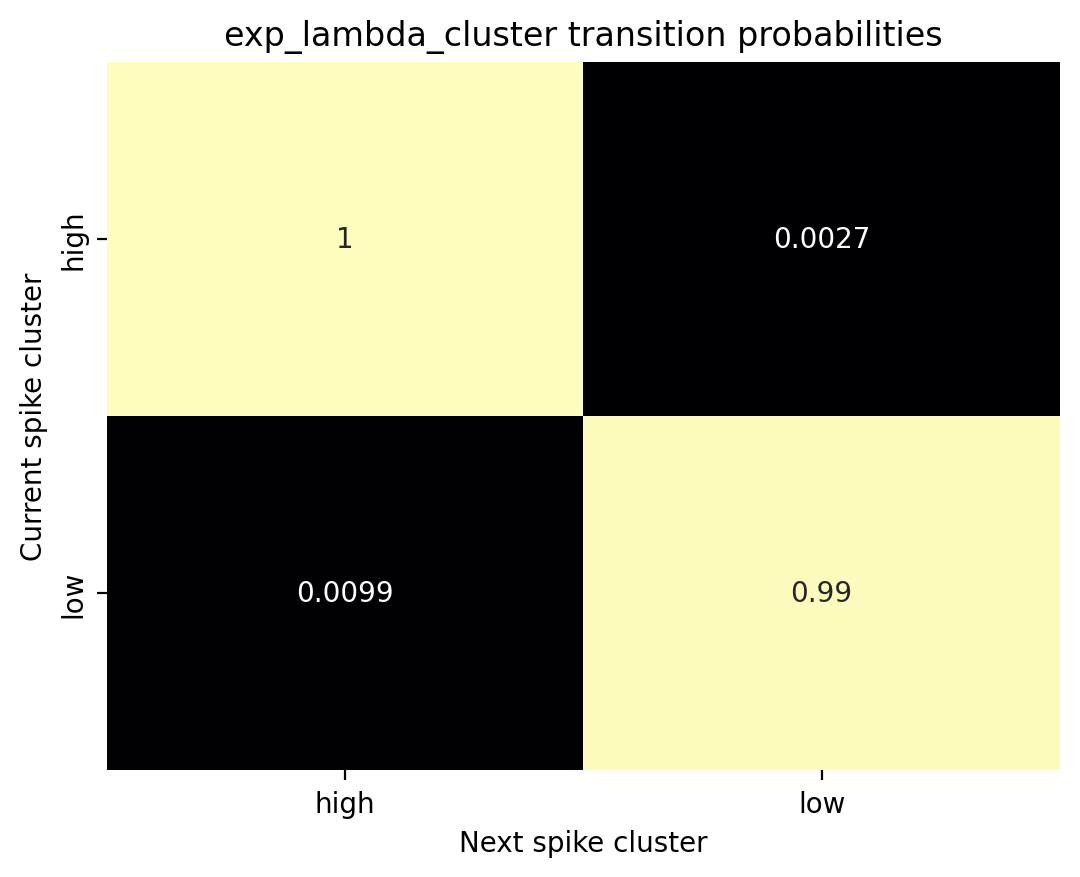

→ Visualizing high vs low feature distributions


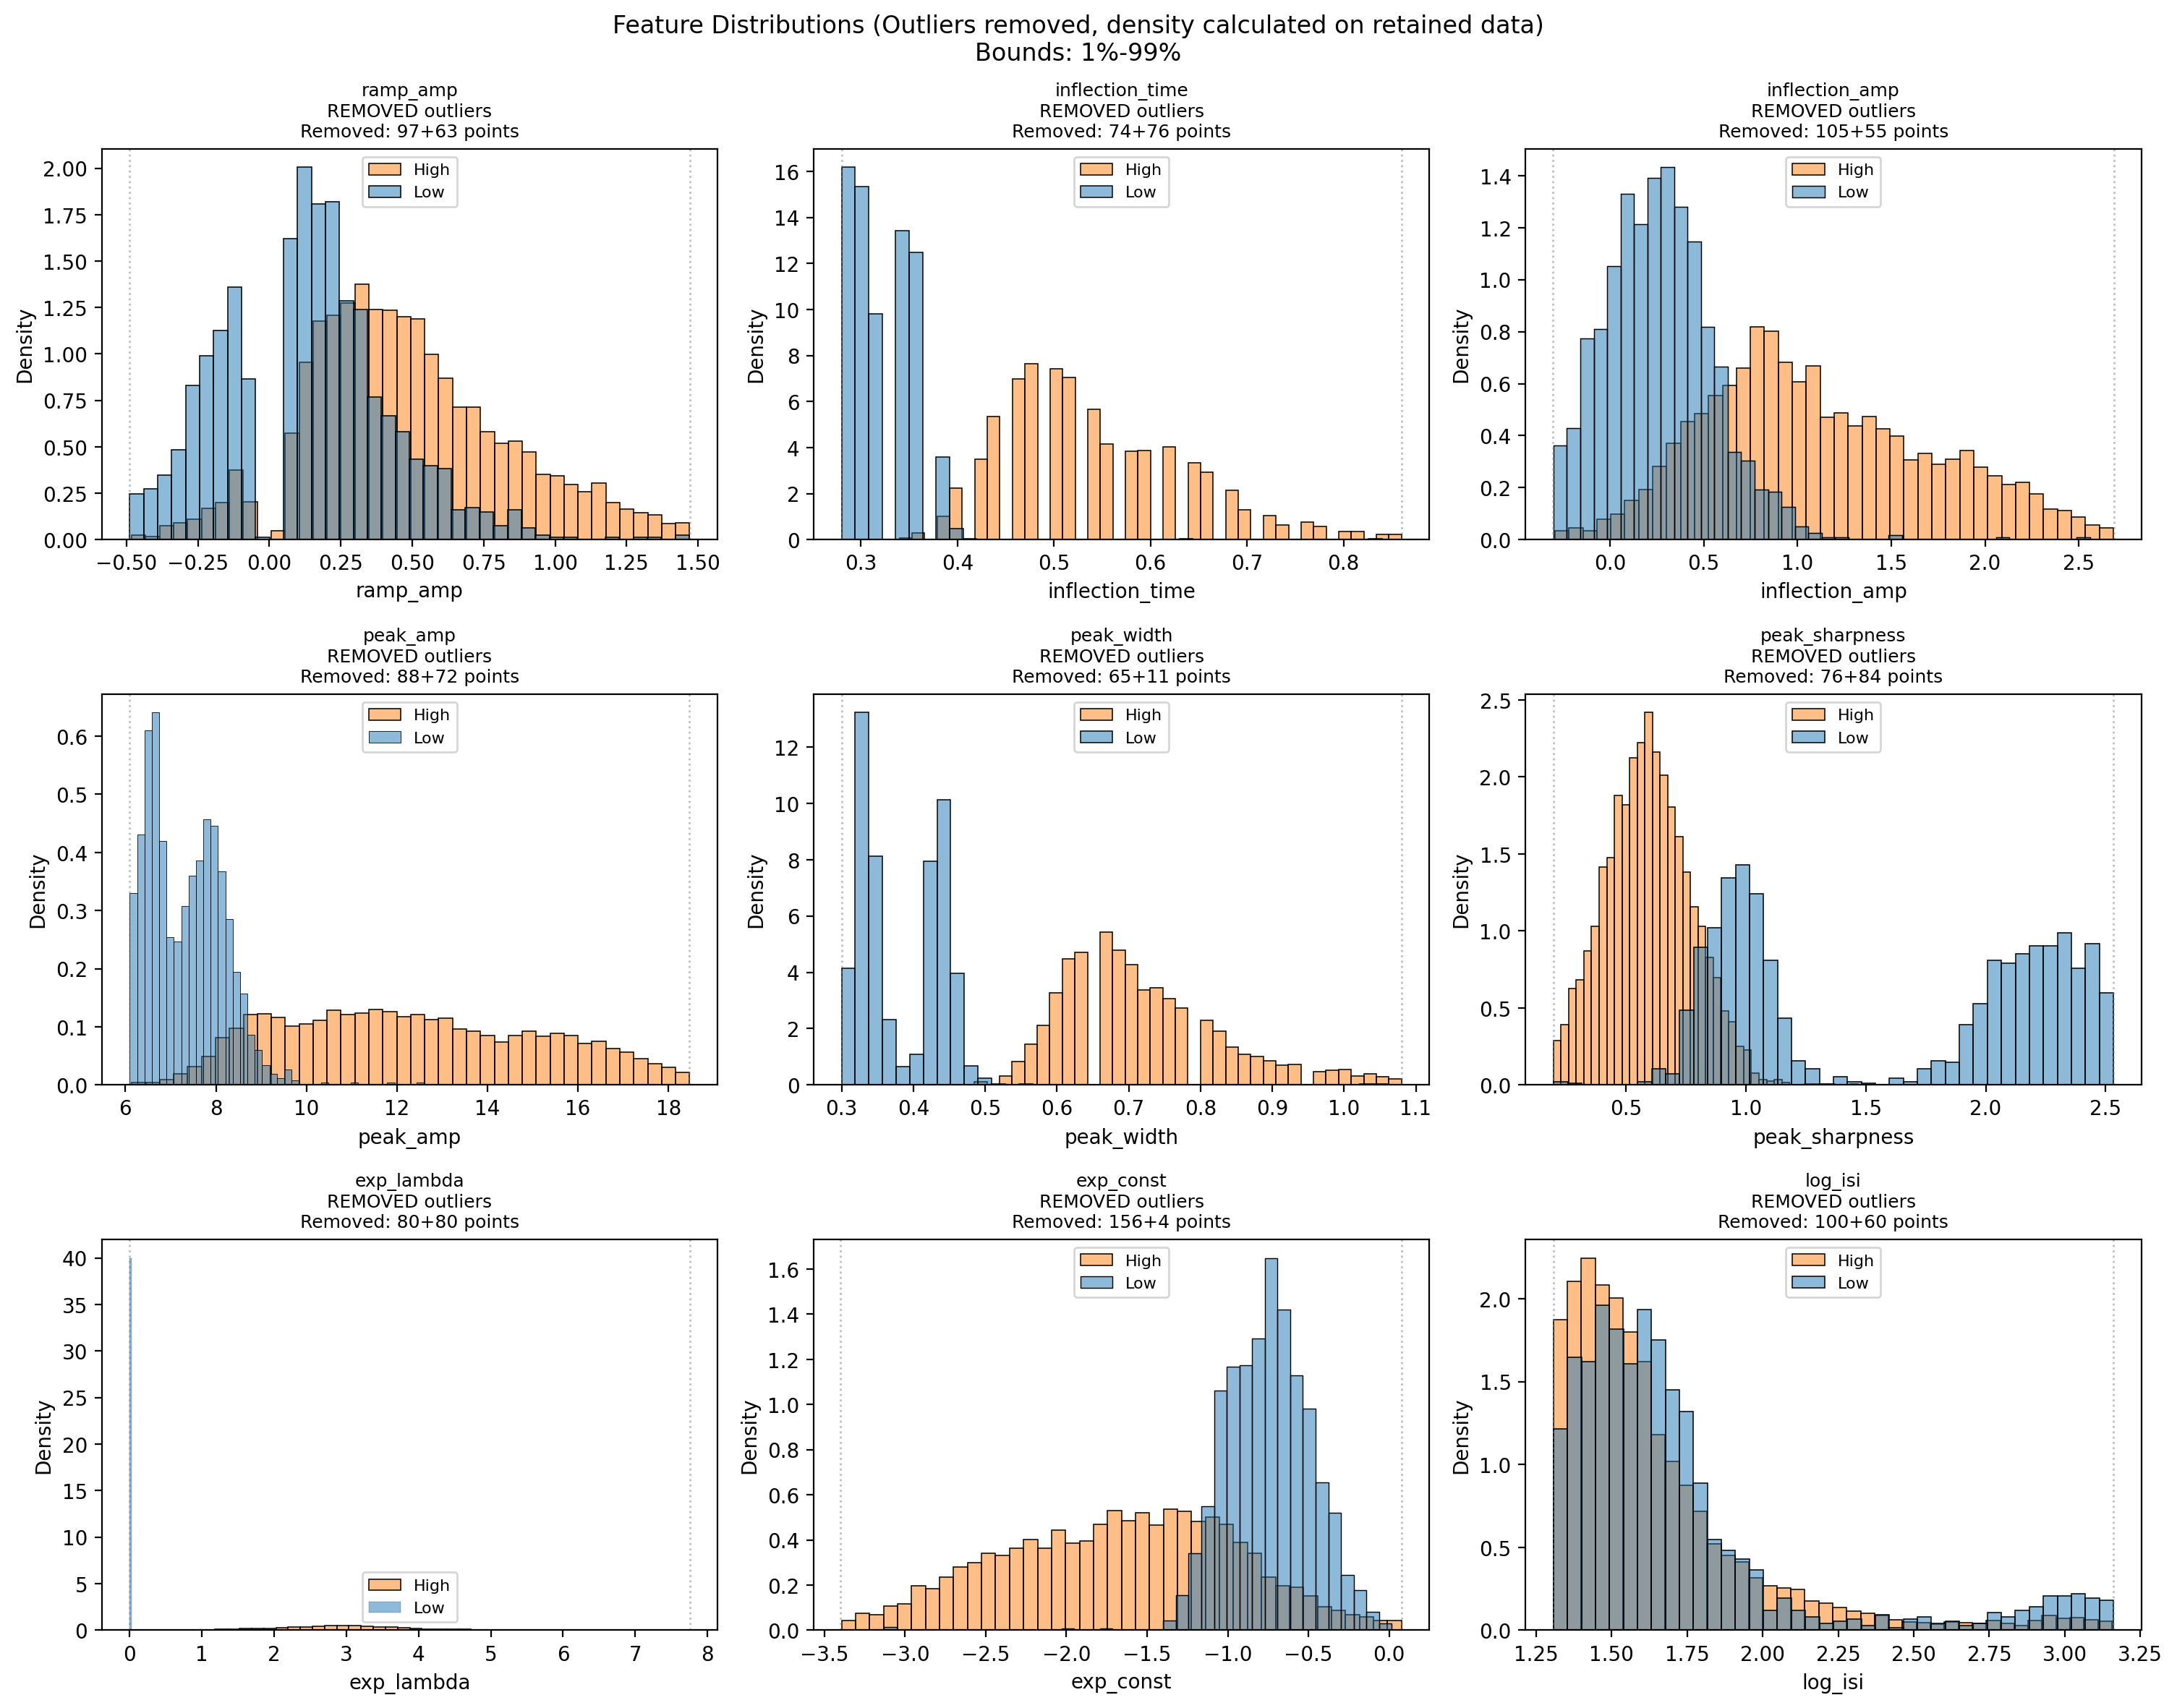

===== DONE =====


===== CLUSTER REPORT: spk_times_idx_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


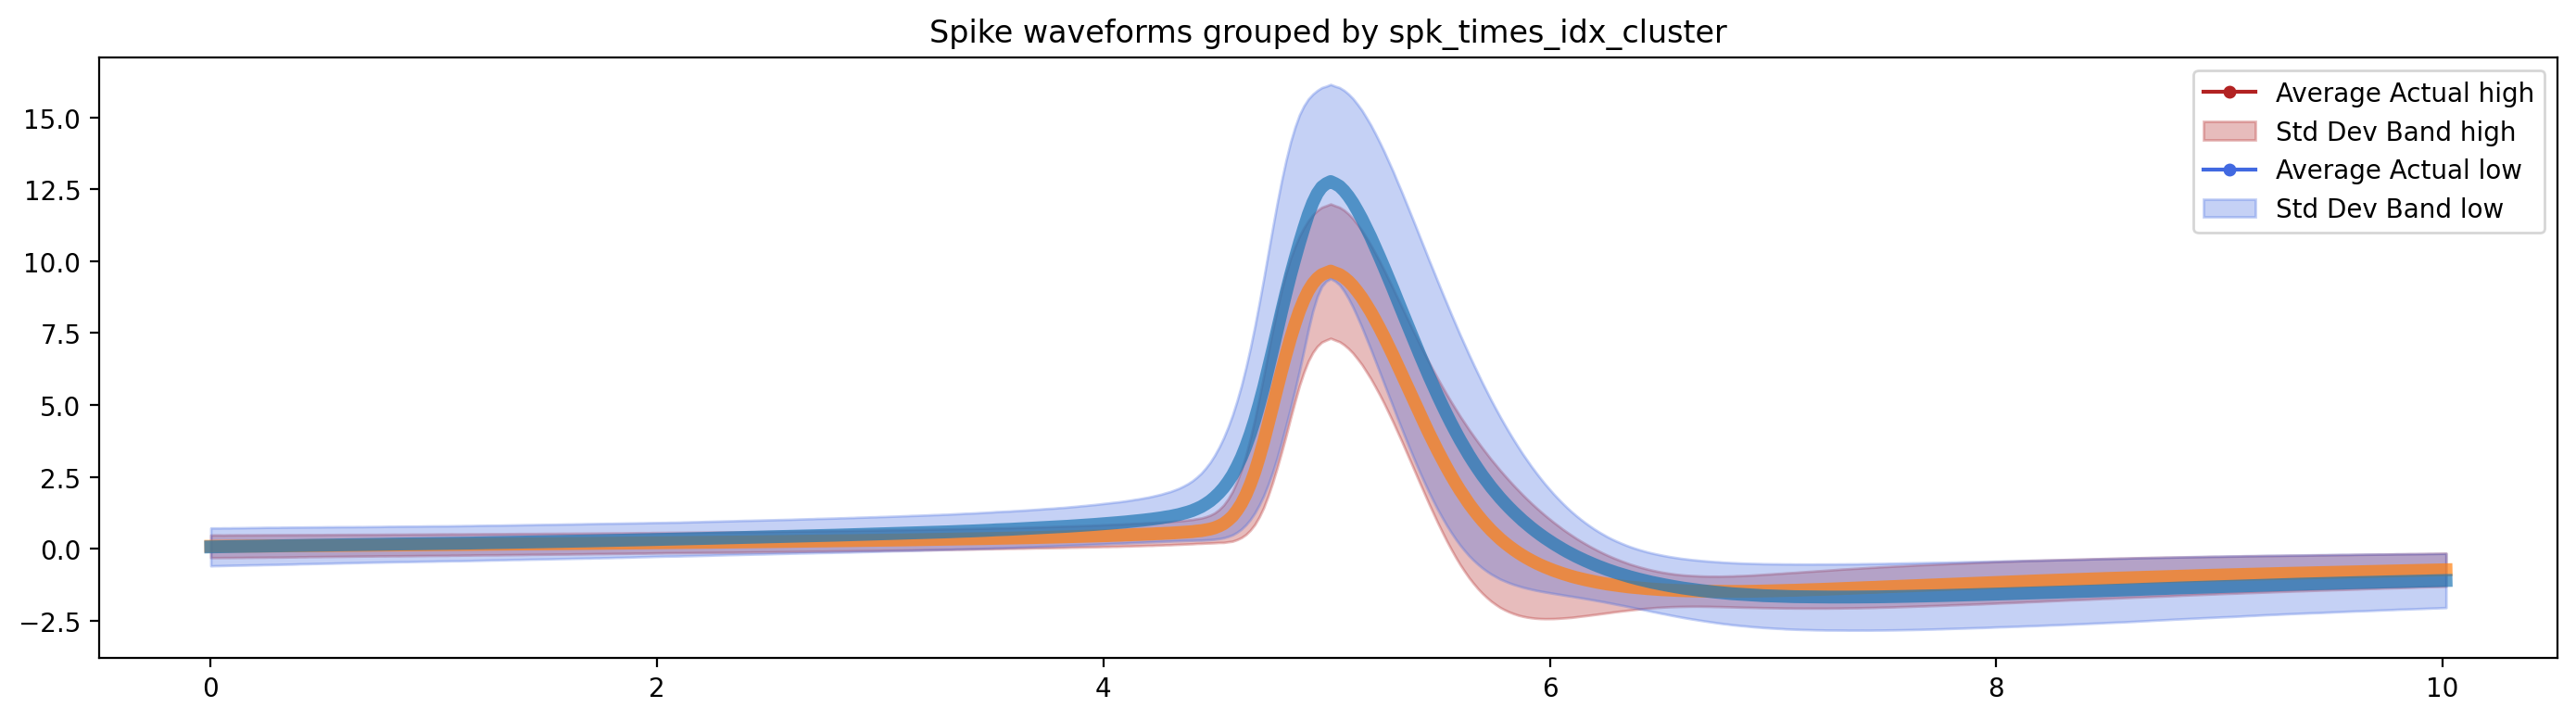

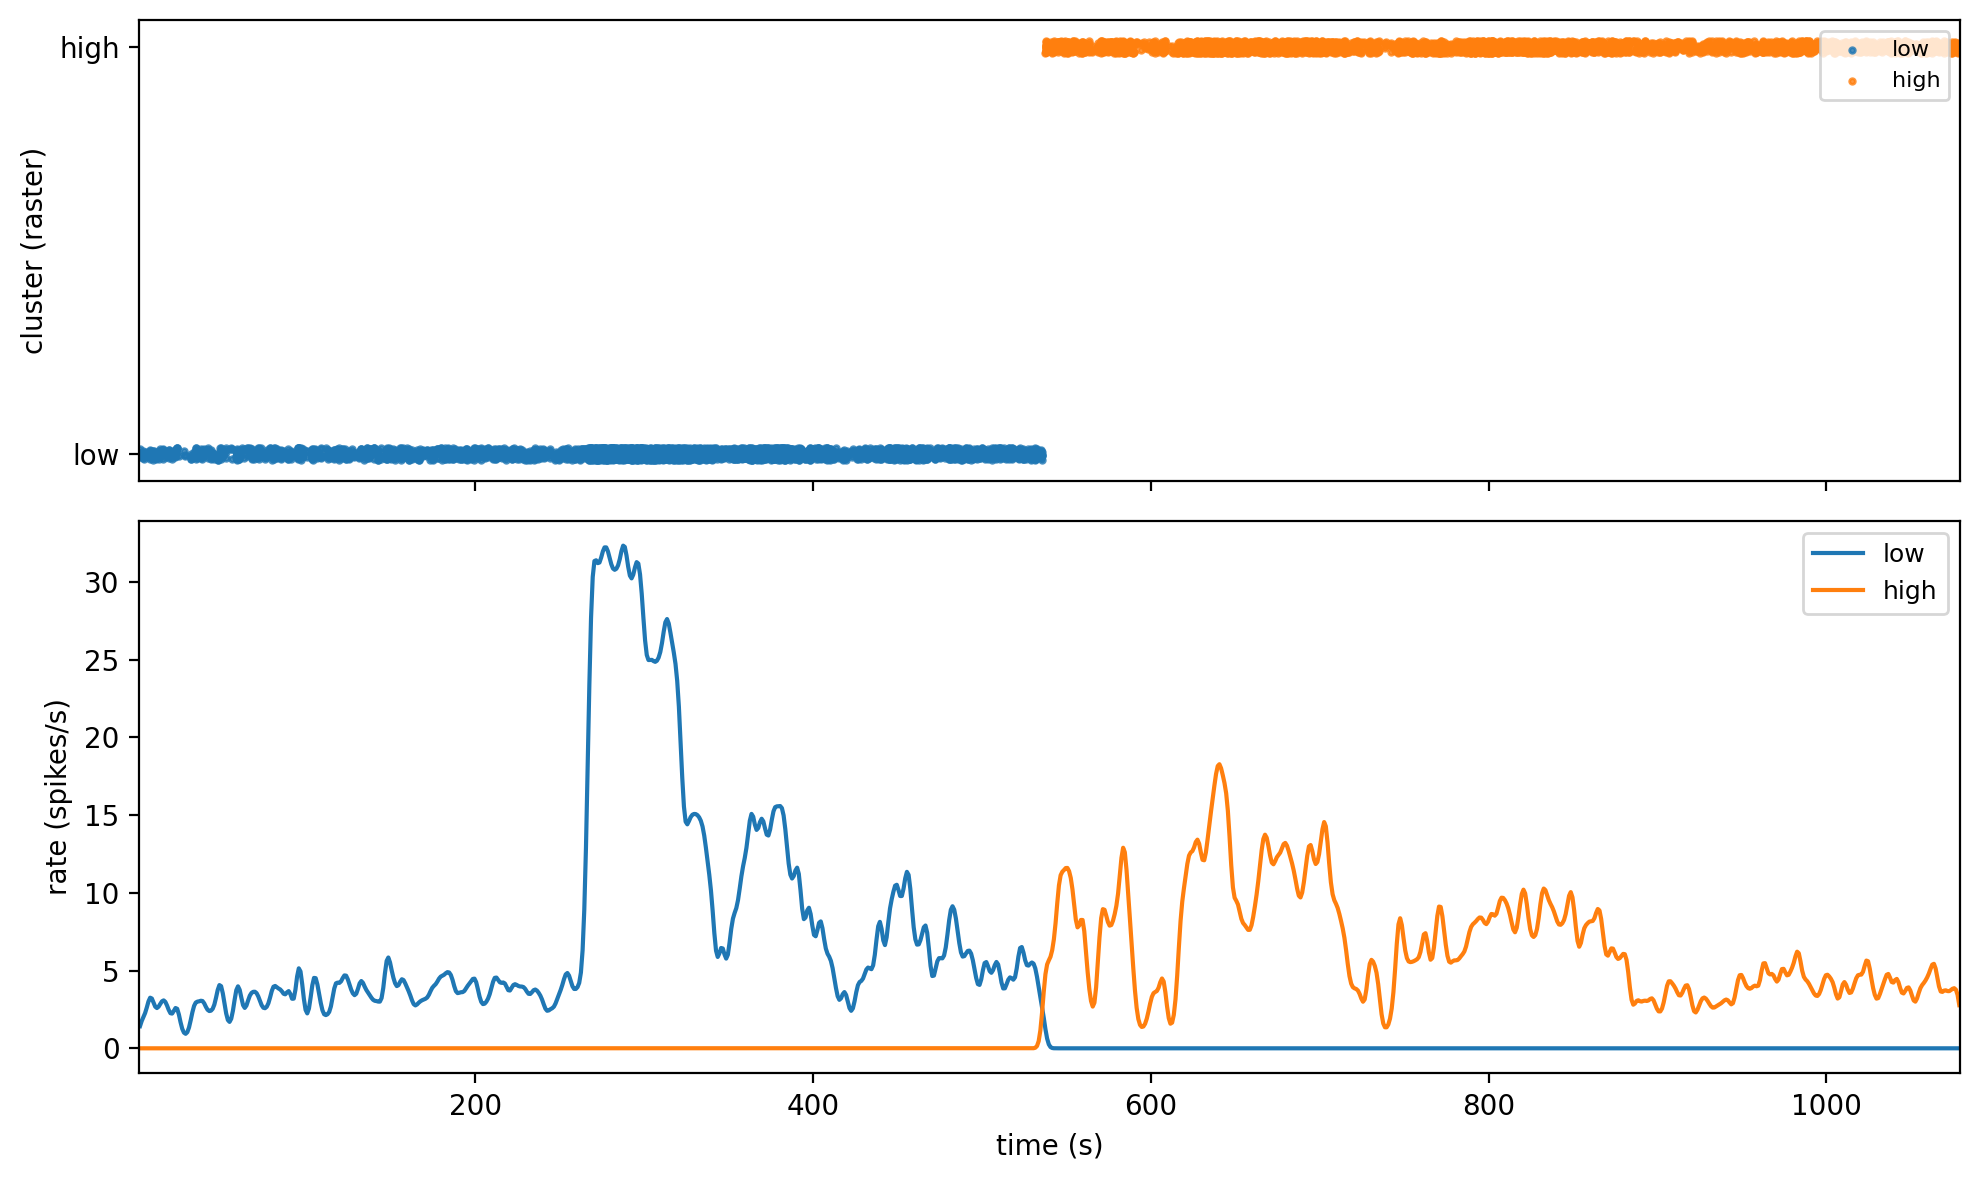

→ Computing cluster transition matrix


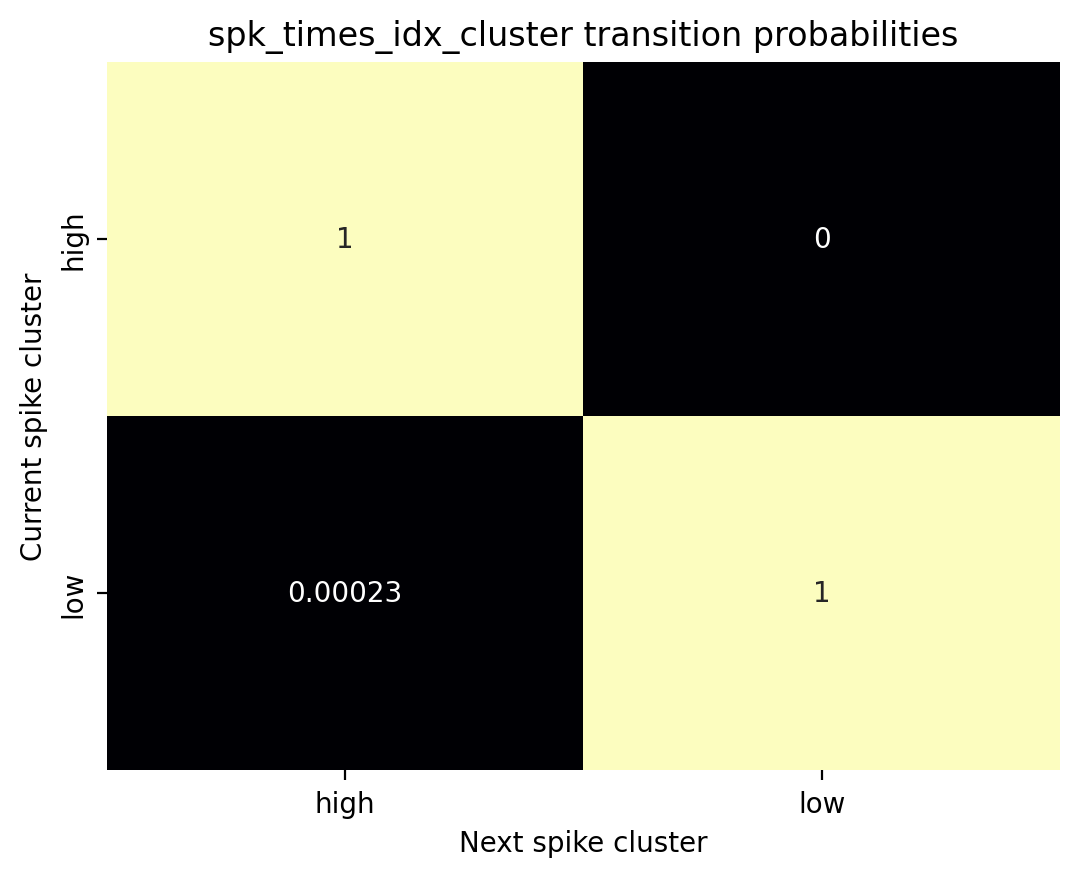

→ Visualizing high vs low feature distributions


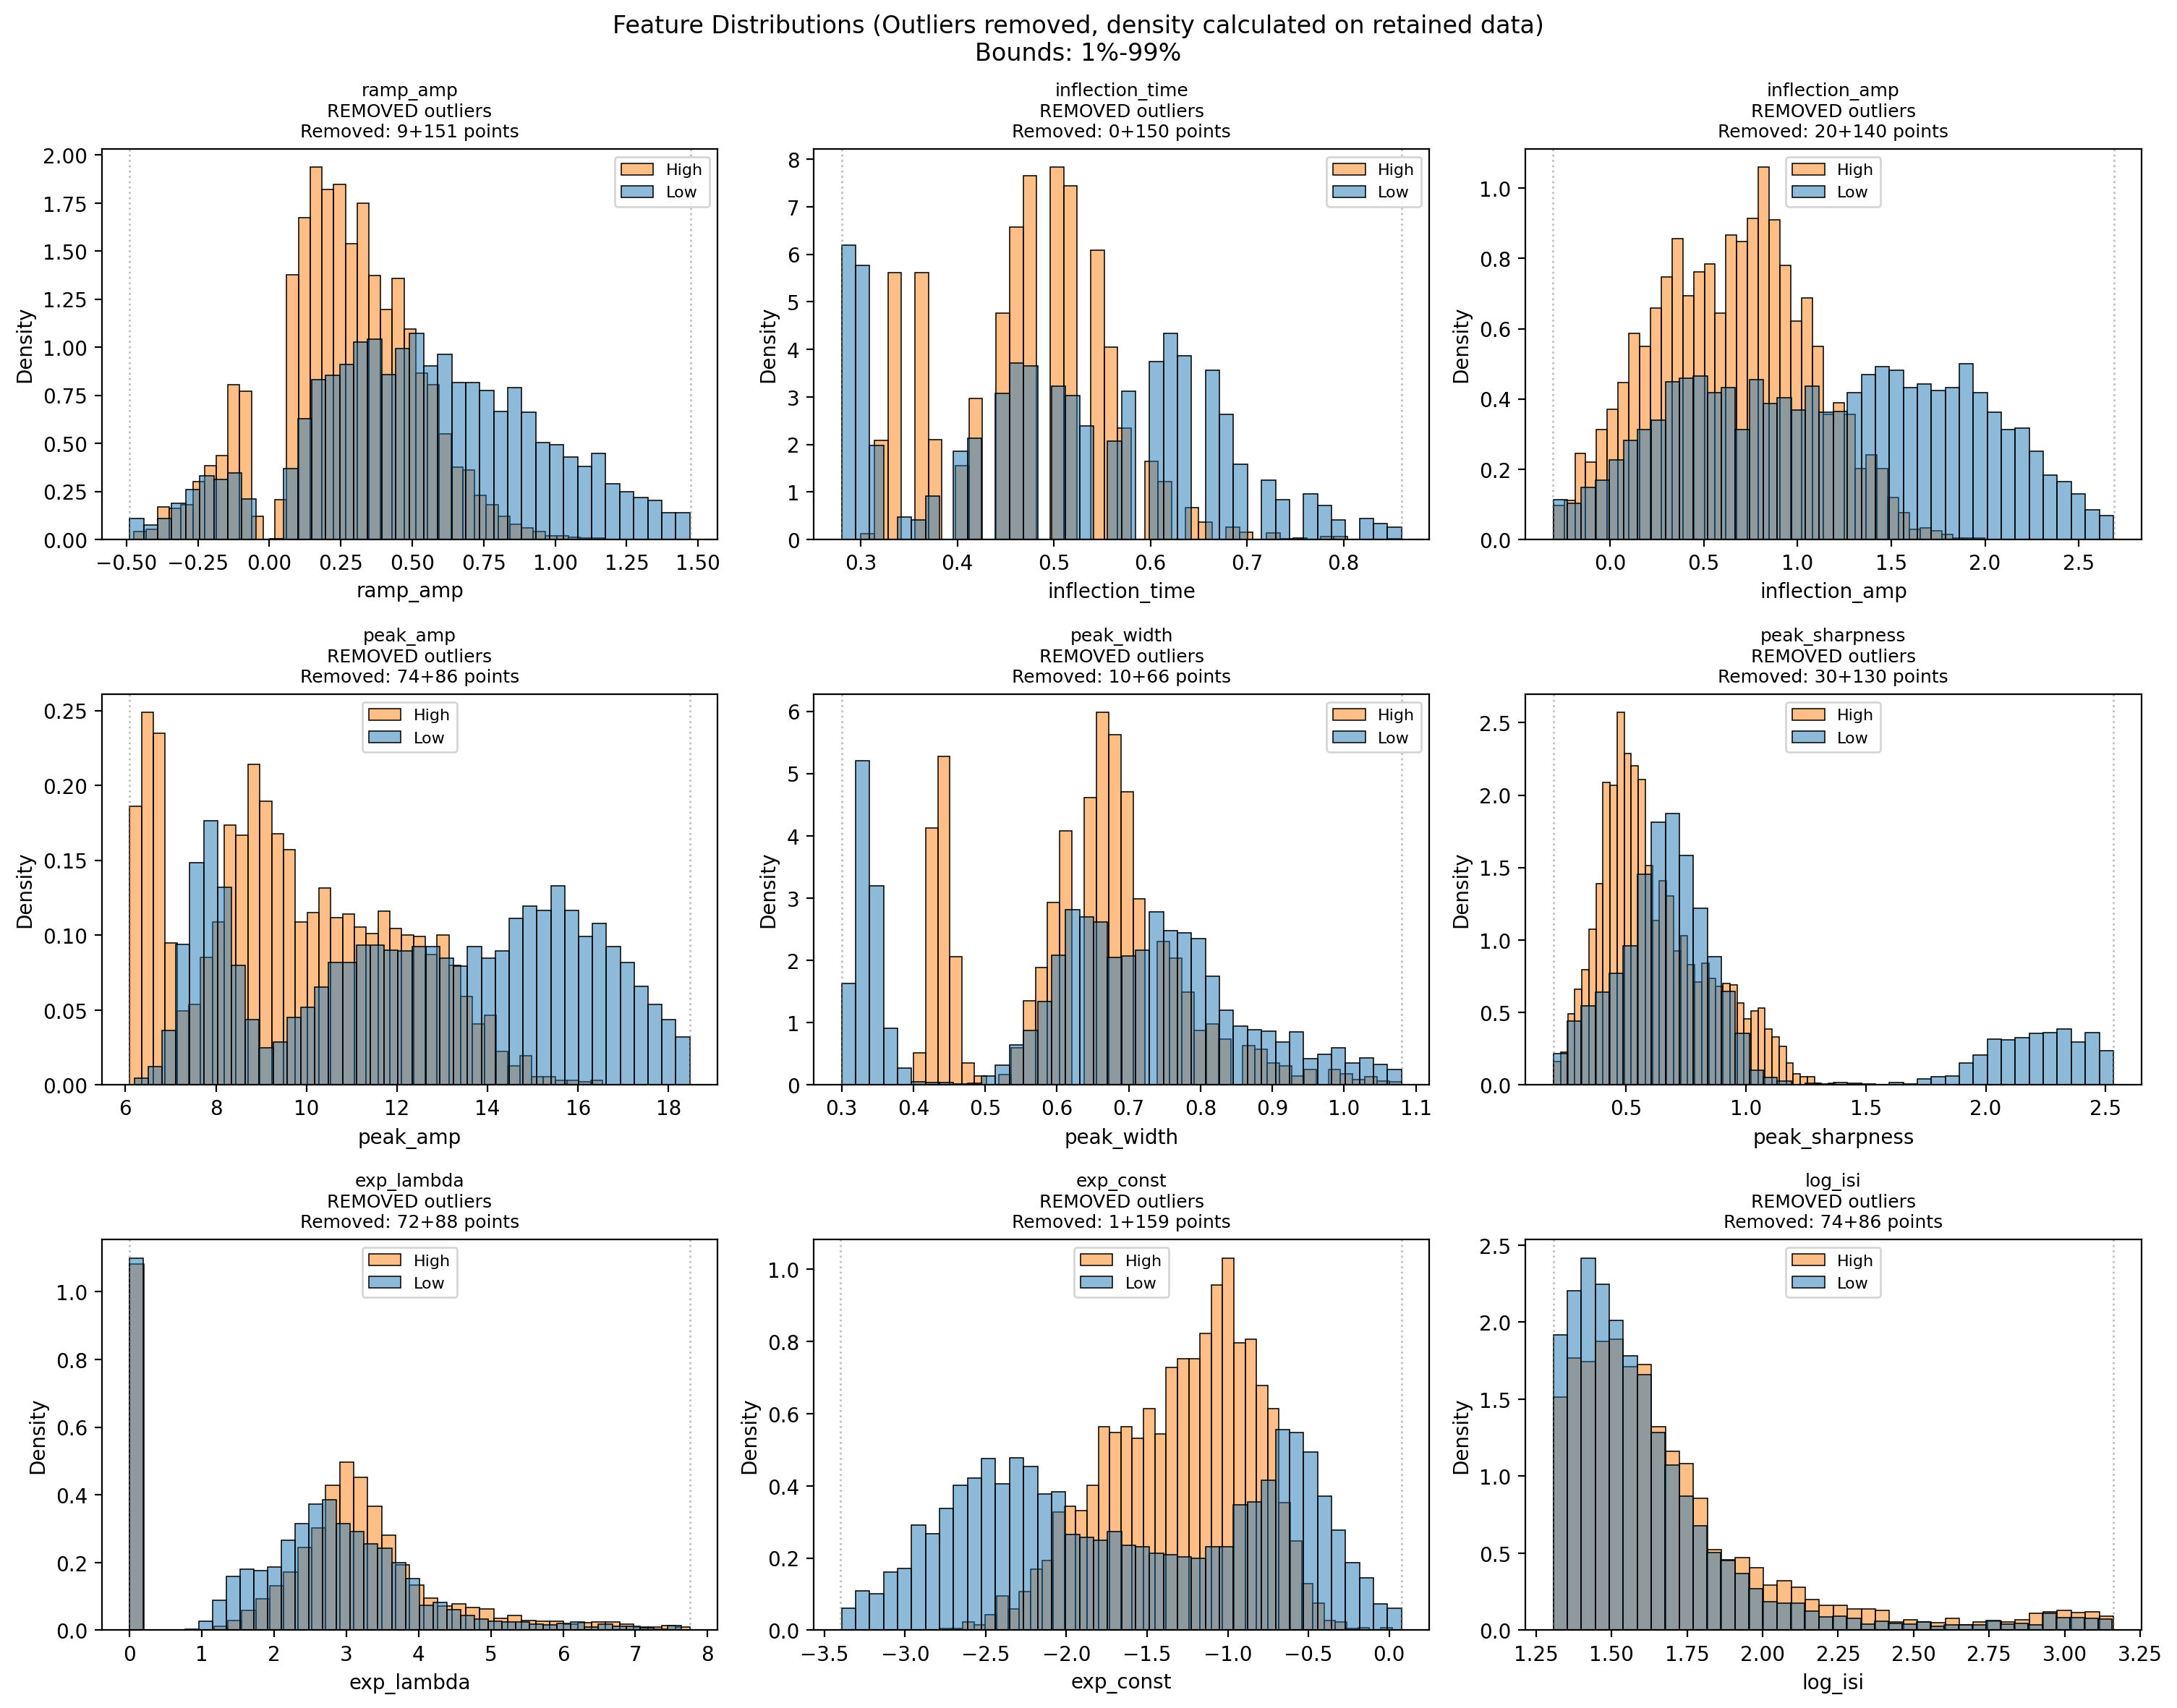

===== DONE =====


===== CLUSTER REPORT: spk_times_ms_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


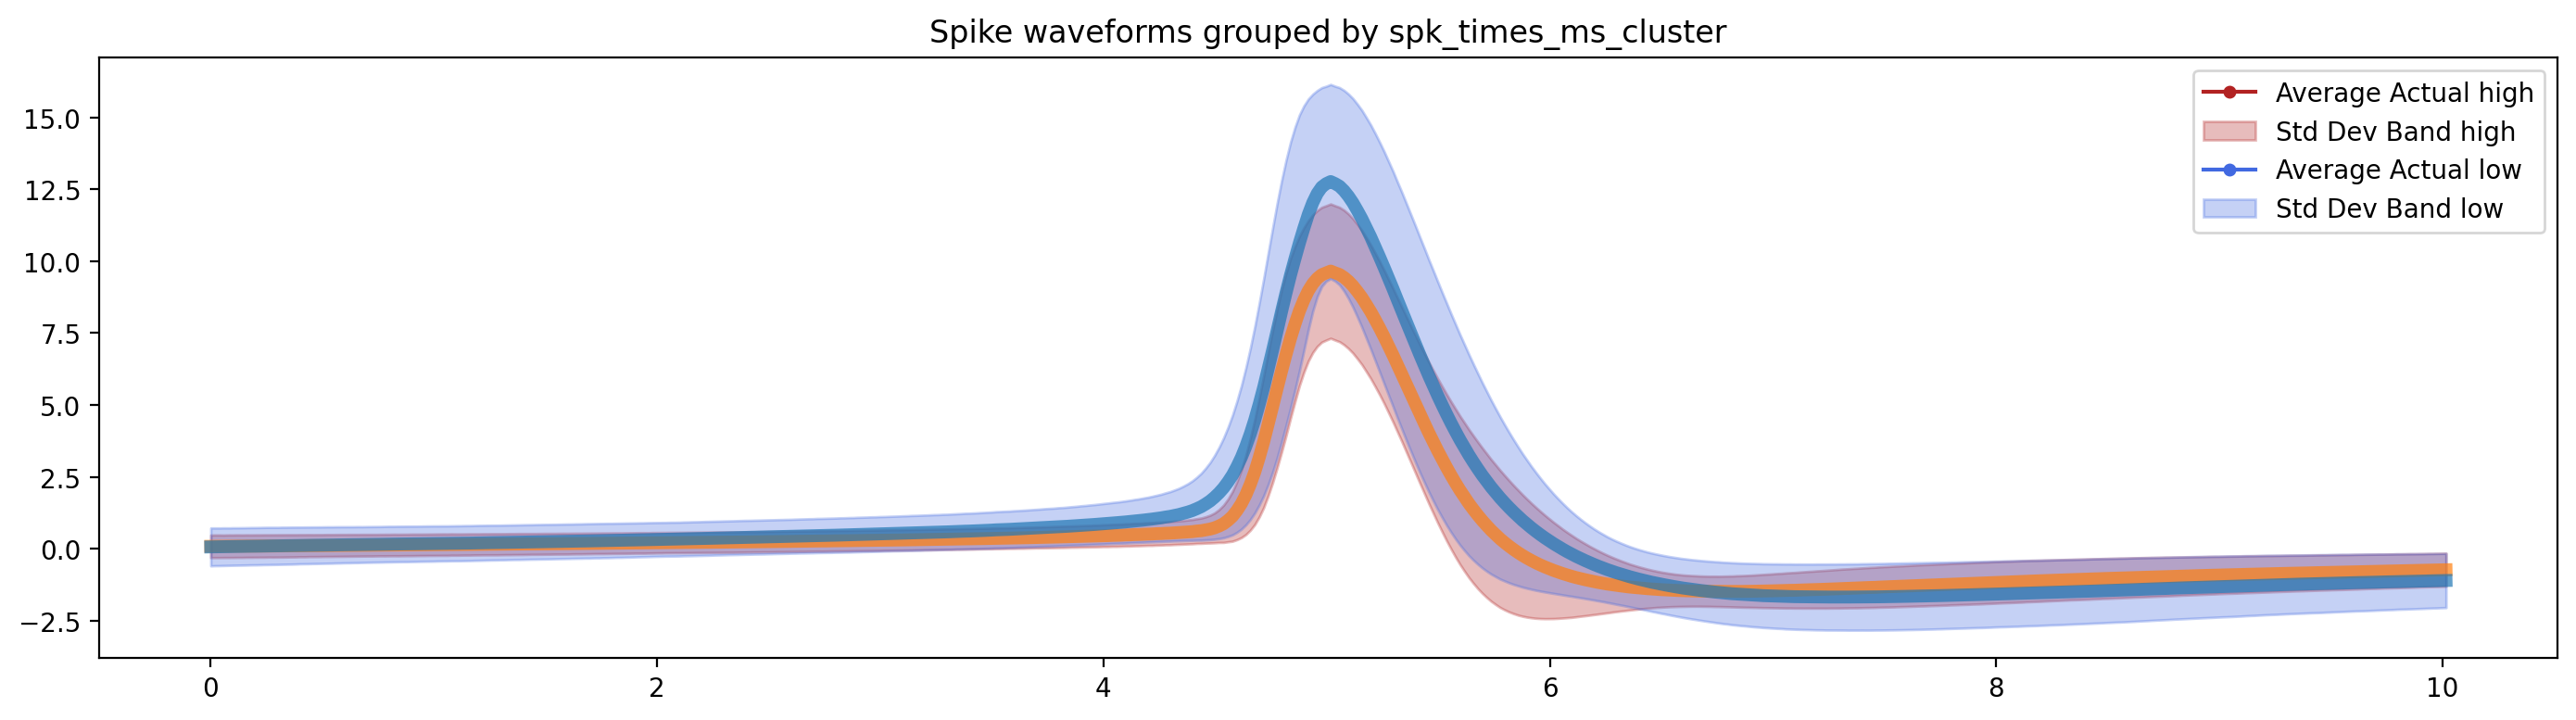

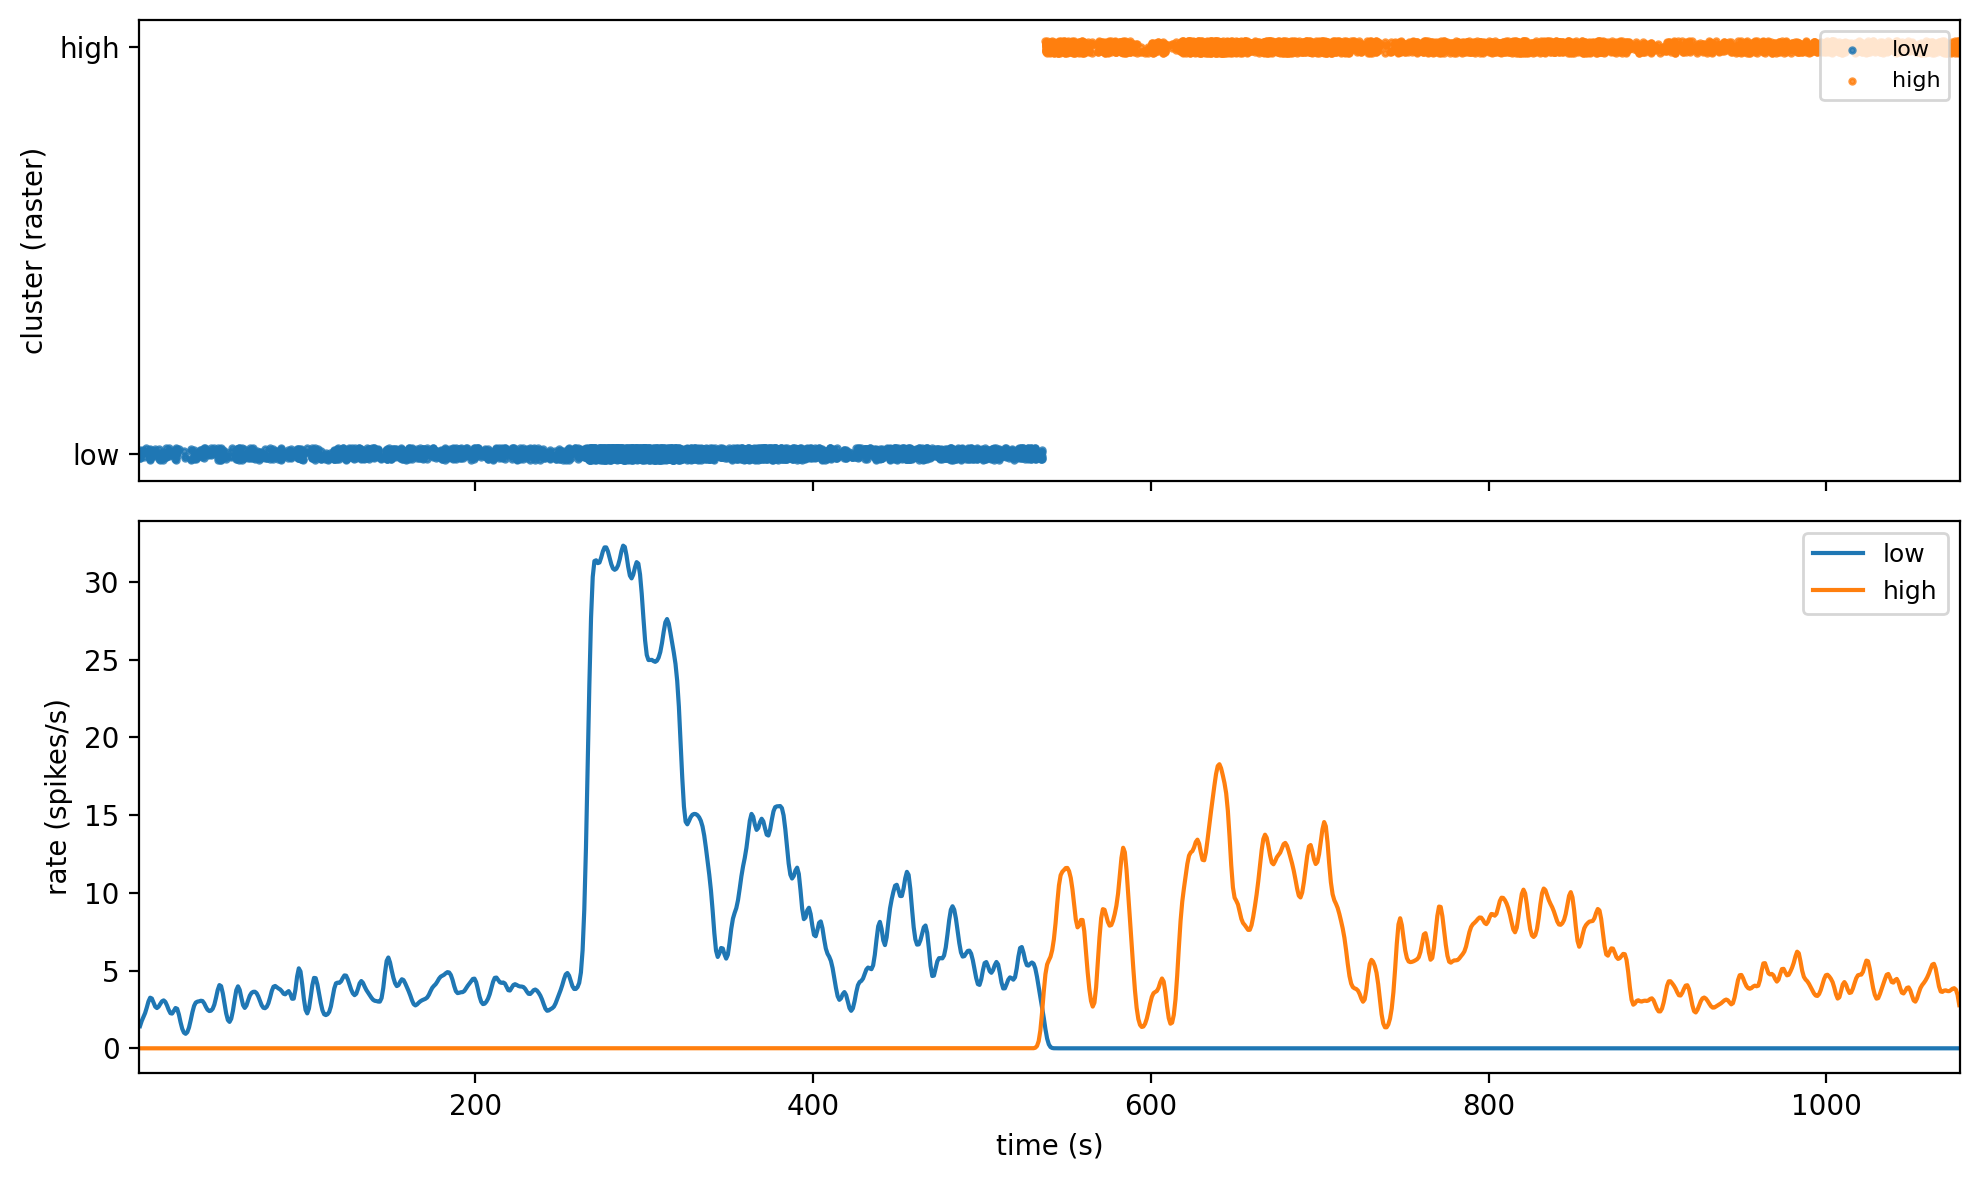

→ Computing cluster transition matrix


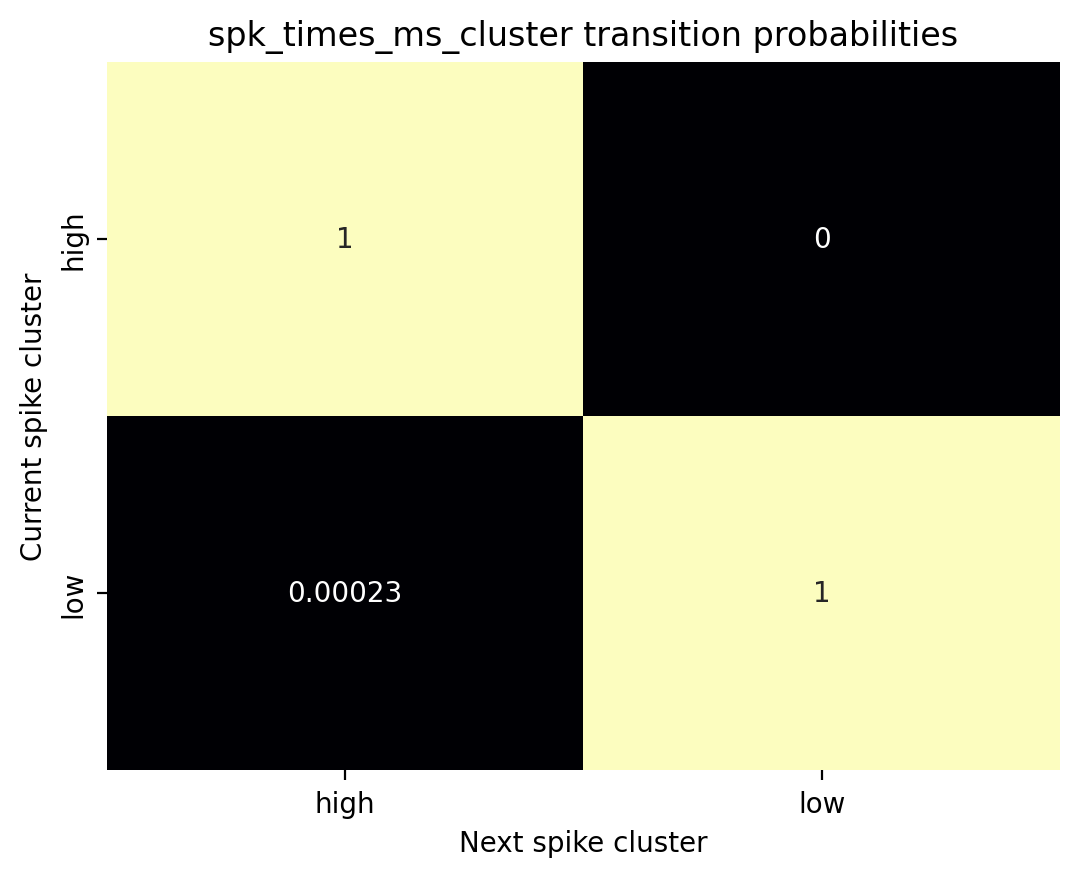

→ Visualizing high vs low feature distributions


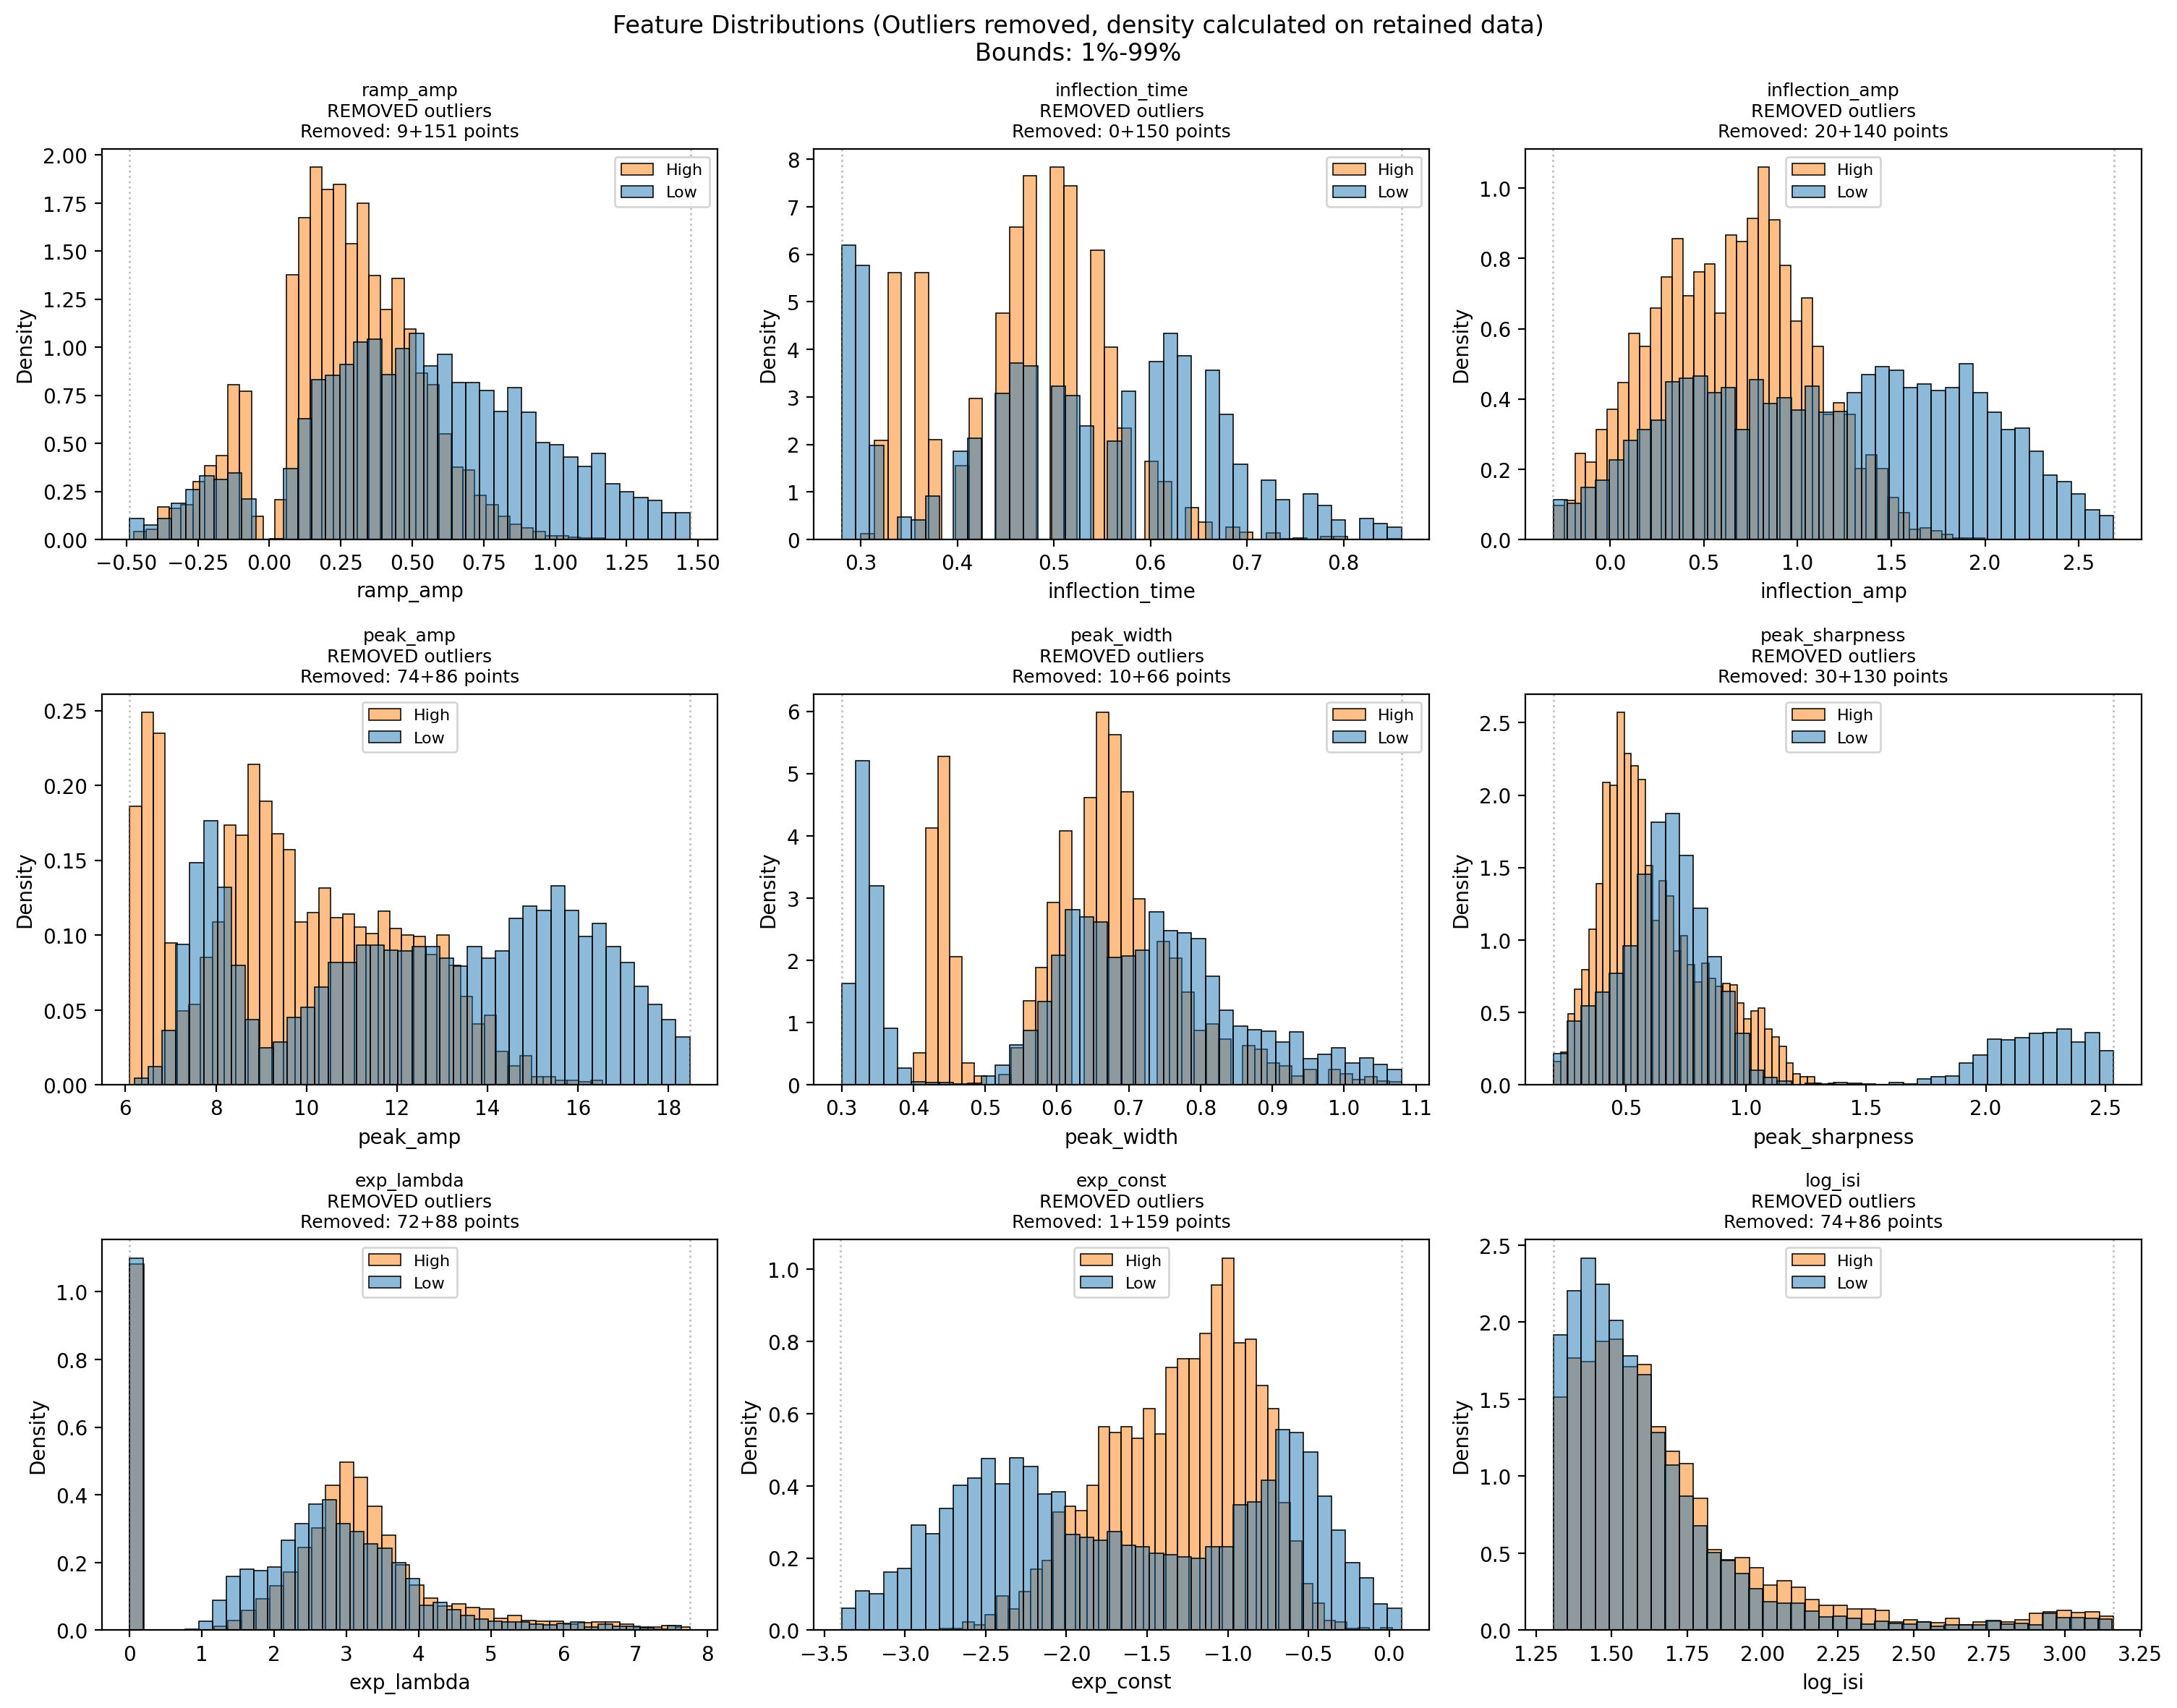

===== DONE =====



In [18]:
for col in df_features_clust.columns:
    if col.endswith("_cluster"):
        plot_full_cluster_report(df_features_clust, sp, col)



## Step 3: LFP analysis

In [19]:
# Extract LFP windows for ALL spikes (no condition)
all_spike_extractor = extract_lfp_windows(
    spk_df=df_features_clust,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5,
    condition=None
)

windows_all      = all_spike_extractor["windows"]
t_rel_all        = all_spike_extractor["times_rel_ms"]
spike_times_all  = all_spike_extractor["spike_times_ms"]
next_spk_all     = all_spike_extractor["next_spike_times_ms"]
meta_df_all      = all_spike_extractor["meta_df"]

In [26]:
"""

# Define chunk size (adjust based on memory)
chunk_size = 1000  # Process 1000 windows at a time
total_windows = len(windows_all)
n_chunks = int(np.ceil(total_windows / chunk_size))

base_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/'

all_chunks_results = []  # Optional: to keep track if you have memory

for chunk_idx in range(n_chunks):
    print(f"\n--- Processing chunk {chunk_idx + 1}/{n_chunks} ---")
    
    # Calculate slice indices
    start_idx = chunk_idx * chunk_size
    end_idx = min((chunk_idx + 1) * chunk_size, total_windows)
    
    # Slice YOUR data
    windows_chunk = windows_all[start_idx:end_idx]
    t_rel_chunk = t_rel_all[start_idx:end_idx]
    next_spk_chunk = next_spk_all[start_idx:end_idx]
    
    # Run specparam on this chunk
    specparam_chunk = run_time_resolved_specparam_per_spike(
        lfp_windows=windows_chunk,
        times_rel_list=t_rel_chunk,
        next_rel_list=next_spk_chunk,
        fs=lfp_fs,
        inner_window_sec=0.5,
        freq_range=(4, 90),
        n_freqs=256,
        time_bandwidth=2.0,
        decim_factor=10,
        aperiodic_mode="fixed"
    )
    
    # Save this chunk immediately
    chunk_filename = f"{base_path}specp_epochs_chunk_{chunk_idx:03d}.pkl"
    with open(chunk_filename, 'wb') as f:
        pickle.dump(specparam_chunk, f)
    
    print(f"✓ Saved {chunk_filename} ({end_idx-start_idx} windows)")
    
    # Optional: if you want to monitor progress
    if chunk_idx == 0:
        # Check what structure the output has
        print(f"Output structure type: {type(specparam_chunk)}")
        if hasattr(specparam_chunk, '__len__'):
            print(f"Output length: {len(specparam_chunk)}")

print(f"\n✅ All {total_windows} windows processed in {n_chunks} chunks!")"""


--- Processing chunk 1/7 ---


Specparam per spike:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ Saved /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_epochs_chunk_000.pkl (1000 windows)
Output structure type: <class 'list'>
Output length: 1000

--- Processing chunk 2/7 ---


Specparam per spike:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ Saved /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_epochs_chunk_001.pkl (1000 windows)

--- Processing chunk 3/7 ---


...

✓ Saved /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_epochs_chunk_004.pkl (1000 windows)

--- Processing chunk 6/7 ---


Specparam per spike:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ Saved /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_epochs_chunk_005.pkl (1000 windows)

--- Processing chunk 7/7 ---


Specparam per spike:   0%|          | 0/250 [00:00<?, ?it/s]

✓ Saved /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_epochs_chunk_006.pkl (250 windows)

✅ All 6250 windows processed in 7 chunks!


##### Read and combine files

In [23]:
import h5py

base_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/'
pickle_files = sorted(glob.glob(f"{base_path}*.pkl"))

# Create HDF5 file on DISK (not in RAM)
h5_path = f"{base_path}combined_data.h5"
with h5py.File(h5_path, 'w') as h5f:
    # First, check structure of one pickle
    with open(pickle_files[0], 'rb') as f:
        sample = pickle.load(f)
    
    # Figure out data structure
    print(f"Sample type: {type(sample)}")
    print(f"Length: {len(sample)}")
    
    # Assuming it's a list of SpecParam objects
    if len(sample) > 0:
        first_item = sample[0]
        print(f"First item attrs: {[attr for attr in dir(first_item) if not attr.startswith('_')]}")
        
        # Create HDF5 datasets based on what you need
        # Example: if you need aperiodic_params and peak_params
        n_total = sum(len(pickle.load(open(p, 'rb'))) for p in pickle_files)
        
        h5f.create_dataset('offset', shape=(n_total,), dtype='float32')
        h5f.create_dataset('exponent', shape=(n_total,), dtype='float32')
        h5f.create_dataset('r_squared', shape=(n_total,), dtype='float32')
        
    # Now load and transfer data
    current_idx = 0
    for pkl_file in pickle_files:
        print(f"Loading {pkl_file}...")
        
        with open(pkl_file, 'rb') as f:
            chunk = pickle.load(f)
        
        for i, item in enumerate(chunk):
            idx = current_idx + i
            h5f['offset'][idx] = item.aperiodic_params[0]
            h5f['exponent'][idx] = item.aperiodic_params[1]
            h5f['r_squared'][idx] = item.r_squared
        
        current_idx += len(chunk)
        del chunk
        gc.collect()

print(f"✅ Saved combined data to {h5_path}")

Sample type: <class 'list'>
Length: 1000
First item attrs: ['clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'pop', 'popitem', 'setdefault', 'update', 'values']
Loading /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c21/specp_epochs_chunk_000.pkl...


AttributeError: 'dict' object has no attribute 'aperiodic_params'

In [ ]:
import pandas as pd
import numpy as np

dfs = []
for i, pkl_file in enumerate(pickle_files):
    print(f"Processing {i+1}/7...")
    
    with open(pkl_file, 'rb') as f:
        chunk = pickle.load(f)
    
    # Convert list of dicts to DataFrame
    df_chunk = pd.DataFrame(chunk)
    dfs.append(df_chunk)
    
    print(f"  Shape: {df_chunk.shape}")

# Combine all DataFrames
df_all = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Combined DataFrame: {df_all.shape}")
print(f"Columns: {df_all.columns.tolist()}")

# Save to multiple formats
df_all.to_pickle(f'{base_path}combined_df.pkl')  # Pandas pickle
df_all.to_csv(f'{base_path}combined_df.csv', index=False)  # CSV
df_all.to_parquet(f'{base_path}combined_df.parquet')  # Most efficient

print("Saved to pickle, CSV, and parquet formats")

Processing 1/7...
  Shape: (1000, 11)
Processing 2/7...
  Shape: (1000, 11)
Processing 3/7...
  Shape: (1000, 11)
Processing 4/7...
  Shape: (1000, 11)
Processing 5/7...


In [ ]:
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)

#### Analyze by group

In [ ]:
groups = build_lfp_groups_from_clusters(df_features_clust
    ,all_spike_extractor)

#### LFP signal

In [ ]:
lfp_heatmaps = plot_window_feature_groups_heatmap(
    groups,
    feature_label="LFP (µV)",
    cmap="viridis",
    time_unit="ms",
)


In [ ]:
gamma_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="band", band="gamma"
)

exp_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="exponent"
)


#### AUC gamma and aperiodic exponents 

In [ ]:
_ = plot_window_feature_groups_heatmap(
    gamma_groups,
    feature_label="Gamma AUC",
    cmap="viridis",
    time_unit="s",   
    sort_by="next_rel",
)

_ = plot_window_feature_groups_heatmap(
    exp_groups,
    feature_label="Aperiodic exponent",
    cmap="viridis",
    time_unit="s",
    sort_by="next_rel",
)

#### AUC gamma and aperiodic exponent traces

In [ ]:
gamma_pre_spike_win = window_feature_group_traces_ci_delta(
    gamma_groups,
    baseline_window=(-0.5, 1),
    time_unit="s",ylabel="Δ AUC gamma",
)


In [ ]:
_= window_feature_group_traces_ci_delta(
    gamma_groups,
    baseline_window=(-0.5, 1),
    time_unit="s", plot_mode ="per_cluster",ylabel="Δ AUC gamma",
)


In [ ]:
exp_pre_spike_win = window_feature_group_traces_ci_delta(
    exp_groups,
    ylabel="Δ Aperiodic exponent",
    title="Δ Exponent (baseline-corrected, mean ± 95% CI)",
    baseline_window=(-0.5, 1),
)


In [ ]:
_= window_feature_group_traces_ci_delta(
    exp_groups,
    baseline_window=(-0.5, 1),
    time_unit="s", plot_mode ="per_cluster",ylabel="Δ Aperiodic exponent",
)

#### AUC gamma and aperiodic exponents traces and stats for pre spike window

In [ ]:
report_all_gamma =stats_boxplot_from_window_results(
    gamma_pre_spike_win,
    plot_mode="all",
    feature_label="Δ Gamma AUC",
)


In [ ]:
report_all_gamma = stats_boxplot_from_window_results(
    gamma_pre_spike_win,
    plot_mode="per_cluster",
    feature_label="Δ Gamma AUC",
)


In [ ]:
report_all_exp = stats_boxplot_from_window_results(
    exp_pre_spike_win,
    plot_mode="all",
    feature_label="Δ Aperiodic exponent",
)


In [ ]:
report_all_exp = stats_boxplot_from_window_results(
    exp_pre_spike_win,
    plot_mode="per_cluster",
    feature_label="Δ Aperiodic exponent",
)
